In [85]:
%matplotlib inline

import os

import pandas as pd

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=32"
os.environ["OMP_NUM_THREADS"] = "32"
os.environ["MKL_NUM_THREADS"] = "32"
os.environ["NUMEXPR_NUM_THREADS"] = "32"
os.environ["OPENBLAS_NUM_THREADS"] = "32"
os.environ["VECLIB_MAXIMUM_THREADS"] = "32"
os.environ["NUMBA_NUM_THREADS"] = "32"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"


import numpyro

numpyro.set_host_device_count(30)
import jax 
jax.config.update("jax_enable_x64", True)

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value

import scipy.stats as st
from scipy.optimize import minimize

from scipy.special import erf, gamma, gammainc
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid, cumulative_trapezoid

#import emcee
#import corner

In [ ]:
bands = ['u', 'g', 'r', 'i', 'z', 'y']

df = pd.read_csv(f'data/s82_multiband_fitted_sdss_small_allbands.csv')
print("Loaded total of: ", len(df))

def split_log_sigma(d, key):
    try:
        log_sigma = np.array(d[key].strip('[]').split(), dtype=float)
        for i, b in enumerate(bands):
            d[f'{key}_{b}'] = log_sigma[i]
    except:
        for i, b in enumerate(bands):
            d[f'{key}_{b}'] = np.nan
    return d

df = df.apply(partial(split_log_sigma, key='log_sigma_band'), axis=1)
df = df.apply(partial(split_log_sigma, key='log_sigma_band_err'), axis=1)
df = df.apply(partial(split_log_sigma, key='log_jitter'), axis=1)
df = df.apply(partial(split_log_sigma, key='magerrs_mean'), axis=1)

df = df.drop(columns=['log_jitter', 'magerrs_mean', 'log_sigma_band', 'log_sigma_band_err'])

#hdul = fits.open('../../../dr16q_prop_May16_2023.fits')
hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(i)
        # If the SDSS name is not found in the fits data, return the original dictionary
        return d
    i = i[0]
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['z_sys_lines'] = fits_data['ZSYS_LINES'][i]
    d['z_sys_lines_err'] = fits_data['ZSYS_LINES_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
    d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
    d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    d['fhost_5100'] = fits_data['FHOST_5100'][i]
    return d

print("a: ", len(df))
df = df.apply(populate_sdss_fields, axis=1)
df = df.dropna(subset=['apparent_mag_i', 'M_i'])
print("b: ", len(df))

def calc_lam_RF(d):
    lam_pivot = {
        'V': 5477,  # Johnson (no direct SDSS equivalent)
        'B': 4353,  # Johnson (no direct SDSS equivalent)
        'R': 6580,  # SDSS r-band
        'g': 4770,  # SDSS g-band
        'r': 6231,  # SDSS r-band
        'i': 7625,  # SDSS i-band
        'z': 9134,  # SDSS z-band
        'u': 3543,  # SDSS u-band
        'y': 9633,  # PS1 y-band
        'TESS': 7865,  # TESS broadband filter
        'kepler': 6420,  # Kepler broadband filter
        '5100 AA': 5100  # Reference wavelength
    }
    # Compute rest-frame wavelength
    lam_pivots = lam_pivot['i']
    lam_RF = lam_pivots / (1 + d['z'])
    d['log_lambda_RF'] = np.log10(lam_RF)
    return d

df = df.apply(calc_lam_RF, axis=1)
df_all = df.copy()

# Remove infinite values from numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
df = df.dropna()

print("c: ", len(df))

for i, band in enumerate(['g', 'r', 'i']):
    df = df[(10**df[f'log_sigma_band_{band}']) > 1.*np.sqrt(df[f'magerrs_mean_{band}']**2 + (10**df[f'log_jitter_{band}'])**2)]

df = df[df['log_sigma_RF'] < 0]
df = df[df['log_tau_RF'] > 1.5]
df = df[df['log_lbol'] > 44]
#df = df[df['log_sigma_RF'] > -2]
df = df[df['fhost_5100'] == 0.0]

#df = df[df['z'] < 2.0]


#df = df[df['log']]
#df = df[df['apparent_mag_i'] < 20]
print(len(df))
#df.keys()
#df.columns[df.isna().any()]


Loaded total of:  2001
a:  2001


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/3664830736.py:45: RuntimeWarning: invalid value encountered in log10
  d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/3664830736.py:43: RuntimeWarning: invalid value encountered in log10
  d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/3664830736.py:44: RuntimeWarning: invalid value encountered in sqrt
  d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/3664830736.py:45: RuntimeWarning: invalid value encountered in log10
  d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/3664830736.py:45: RuntimeWar

b:  1991
c:  980
377


In [123]:
df['object_id'].to_csv('data/object_ids_test.csv', index=False)

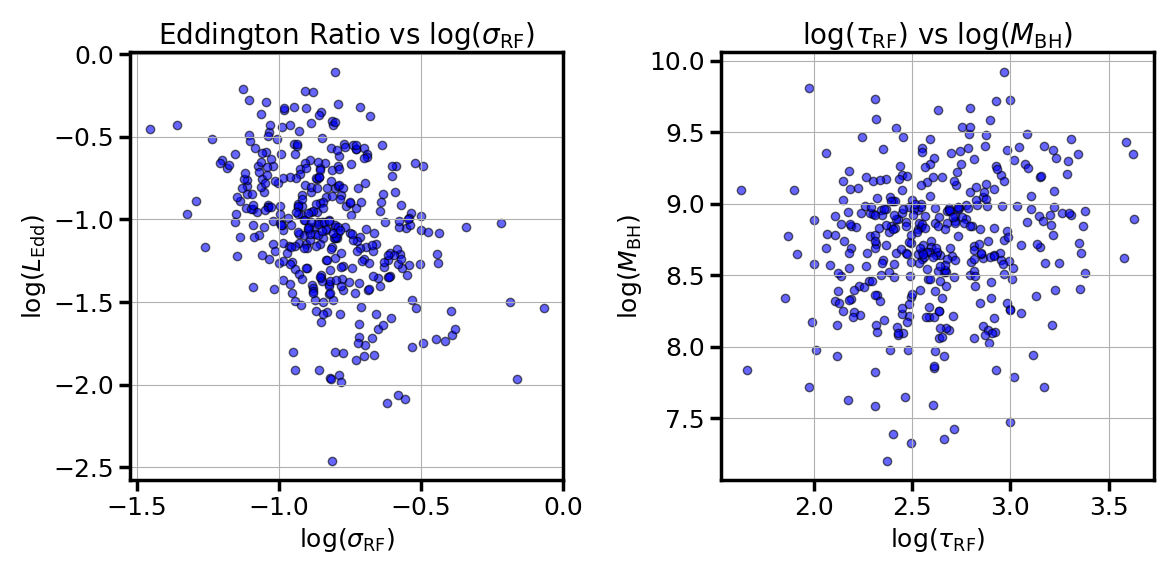

In [87]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot Eddington ratio vs sigma
axs[0].scatter(df['log_sigma_RF'], df['log_ledd_ratio'], c='blue', alpha=0.6, edgecolor='black')
axs[0].set_xlabel(r"$\log(\sigma_\mathrm{RF})$")
axs[0].set_ylabel(r"$\log(L_\mathrm{Edd})$")
axs[0].set_title(r"Eddington Ratio vs $\log(\sigma_\mathrm{RF})$")
axs[0].grid(True)

# Plot tau vs BH mass
axs[1].scatter(df['log_tau_RF'], df['log_mbh'], c='blue', alpha=0.6, edgecolor='black')
axs[1].set_xlabel(r"$\log(\tau_\mathrm{RF})$")
axs[1].set_ylabel(r"$\log(M_\mathrm{BH})$")
axs[1].set_title(r"$\log(\tau_\mathrm{RF})$ vs $\log(M_\mathrm{BH})$")
axs[1].grid(True)

plt.tight_layout()
plt.show()

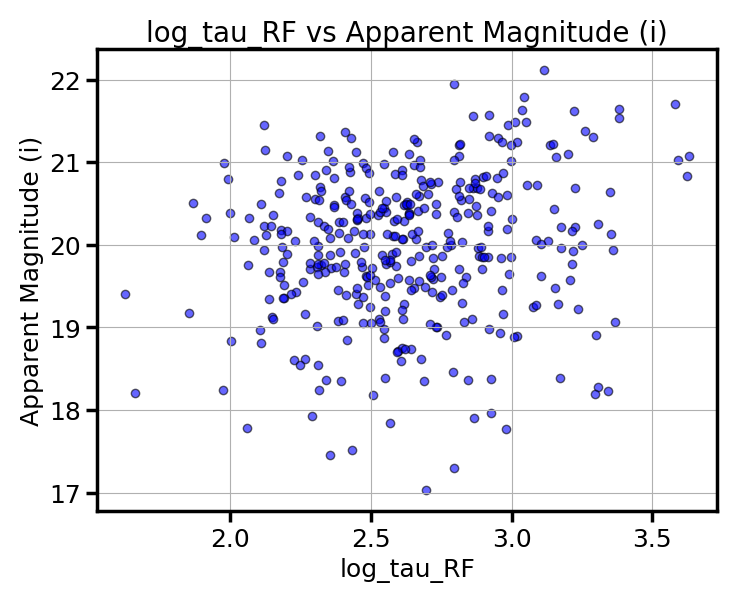

In [88]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_tau_RF'], df['apparent_mag_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_tau_RF')
plt.ylabel('Apparent Magnitude (i)')
plt.title('log_tau_RF vs Apparent Magnitude (i)')
plt.grid(True)
plt.show()

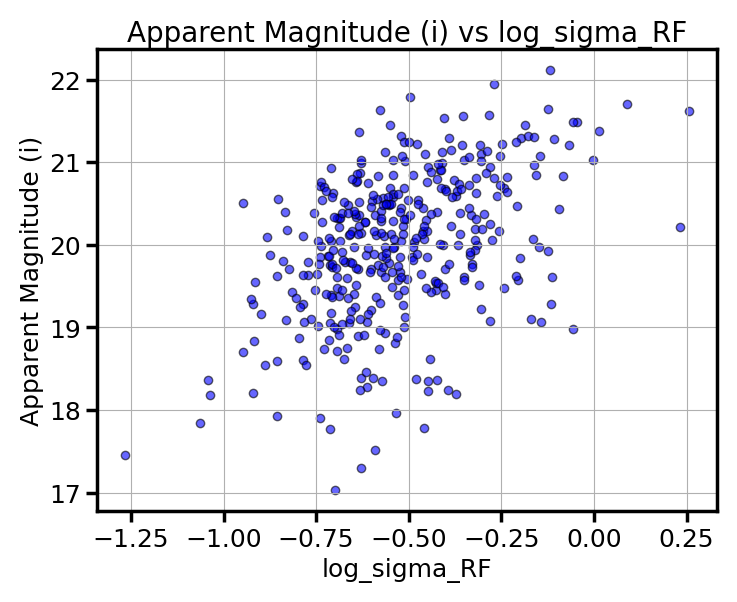

In [89]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma'], df['apparent_mag_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_sigma_RF')
plt.ylabel('Apparent Magnitude (i)')
plt.title('Apparent Magnitude (i) vs log_sigma_RF')
plt.grid(True)
plt.show()

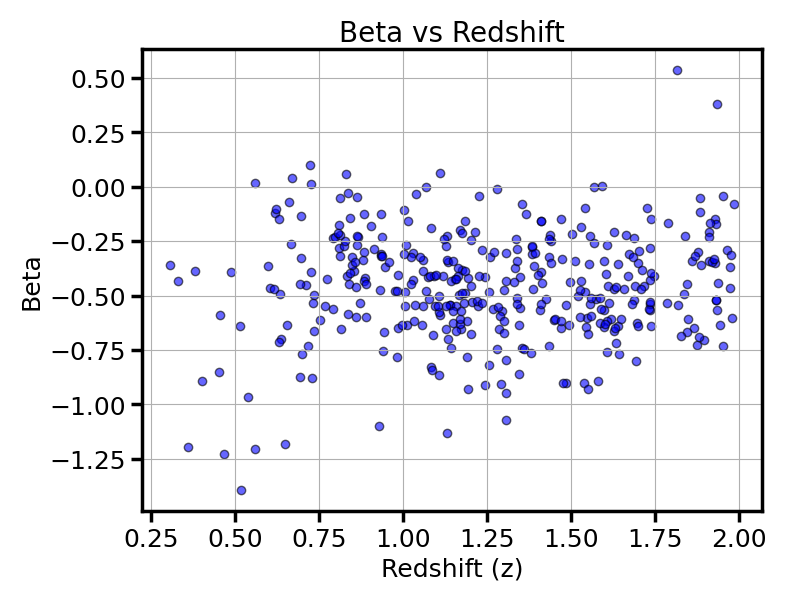

In [90]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['beta'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('Beta')
plt.title('Beta vs Redshift')
plt.grid(True)
plt.show()

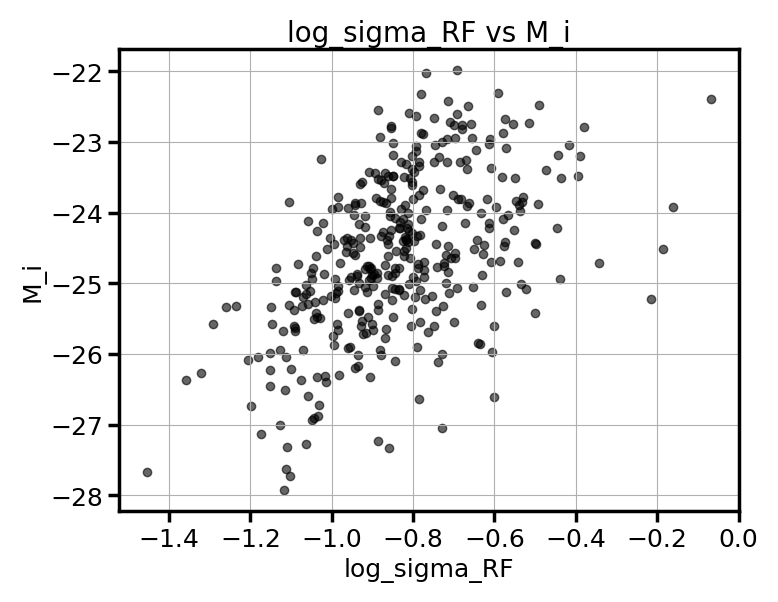

In [91]:
plt.figure(figsize=(8, 6))
#plt.scatter(df['log_sigma_RF'][(df['M_i']<-15) & (df['apparent_mag_i'] < 20)], df['M_i'][(df['M_i']<-15) & (df['apparent_mag_i'] < 20)], c='blue', alpha=0.6, edgecolor='black')
plt.scatter(df['log_sigma_RF'][(df['M_i']<-15)], df['M_i'][(df['M_i']<-15)], c='k', alpha=0.6, edgecolor='k')

plt.xlabel('log_sigma_RF')
plt.ylabel('M_i')
plt.title('log_sigma_RF vs M_i')
plt.grid(True)
plt.show()

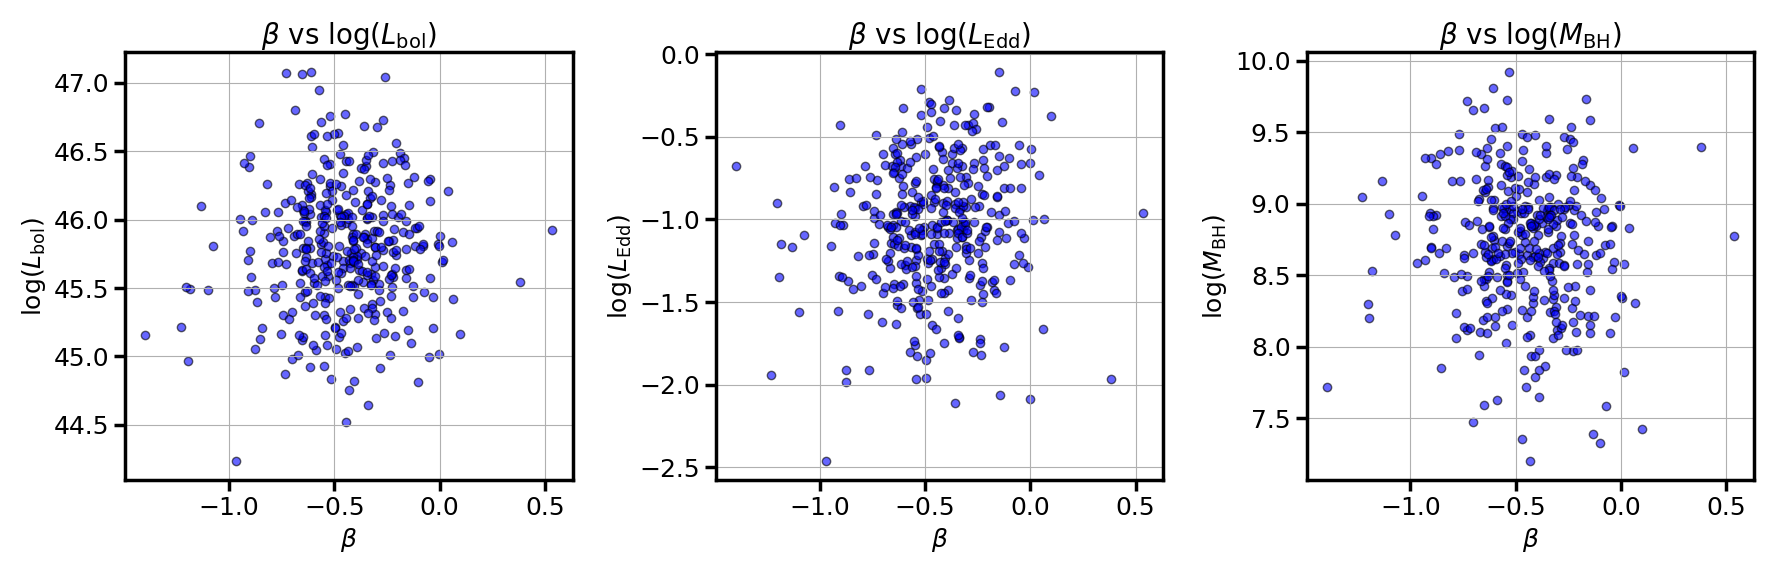

In [92]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot beta vs log_lbol
axs[0].scatter(df['beta'], df['log_lbol'], c='blue', alpha=0.6, edgecolor='black')
axs[0].set_xlabel(r"$\beta$")
axs[0].set_ylabel(r"$\log(L_\mathrm{bol})$")
axs[0].set_title(r"$\beta$ vs $\log(L_\mathrm{bol})$")
axs[0].grid(True)

# Plot beta vs log_ledd_ratio
axs[1].scatter(df['beta'], df['log_ledd_ratio'], c='blue', alpha=0.6, edgecolor='black')
axs[1].set_xlabel(r"$\beta$")
axs[1].set_ylabel(r"$\log(L_\mathrm{Edd})$")
axs[1].set_title(r"$\beta$ vs $\log(L_\mathrm{Edd})$")
axs[1].grid(True)

# Plot beta vs log_mbh
axs[2].scatter(df['beta'], df['log_mbh'], c='blue', alpha=0.6, edgecolor='black')
axs[2].set_xlabel(r"$\beta$")
axs[2].set_ylabel(r"$\log(M_\mathrm{BH})$")
axs[2].set_title(r"$\beta$ vs $\log(M_\mathrm{BH})$")
axs[2].grid(True)

plt.tight_layout()
plt.show()

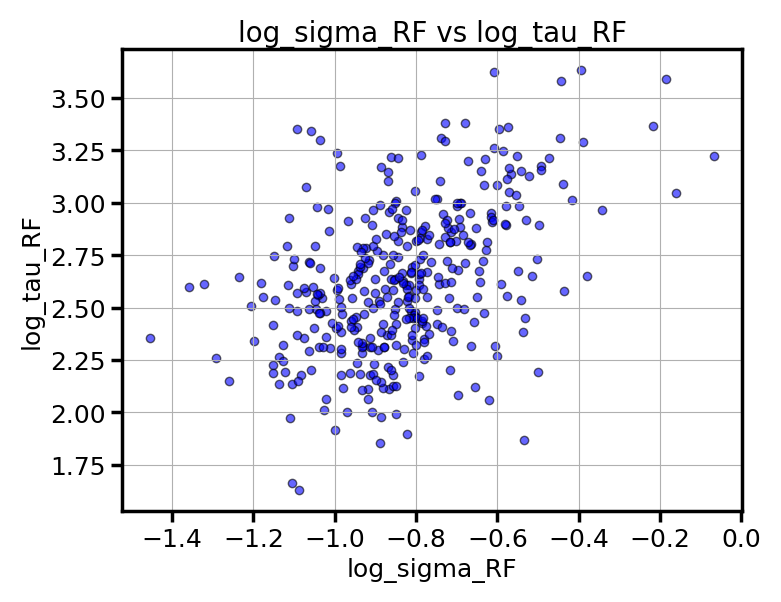

In [93]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['log_tau_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_sigma_RF')
plt.ylabel('log_tau_RF')
plt.title('log_sigma_RF vs log_tau_RF')
plt.grid(True)
plt.show()

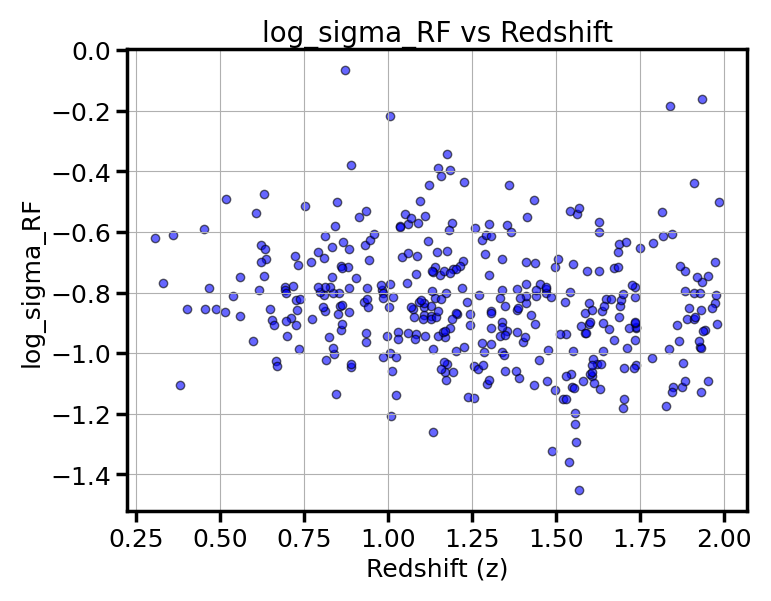

In [94]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['log_sigma_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('log_sigma_RF')
plt.title('log_sigma_RF vs Redshift')
plt.grid(True)
plt.show()

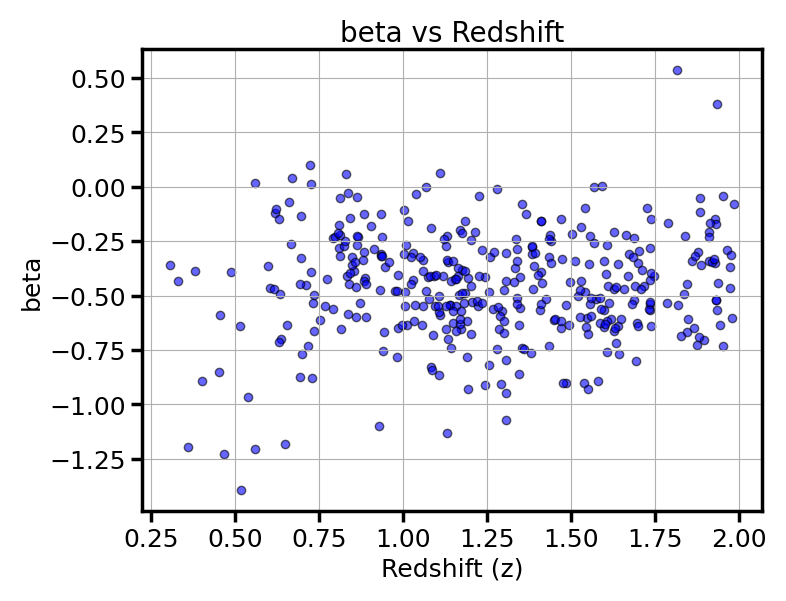

In [95]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['beta'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('beta')
plt.title('beta vs Redshift')
plt.grid(True)
plt.show()

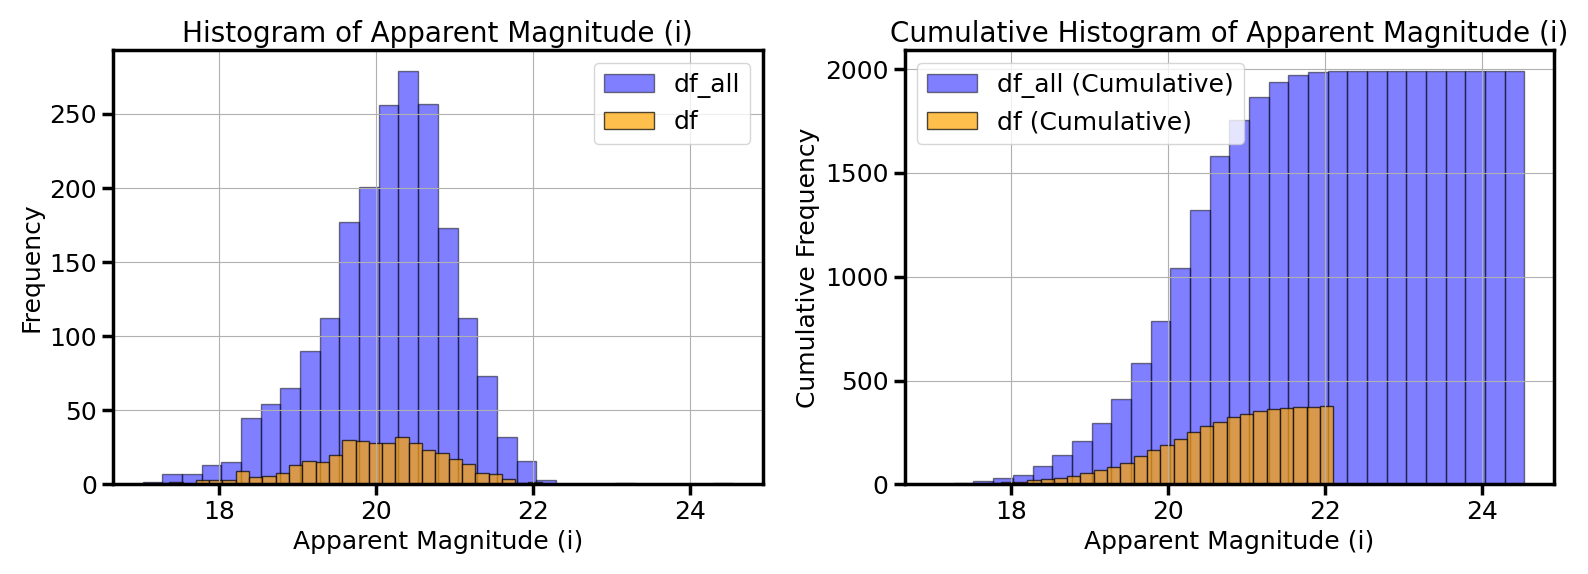

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot histogram for df_all
ax1.hist(df_all['apparent_mag_i'], bins=30, color='blue', alpha=0.5, label='df_all', edgecolor='black')
ax1.hist(df['apparent_mag_i'], bins=30, color='orange', alpha=0.7, label='df', edgecolor='black')
ax1.set_xlabel('Apparent Magnitude (i)')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Apparent Magnitude (i)')
ax1.legend()
ax1.grid(True)

# Plot cumulative histograms
ax2.hist(df_all['apparent_mag_i'], bins=30, color='blue', alpha=0.5, label='df_all (Cumulative)', edgecolor='black', cumulative=True) #, histtype='step')
ax2.hist(df['apparent_mag_i'], bins=30, color='orange', alpha=0.7, label='df (Cumulative)', edgecolor='black', cumulative=True) #, histtype='step')
ax2.set_xlabel('Apparent Magnitude (i)')
ax2.set_ylabel('Cumulative Frequency')
ax2.set_title('Cumulative Histogram of Apparent Magnitude (i)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

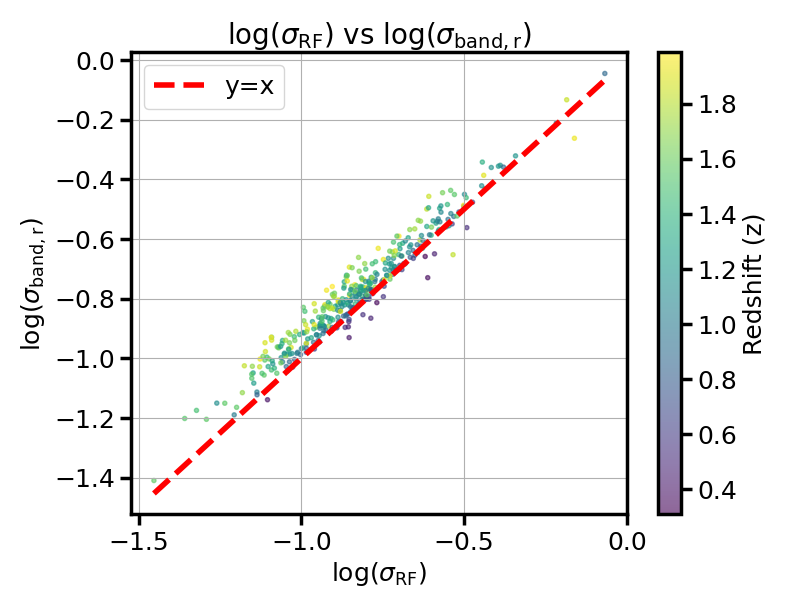

In [97]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['log_sigma_band_r'], c=df['z'], alpha=0.6, marker='.')
plt.xlabel(r"$\log(\sigma_\mathrm{RF})$")
plt.ylabel(r"$\log(\sigma_\mathrm{band,r})$")
plt.title(r"$\log(\sigma_\mathrm{RF})$ vs $\log(\sigma_\mathrm{band,r})$")
plt.grid(True)
plt.plot([df['log_sigma_RF'].min(), df['log_sigma_RF'].max()], 
         [df['log_sigma_RF'].min(), df['log_sigma_RF'].max()], 
         'r--', label='y=x')
plt.legend()
plt.colorbar(label='Redshift (z)')

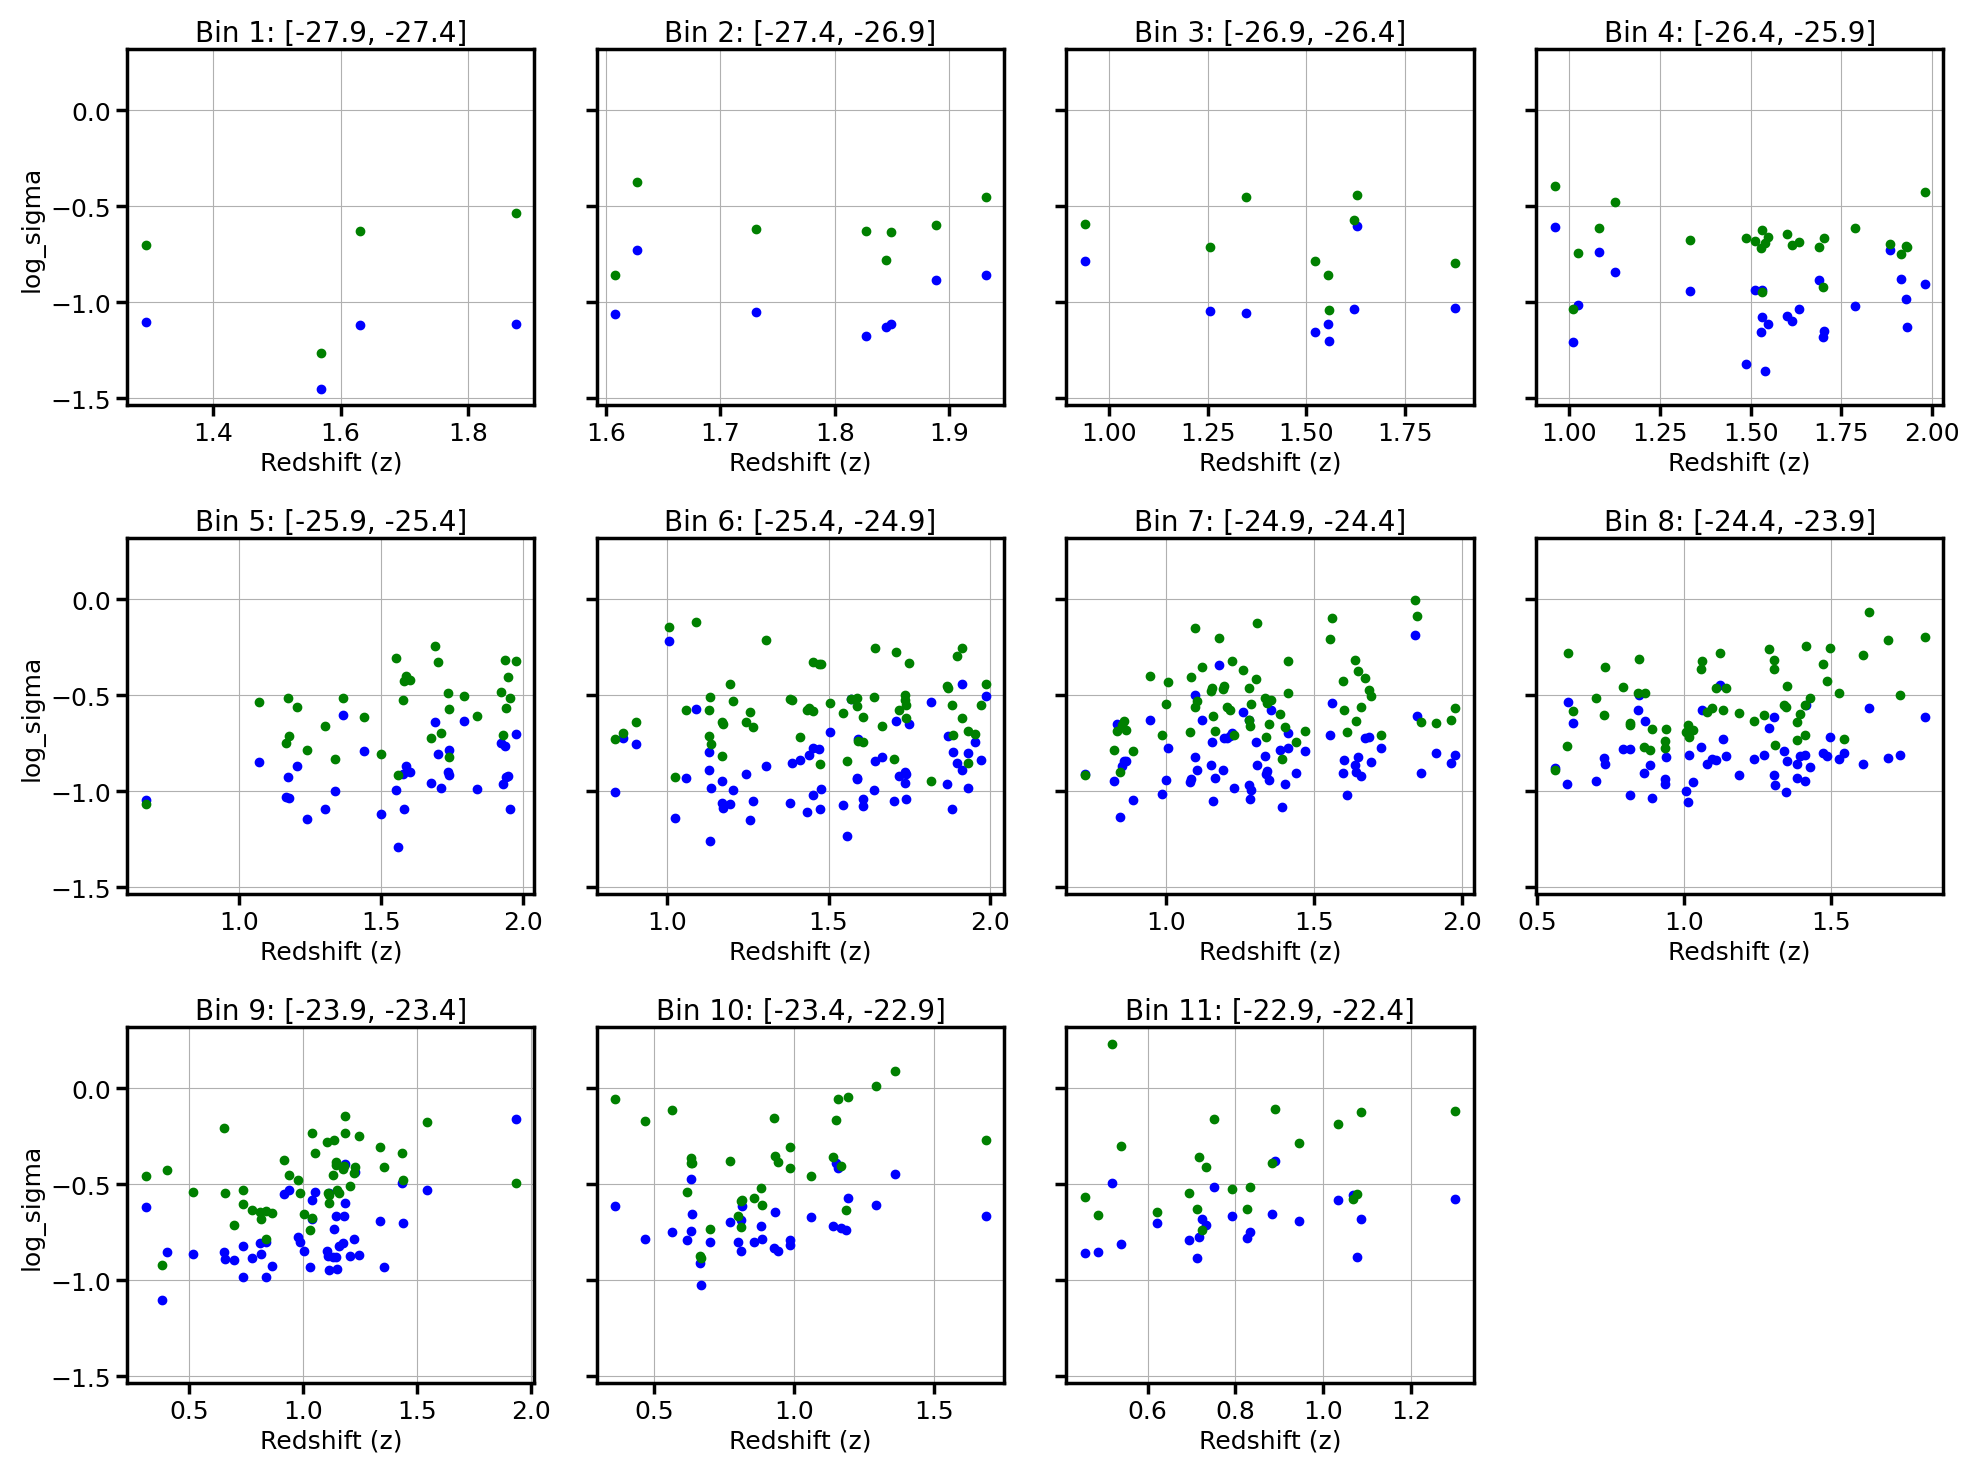

In [98]:
from scipy.stats import linregress

# Define the bins for M_i

M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_sigma_RF'])
        y_vals = slope * np.linspace(1, 2) + intercept
        #axes[i].plot(np.linspace(1, 2), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_sigma_RF'], 'bo', label='Data')
        axes[i].plot(bin_data['z'], bin_data['log_sigma'], 'go', label='Data')
        #axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_sigma')
    axes[i].grid(True)
    #axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

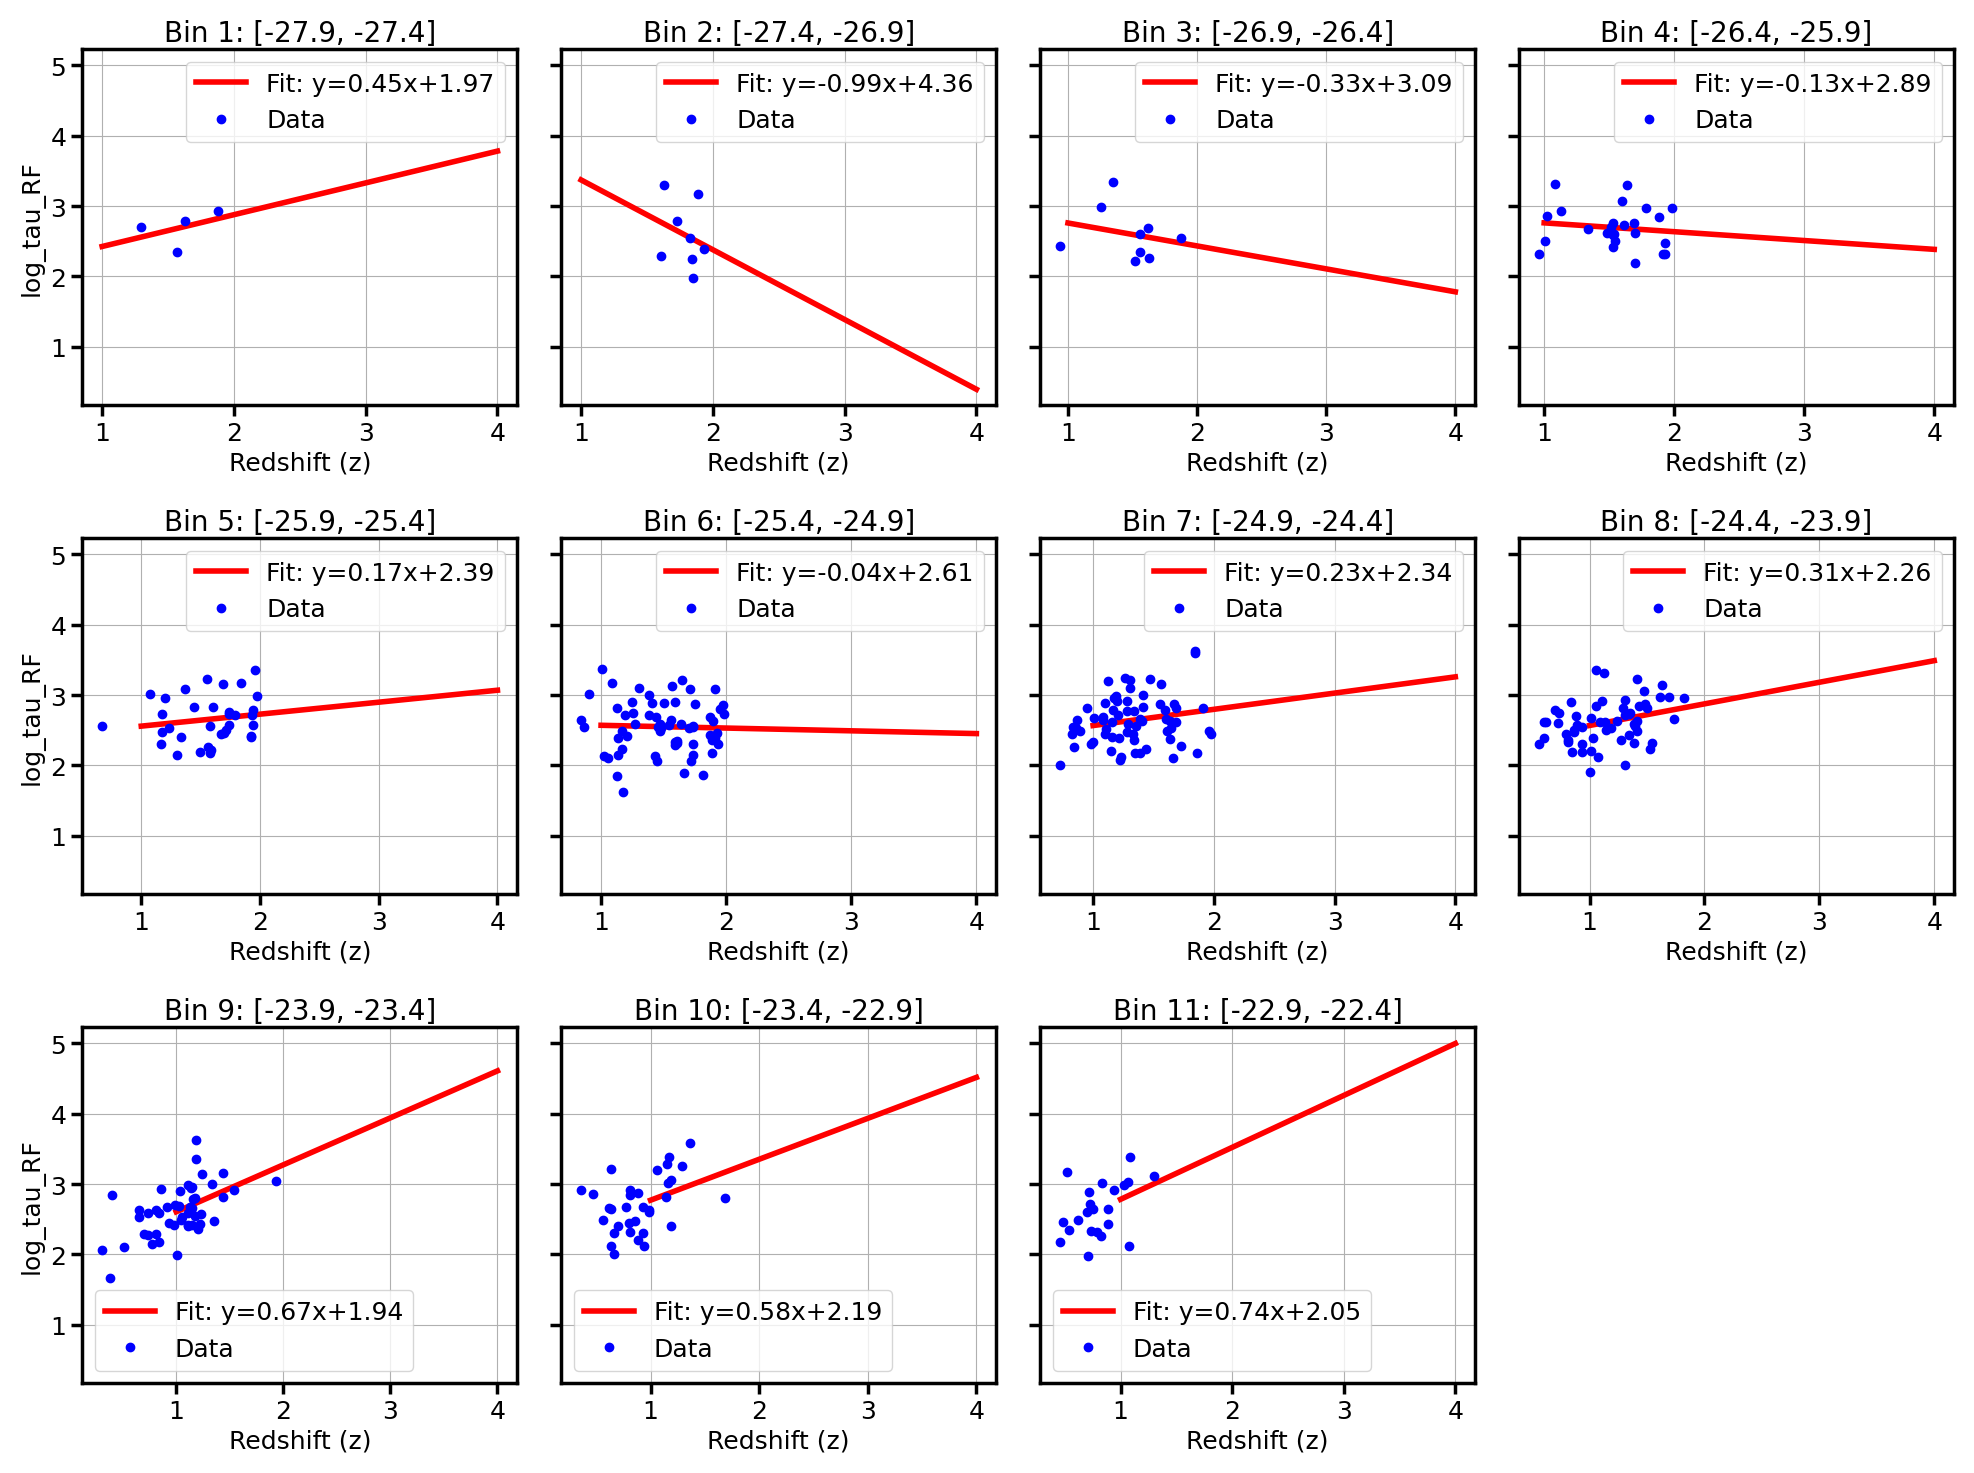

In [99]:
from scipy.stats import linregress

# Define the bins for M_i
M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_tau_RF'])
        y_vals = slope * np.linspace(1, 4) + intercept
        axes[i].plot(np.linspace(1, 4), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_tau_RF'], 'bo', label='Data')
        axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_tau_RF')
    axes[i].grid(True)
    axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [100]:
from datetime import datetime, timedelta
import h5py

def load_s82_from_hdf5(file_path="s82_objs.h5"):
    s82_objs = []

    with h5py.File(file_path, "r") as hdf:
        for object_id in hdf.keys():
            group = hdf[object_id]
            data = {
                "object_id": int(object_id),
                "magerrs_mean": group.attrs["magerrs_mean"],
                "times": {},
                "mags": {},
                "magerrs": {},
            }

            for key in ["times", "mags", "magerrs"]:
                sub_group = group[key]
                for band in sub_group.keys():
                    data[key][band] = sub_group[band][...]

            s82_objs.append(data)

    return s82_objs

s82_objs = load_s82_from_hdf5("data/s82_objs_sdss_small_allbands.h5")

for obj in s82_objs:
    obj['delta_time'] = obj['times']['r'].max() - obj['times']['r'].min()


objs = pd.DataFrame(s82_objs)
objs = objs.set_index('object_id')

In [101]:
objs

,magerrs_mean,times,mags,magerrs,delta_time
object_id,,,,,
1429814,"[0.07716131928775992, 0.1083875648296216, 0.10...","{'g': [52196.35, 52197.35, 52207.32, 52225.2, ...","{'g': [-0.040937445960139485, -0.0134449227667...","{'g': [0.024431778118014336, 0.025301685556769...",8045.892259
1429820,"[0.24030865300843057, 0.15136136789375432, 0.1...","{'g': [52522.35, 52558.35, 52577.24, 52910.33,...","{'g': [0.31452474506839323, 0.4060240736816745...","{'g': [0.05875227600336075, 0.0389434695243835...",7715.951326
1429839,"[0.052136293752756836, 0.1151213774713494, 0.1...","{'g': [52196.35, 52197.35, 52207.32, 52225.2, ...","{'g': [-0.4125039649008606, -0.369006879329571...","{'g': [0.01939302682876587, 0.0214805677533149...",8045.892260
1429841,"[0.2680101211545831, 0.14970230736628604, 0.12...","{'g': [52522.35, 52552.35, 52558.35, 52577.24,...","{'g': [0.2308729268059686, 0.25415020952081235...","{'g': [0.05643713101744652, 0.0385754257440567...",7713.972039
1429843,"[0.05773300878904961, 0.07725423910216932, 0.0...","{'g': [52196.35, 52197.35, 52207.32, 52225.2, ...","{'g': [-0.14632851848677575, -0.15934998760298...","{'g': [0.021781377494335175, 0.028713945299386...",8045.892254
...,...,...,...,...,...
1444784,"[0.14468462045558475, 0.11218113786704192, 0.1...","{'g': [52522.32, 52577.21, 52586.21, 52931.22,...","{'g': [0.2712947452877259, 0.261487158617804, ...","{'g': [0.03322657570242882, 0.0277136806398630...",7412.851006
1444786,"[0.06689266182482242, 0.11576224767721874, 0.1...","{'g': [52522.32, 52577.21, 52586.21, 52910.29,...","{'g': [0.25514637605901314, 0.2223476089691693...","{'g': [0.03362615779042244, 0.0277392268180847...",7412.851006
1444797,"[0.35949616446051486, 0.17580564753559916, 0.1...","{'g': [52522.32, 52558.32, 52577.21, 52586.21,...","{'g': [-0.2202896008450388, -0.072588337417304...","{'g': [0.06366531550884247, 0.0792825296521186...",7380.886606


In [102]:
df

,object_id,ra,dec,z,sdss_name,log_lbol,log_lbol_err,log_mbh,log_mbh_err,log_ledd_ratio,...,magerrs_mean_y,z_sys_lines,z_sys_lines_err,ebv,M_i,apparent_mag_i,apparent_mag_i_err,color,fhost_5100,log_lambda_RF
1001,1429814,11.966741,0.206758,1.450674,004752.01+001224.3,45.795265,0.005025,8.689964,0.109463,-1.008643,...,0.0,"[0.0, 0.0, 0.0, 1.451517109639639, 1.449804889...","[-1.0, -1.0, -1.0, 0.001154273459497346, 0.002...",0.016162,-25.232030,19.750615,0.025812,0.402110,0.0,3.492954
1003,1429839,11.944938,0.270032,1.452015,004746.78+001612.1,46.184609,0.006615,8.613236,0.161823,-0.542571,...,0.0,"[0.0, 0.0, 0.0, 0.0, 1.4501592798104301, 1.455...","[-1.0, -1.0, -1.0, -1.0, 0.0021679674137247817...",0.015519,-25.218708,19.766605,0.025275,0.094634,0.0,3.492717
1004,1429841,11.943599,-0.356900,1.286526,004746.46-002124.8,45.622645,0.006481,8.473335,0.081319,-0.964634,...,0.0,"[0.0, 0.0, 0.0, 1.2866933919393704, 1.28539306...","[-1.0, -1.0, -1.0, 0.0006306921149229983, 0.00...",0.016871,-24.440560,20.293093,0.034194,1.275408,0.0,3.523064
1005,1429843,11.942674,-0.010110,1.547421,004746.24-000036.3,46.336920,0.002530,9.023744,0.074379,-0.800768,...,0.0,"[0.0, 0.0, 0.0, 0.0, 1.5452020521702932, 1.552...","[-1.0, -1.0, -1.0, -1.0, 0.001992015760671797,...",0.019972,-26.045420,19.051138,0.024822,0.863050,0.0,3.476139
1006,1429882,11.918701,0.238306,1.154440,004740.48+001417.9,45.683424,0.011856,8.866089,0.050919,-1.296608,...,0.0,"[0.0, 0.0, 1.1522532457673726, 1.1554894175895...","[-1.0, -1.0, 0.003144075341296488, 0.002660618...",0.015875,-24.444979,20.065269,0.032012,0.375627,0.0,3.548906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1435549,7.688330,0.757948,1.735362,003045.19+004528.6,45.807680,0.009414,8.742813,0.177129,-1.049076,...,0.0,"[0.0, 0.0, 0.0, 1.7439738375180451, 1.73666870...","[-1.0, -1.0, -1.0, 0.008279715261352861, 0.002...",0.022681,-25.045172,20.362821,0.036550,0.383755,0.0,3.445225
1996,1435550,7.686976,0.355380,1.098885,003044.87+002119.3,45.785240,0.004015,8.682714,0.094465,-1.011417,...,0.0,"[0.0, 0.0, 0.0, 0.0, 1.0991842976208268, 1.096...","[-1.0, -1.0, -1.0, -1.0, 0.001563580074885029,...",0.021167,-24.543050,19.895062,0.025459,0.350966,0.0,3.560251
1998,1435556,7.676847,-0.104525,0.884416,003042.44-000616.2,45.134121,0.006700,8.083715,0.162141,-1.063537,...,0.0,"[0.8859049864385904, 0.8845570796869802, 0.0, ...","[0.0025647398784425465, 0.0004173931556740846,...",0.018845,-23.288314,20.745024,0.042662,2.484792,0.0,3.607063
1999,1435575,7.656444,-0.680329,0.667758,003037.54-004049.1,45.169177,0.032401,7.979898,0.092761,-0.924664,...,0.0,"[0.0, 0.6680201367618914, 0.6668554413690051, ...","[-1.0, 0.0003514381530988976, 0.00057175918072...",0.018403,-23.242356,20.098264,0.033442,0.501381,0.0,3.660107


In [103]:
#df = df.set_index('object_id')
new_df = df.join(objs)

In [104]:
new_df

,object_id,ra,dec,z,sdss_name,log_lbol,log_lbol_err,log_mbh,log_mbh_err,log_ledd_ratio,...,apparent_mag_i,apparent_mag_i_err,color,fhost_5100,log_lambda_RF,magerrs_mean,times,mags,magerrs,delta_time
1001,1429814,11.966741,0.206758,1.450674,004752.01+001224.3,45.795265,0.005025,8.689964,0.109463,-1.008643,...,19.750615,0.025812,0.402110,0.0,3.492954,NaN,NaN,NaN,NaN,NaN
1003,1429839,11.944938,0.270032,1.452015,004746.78+001612.1,46.184609,0.006615,8.613236,0.161823,-0.542571,...,19.766605,0.025275,0.094634,0.0,3.492717,NaN,NaN,NaN,NaN,NaN
1004,1429841,11.943599,-0.356900,1.286526,004746.46-002124.8,45.622645,0.006481,8.473335,0.081319,-0.964634,...,20.293093,0.034194,1.275408,0.0,3.523064,NaN,NaN,NaN,NaN,NaN
1005,1429843,11.942674,-0.010110,1.547421,004746.24-000036.3,46.336920,0.002530,9.023744,0.074379,-0.800768,...,19.051138,0.024822,0.863050,0.0,3.476139,NaN,NaN,NaN,NaN,NaN
1006,1429882,11.918701,0.238306,1.154440,004740.48+001417.9,45.683424,0.011856,8.866089,0.050919,-1.296608,...,20.065269,0.032012,0.375627,0.0,3.548906,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1435549,7.688330,0.757948,1.735362,003045.19+004528.6,45.807680,0.009414,8.742813,0.177129,-1.049076,...,20.362821,0.036550,0.383755,0.0,3.445225,NaN,NaN,NaN,NaN,NaN
1996,1435550,7.686976,0.355380,1.098885,003044.87+002119.3,45.785240,0.004015,8.682714,0.094465,-1.011417,...,19.895062,0.025459,0.350966,0.0,3.560251,NaN,NaN,NaN,NaN,NaN
1998,1435556,7.676847,-0.104525,0.884416,003042.44-000616.2,45.134121,0.006700,8.083715,0.162141,-1.063537,...,20.745024,0.042662,2.484792,0.0,3.607063,NaN,NaN,NaN,NaN,NaN
1999,1435575,7.656444,-0.680329,0.667758,003037.54-004049.1,45.169177,0.032401,7.979898,0.092761,-0.924664,...,20.098264,0.033442,0.501381,0.0,3.660107,NaN,NaN,NaN,NaN,NaN


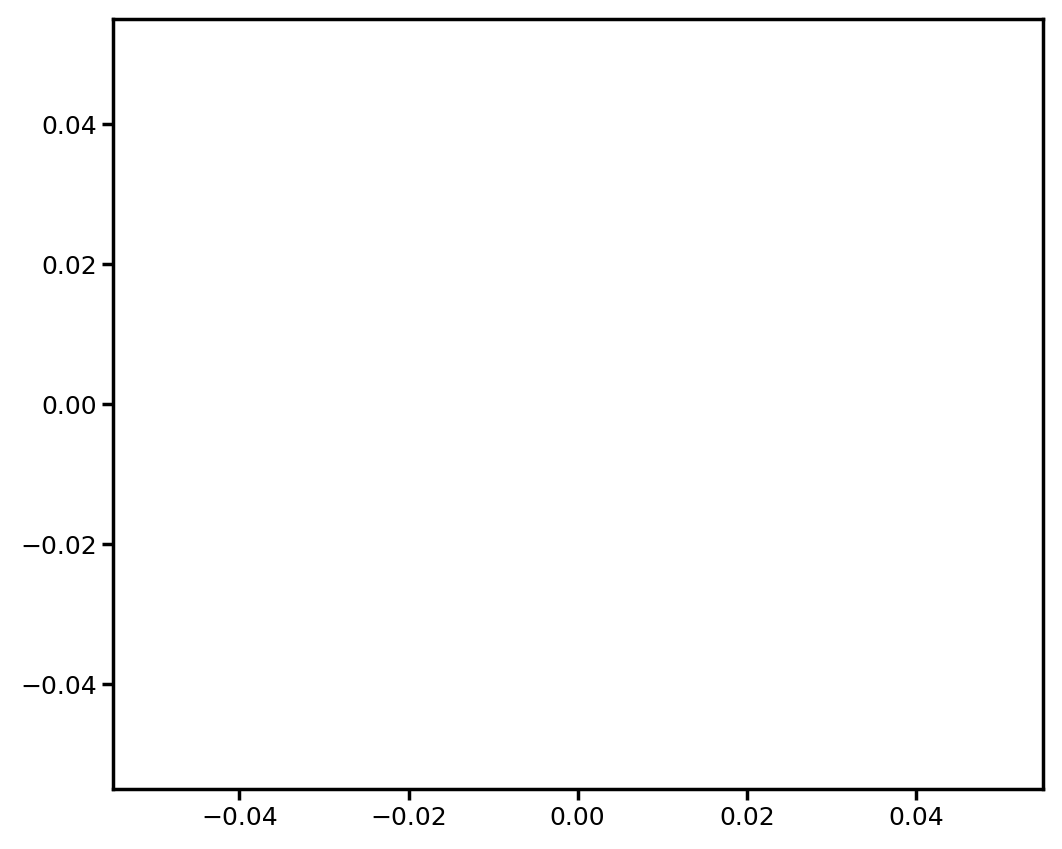

In [105]:
new_df = new_df[new_df['delta_time'] > 800]
plt.scatter(new_df['delta_time'], new_df['apparent_mag_i'])

100%|██████████| 1000/1000 [00:40<00:00, 24.60it/s]


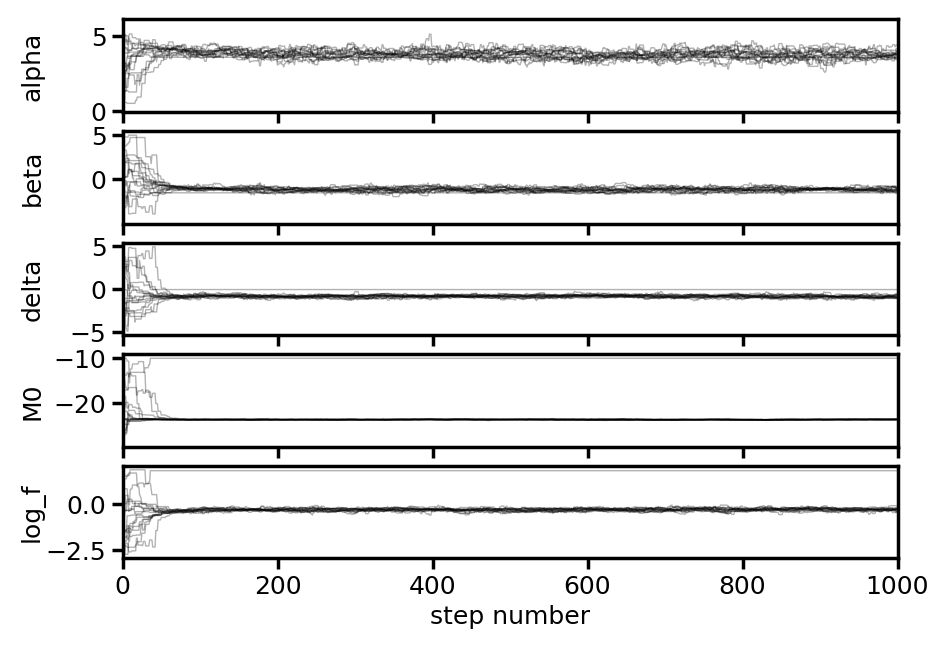

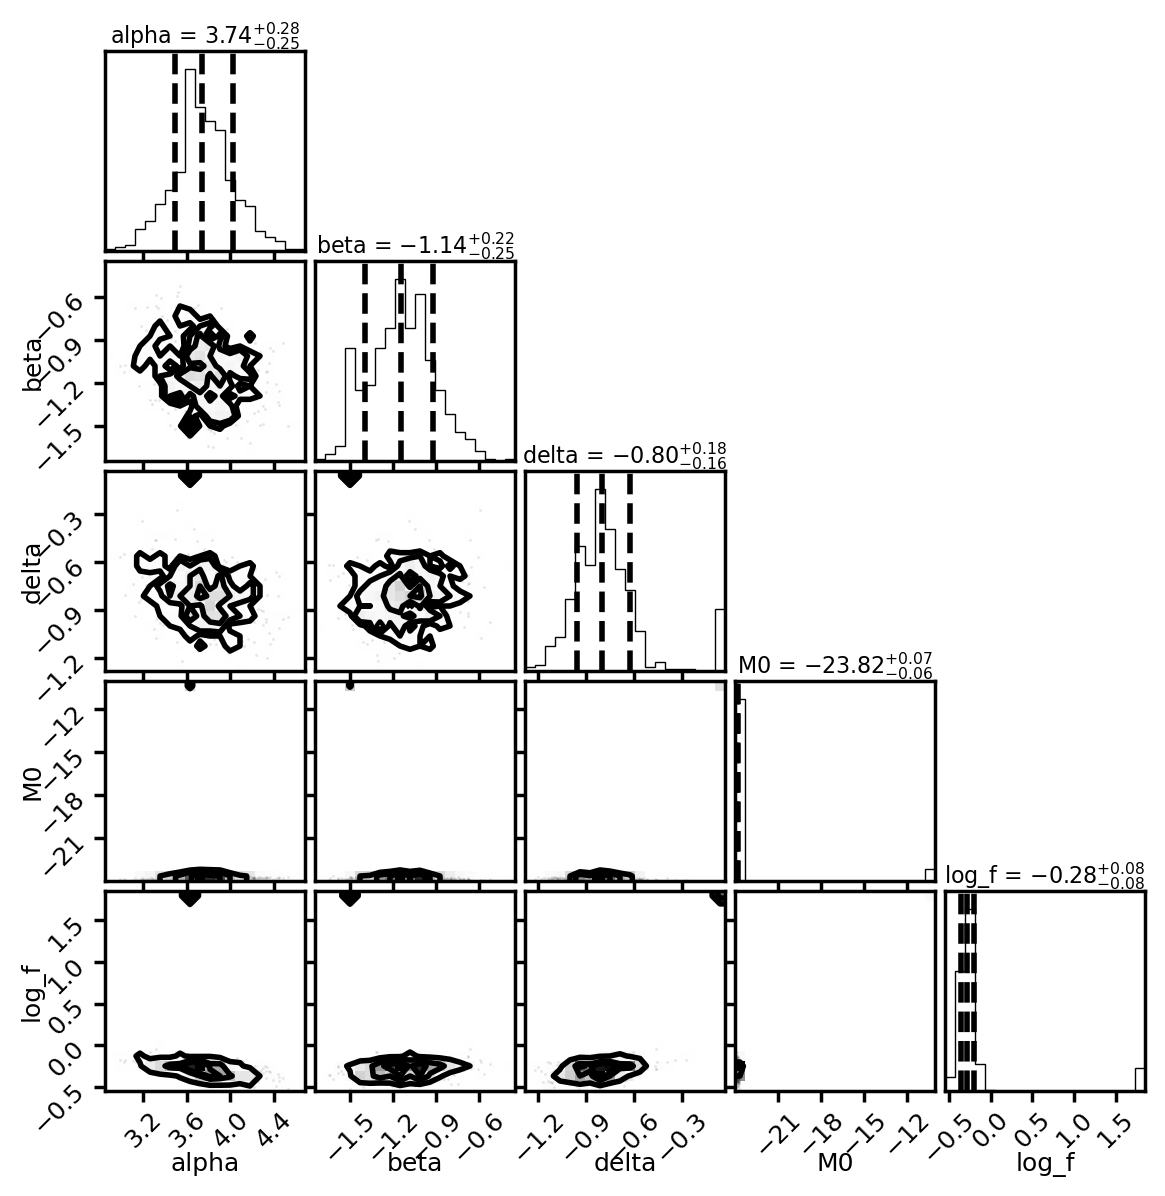

In [106]:
import emcee
import corner
import numpy as np
from astropy.cosmology import w0waCDM
import matplotlib.pyplot as plt

def M_model(M0, alpha, beta, delta):
    return M0 + alpha * (df["log_sigma_RF"]+0.8) + beta * (df["beta"]+0.5) + delta * (df["log_tau_RF"]-2.5)

def K_corr(z, alpha_nu=-0.5):
    return -2.5 * (1 + alpha_nu) * np.log10(1 + z)

# log_likelihood function
def log_likelihood(theta):

    alpha, beta, delta, M0, log_f = theta

    # Prior
    for i, (key, val) in enumerate(priors.items()):
        lower, upper = val
        if not (lower < theta[i] < upper):
            return -np.inf
    
    mu_pred = df['apparent_mag_i'] - M_model(M0, alpha, beta, delta) - K_corr(df['z'])
    mu_pred_err = np.sqrt(df['apparent_mag_i_err']**2 + 
                          (alpha * df["log_sigma_RF_err"])**2 + 
                          (beta * df["beta_err"])**2 + 
                          (delta * df["log_tau_RF_err"])**2 +
                          np.exp(2 * log_f))
    
    cosmo = w0waCDM(H0=70, Om0=0.3, Ode0=0.7, w0=-1, wa=0)
    mu_model = cosmo.distmod(df['z']).value

    return -0.5 * np.sum(((mu_pred - mu_model) / mu_pred_err)**2 + np.log(2 * np.pi * mu_pred_err**2))

# Define a dictionary to hold model parameters
priors = {
    "alpha": (0, 6),
    "beta": (-5, 5),
    "delta": (-5, 5),
    "M0": (-30, -10),
    "log_f": (-3, 2),
    # cosmology parameters
    #"H0": (50, 100),
    #"Om0": (0.1, 0.5),
    #"Omk": (-0.5, 0.5),
    #"Oml": (0.1, 0.9),
    #"w0": (-2, 2),
    #"wa": (-2, 2)
}

# Set up the sampler
ndim = len(priors)  # Number of parameters
nwalkers = 16  # Number of walkers
nsteps = 1000  # Number of steps

# Run the MCMC sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood)

# Initial positions of the walkers
initial_pos = np.array([np.random.uniform(low, high, nwalkers) for low, high in priors.values()]).T

sampler.run_mcmc(initial_pos, nsteps, progress=True)

# Extract the samples
samples_by_chain = sampler.get_chain()
#tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

labels = list(priors.keys())

fig, axes = plt.subplots(len(labels), figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_by_chain[:, :, i], "k", alpha=0.3, lw=1)
    ax.set_xlim(0, len(samples_by_chain))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.show()

fig = corner.corner(flat_samples, show_titles=True, labels=labels, quantiles=[0.16, 0.5, 0.84],
                    label_kwargs=dict(fontsize=18), title_kwargs=dict(fontsize=16));
plt.show()

results = {key: np.percentile(flat_samples[:, i], [16, 50, 84]) for i, key in enumerate(priors.keys())}

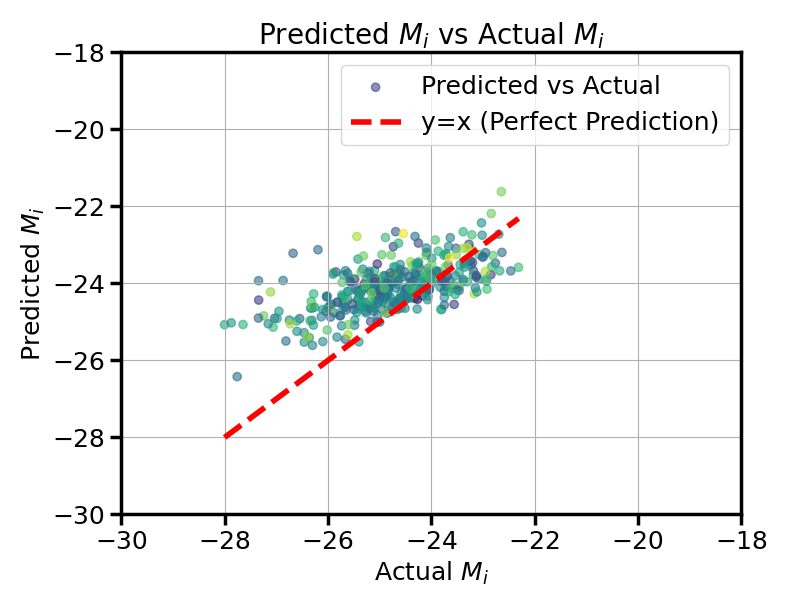

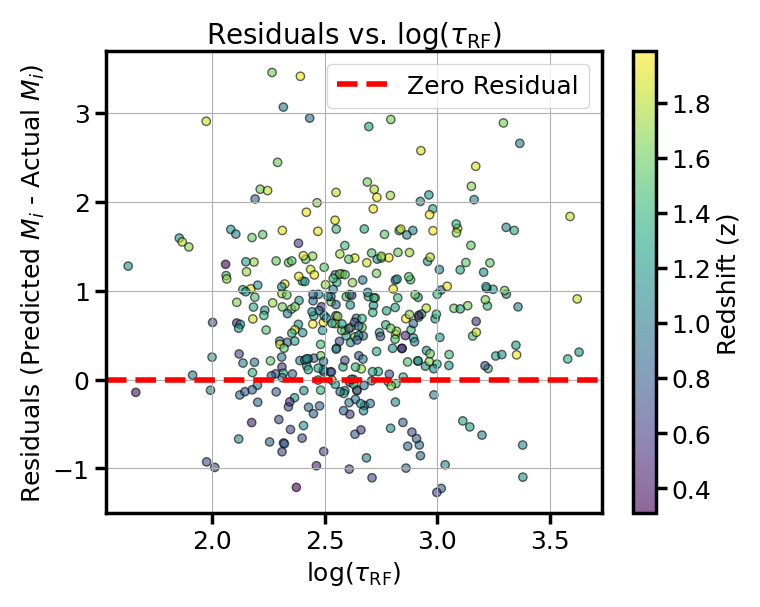

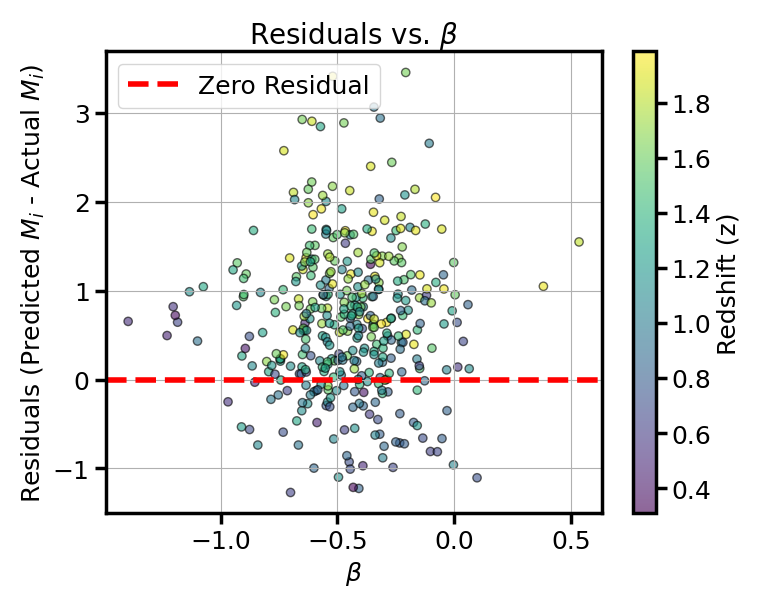

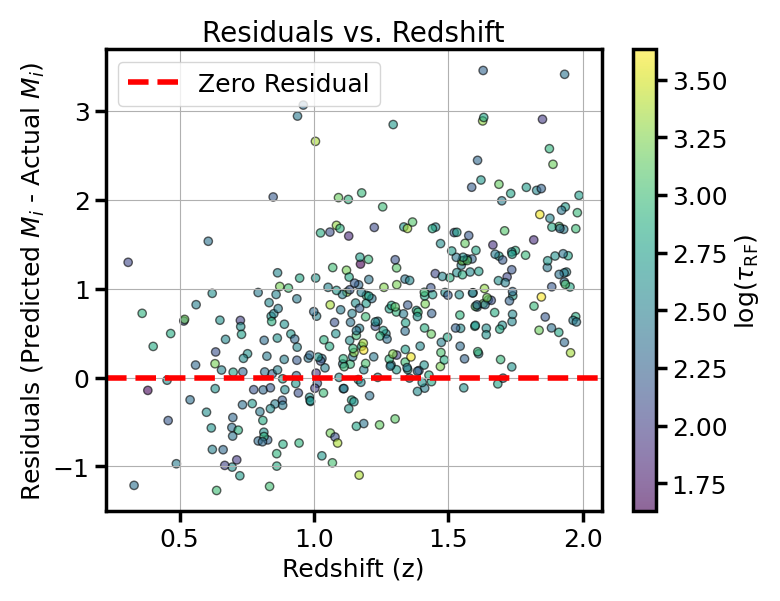

In [107]:
import matplotlib.pyplot as plt

# Assuming `predicted_M_i` contains the predicted M_i values
M_i_pred = M_model(
    results['M0'][1], 
    results['alpha'][1], 
    results['beta'][1],
    results['delta'][1]
)
# Extract actual M_i values from the dataframe
actual_M_i = df['M_i'] + K_corr(2) - K_corr(df['z'])


# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(actual_M_i, M_i_pred, c=df['log_tau_RF'], alpha=0.6, label='Predicted vs Actual')
plt.plot([actual_M_i.min(), actual_M_i.max()], [actual_M_i.min(), actual_M_i.max()], 'r--', label='y=x (Perfect Prediction)')
plt.xlabel('Actual $M_i$')
plt.ylabel('Predicted $M_i$')
plt.title('Predicted $M_i$ vs Actual $M_i$')
plt.xlim(-30, -18)
plt.ylim(-30, -18)
plt.legend()
plt.grid(True)
plt.show()

# Calculate residuals
residuals = M_i_pred - actual_M_i

# Plot residuals vs. log_tau_RF
plt.figure(figsize=(8, 6))
plt.scatter(df['log_tau_RF'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r"$\log(\tau_\mathrm{RF})$")
plt.ylabel("Residuals (Predicted $M_i$ - Actual $M_i$)")
plt.title(r"Residuals vs. $\log(\tau_\mathrm{RF})$")
plt.colorbar(label="Redshift (z)")
plt.legend()
plt.grid(True)
plt.show()

# Plot residuals vs beta
plt.figure(figsize=(8, 6))
plt.scatter(df['beta'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r"$\beta$")
plt.ylabel("Residuals (Predicted $M_i$ - Actual $M_i$)")
plt.title("Residuals vs. $\\beta$")
plt.colorbar(label="Redshift (z)")
plt.legend()
plt.grid(True)
plt.show()

# Plot residuals vs redshift
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], residuals, c=df['log_tau_RF'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Redshift (z)')
plt.ylabel("Residuals (Predicted $M_i$ - Actual $M_i$)")
plt.title("Residuals vs. Redshift")
plt.colorbar(label=r"$\log(\tau_\mathrm{RF})$")
plt.legend()
plt.grid(True)
plt.show()

In [108]:
df.keys()

Index(['object_id', 'ra', 'dec', 'z', 'sdss_name', 'log_lbol', 'log_lbol_err',
       'log_mbh', 'log_mbh_err', 'log_ledd_ratio', 'log_ledd_ratio_err', 'i',
       'log_tau_RF', 'log_tau_RF_err', 'beta', 'beta_err', 'log_sigma_RF',
       'log_sigma_RF_err', 'log_amp_delta', 'log_amp_delta_err', 'log_sigma',
       'log_sigma_err', 'log_sigma_band_u', 'log_sigma_band_g',
       'log_sigma_band_r', 'log_sigma_band_i', 'log_sigma_band_z',
       'log_sigma_band_y', 'log_sigma_band_err_u', 'log_sigma_band_err_g',
       'log_sigma_band_err_r', 'log_sigma_band_err_i', 'log_sigma_band_err_z',
       'log_sigma_band_err_y', 'log_jitter_u', 'log_jitter_g', 'log_jitter_r',
       'log_jitter_i', 'log_jitter_z', 'log_jitter_y', 'magerrs_mean_u',
       'magerrs_mean_g', 'magerrs_mean_r', 'magerrs_mean_i', 'magerrs_mean_z',
       'magerrs_mean_y', 'z_sys_lines', 'z_sys_lines_err', 'ebv', 'M_i',
       'apparent_mag_i', 'apparent_mag_i_err', 'color', 'fhost_5100',
       'log_lambda_RF'],
      

                            OLS Regression Results                            
Dep. Variable:               log_lbol   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     61.94
Date:                Wed, 09 Apr 2025   Prob (F-statistic):           1.63e-32
Time:                        18:51:33   Log-Likelihood:                -163.54
No. Observations:                 377   AIC:                             335.1
Df Residuals:                     373   BIC:                             350.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           43.4035      0.226    191.880   

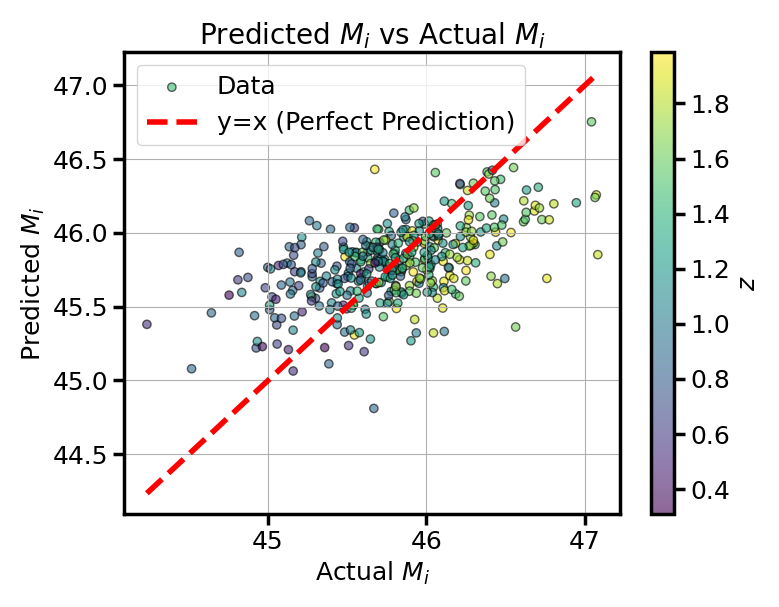

In [109]:
import statsmodels.api as sm

# Prepare the data
X = df[['log_sigma_RF', 'beta', 'log_tau_RF']]  # Predictors
y = df['log_lbol']  # Target variable (M0)

# Add a constant to the predictors (for the intercept term)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary of the regression
print(model.summary())

# Extract the predicted values
y_pred = model.predict(X)

# Plot the actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black', label='Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='y=x (Perfect Prediction)')
plt.colorbar(label=r"$z$")
plt.xlabel('Actual $M_i$')
plt.ylabel('Predicted $M_i$')
plt.title('Predicted $M_i$ vs Actual $M_i$')
plt.legend()
plt.grid(True)
plt.show()

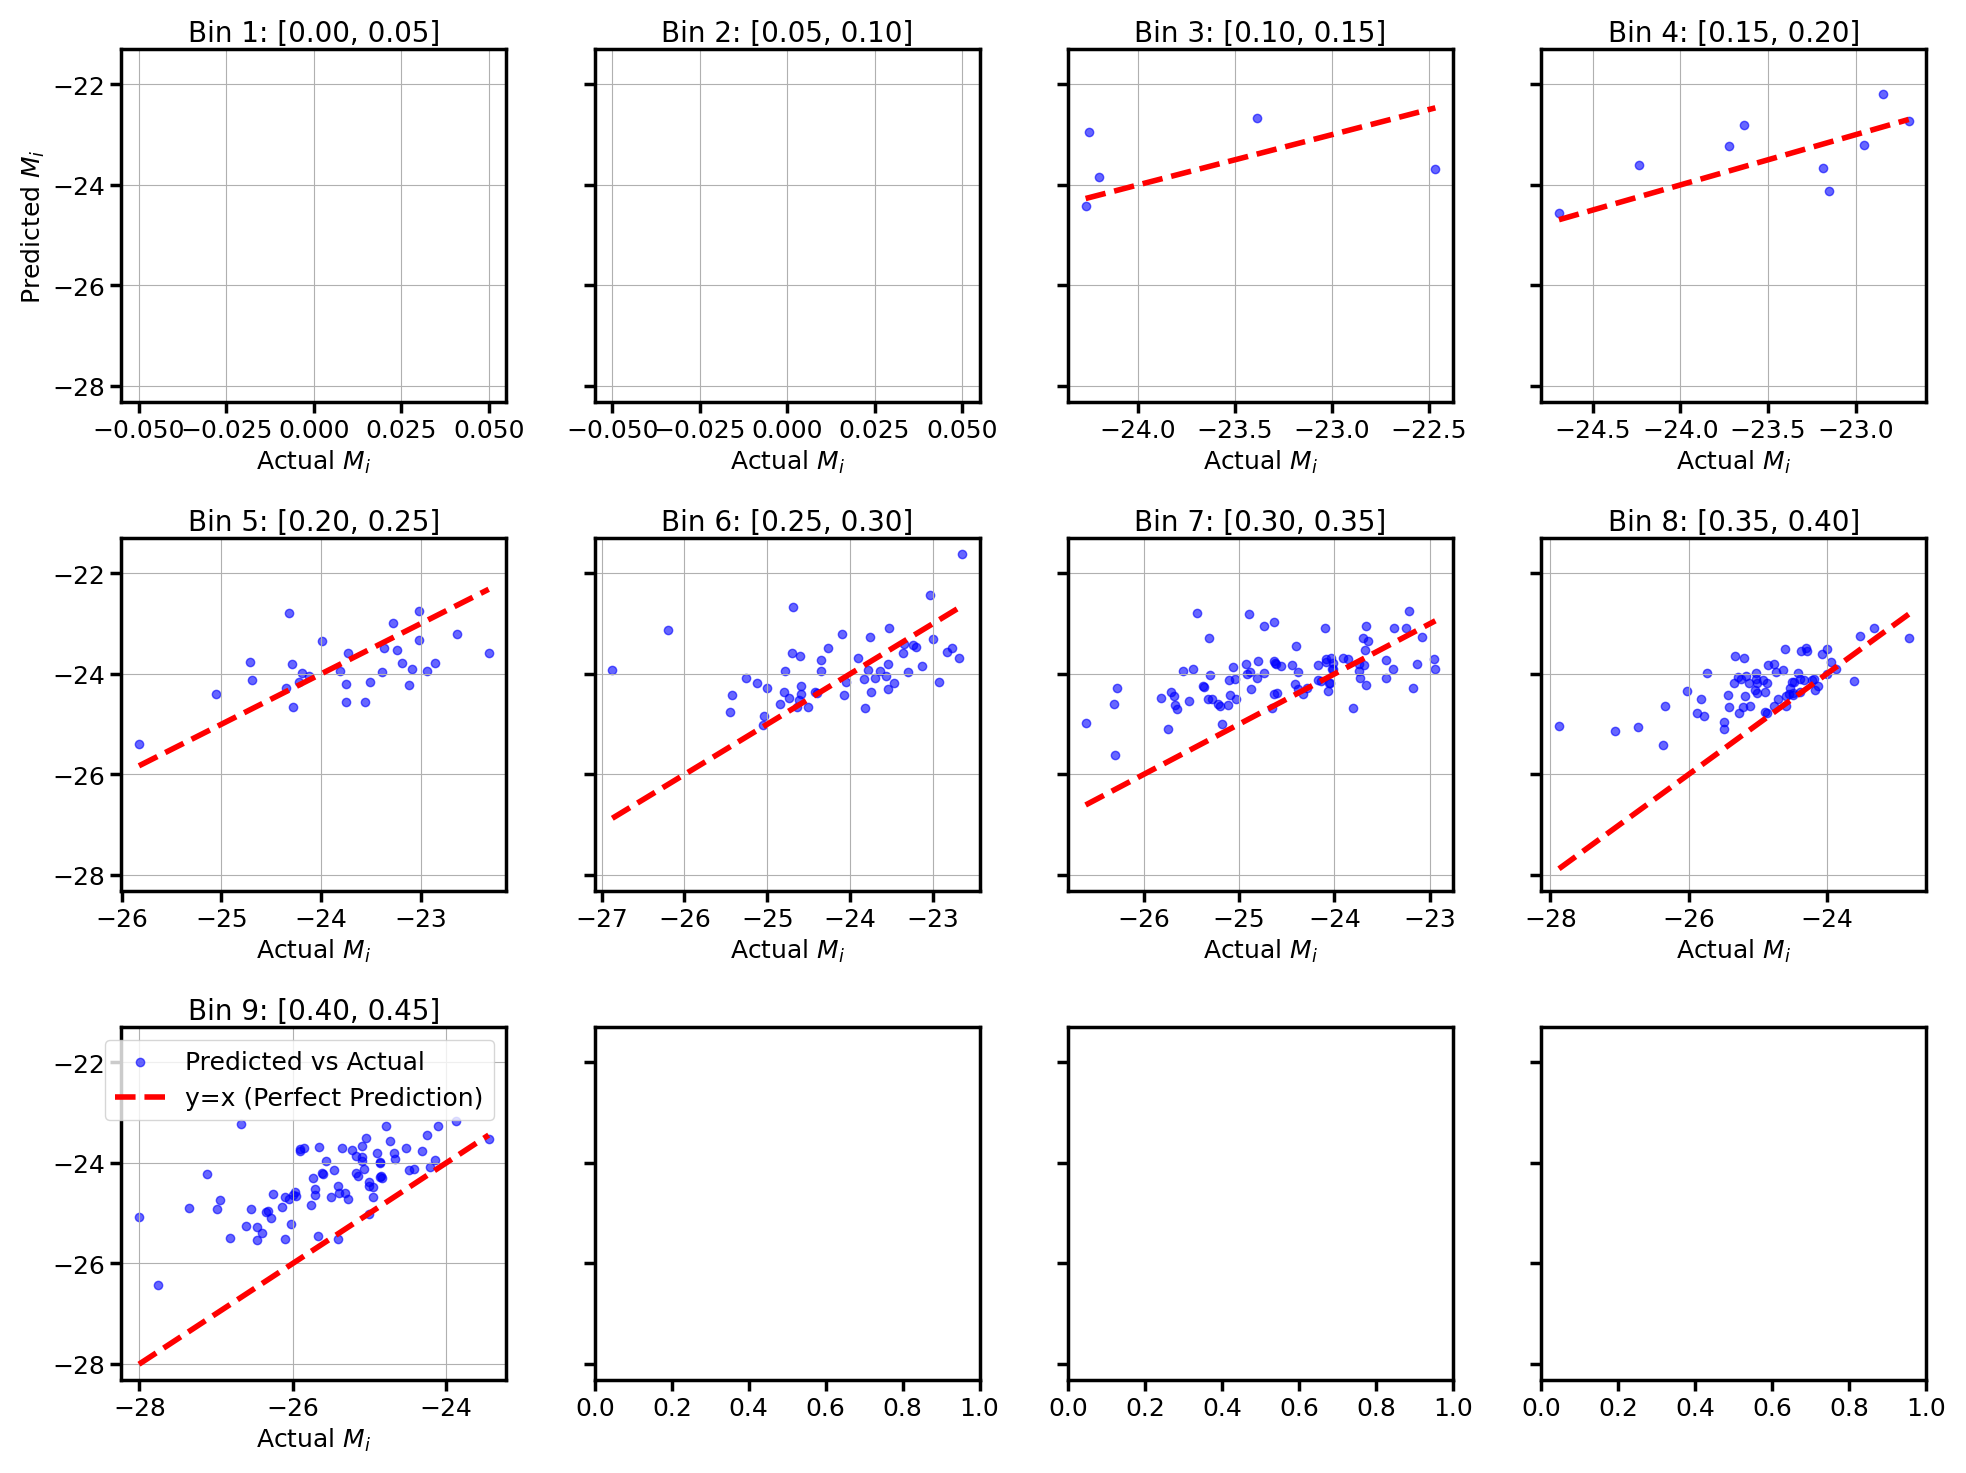

In [110]:
import matplotlib.pyplot as plt
# Define the bins for np.log10(1 + df['z'])
bins = np.arange(0, np.log10(1 + df['z']).max(), 0.05)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Iterate over each bin and plot
for i in range(len(bins) - 1):
    bin_mask = (np.log10(1 + df['z']) >= bins[i]) & (np.log10(1 + df['z']) < bins[i + 1])
    bin_data_actual = actual_M_i[bin_mask]
    bin_data_predicted = M_i_pred[bin_mask]
    
    axes[i].scatter(bin_data_actual, bin_data_predicted, c='blue', alpha=0.6, label='Predicted vs Actual')
    axes[i].plot([bin_data_actual.min(), bin_data_actual.max()], 
                 [bin_data_actual.min(), bin_data_actual.max()], 'r--', label='y=x (Perfect Prediction)')
    axes[i].set_title(f'Bin {i+1}: [{bins[i]:.2f}, {bins[i+1]:.2f}]')
    axes[i].set_xlabel('Actual $M_i$')
    if i == 0:
        axes[i].set_ylabel('Predicted $M_i$')
    axes[i].grid(True)
axes[i].legend()
    
plt.tight_layout()
plt.show()

In [111]:
flat_samples[0,:]

array([  4.4500009 ,  -1.25637321,  -1.01653663, -23.75371233,
        -0.37523595])

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/108216130.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


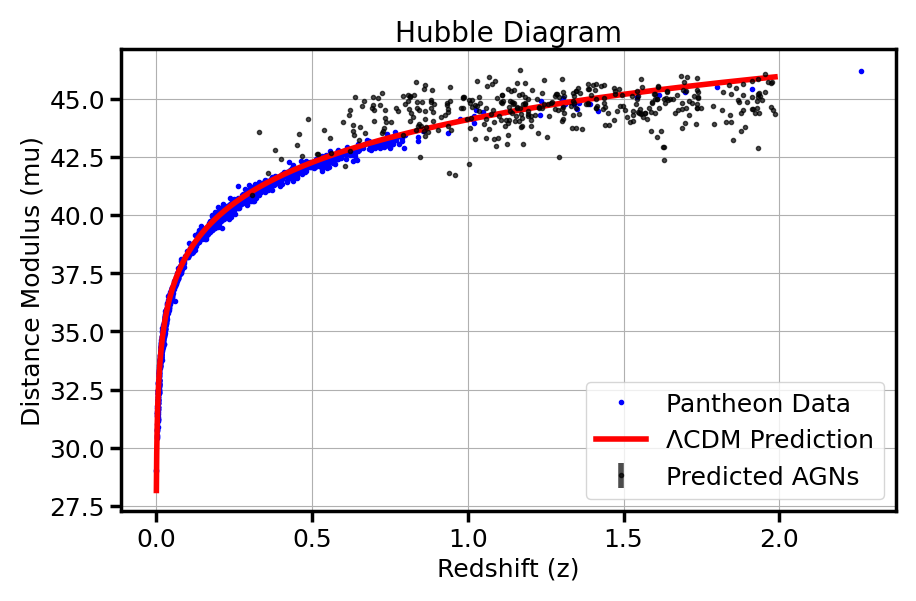

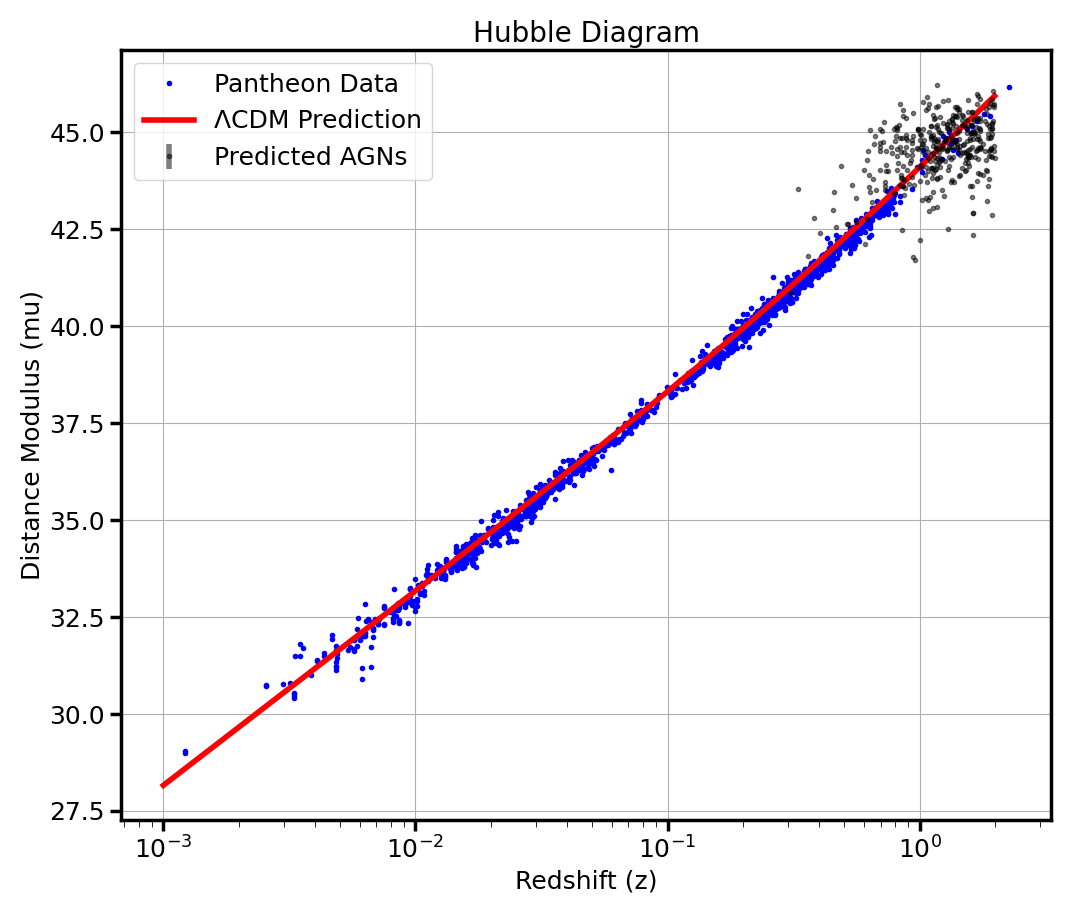

In [112]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon


#mu_pred = d['apparent_mag_i'] - M_model(posterior_samples["alpha"], posterior_samples["beta"], posterior_samples["mu"], posterior_samples["nu"], d["color"], d["log_sigma_3"], d["log_tau_RF"], posterior_samples["M0"], d["z"]) - K_corr(d["z"])
#mu_pred_median = np.percentile(mu_pred, 50, axis=0)
mu_pred = np.array([df['apparent_mag_i'] - M_model(s[3], s[0], s[1], s[2]) - K_corr(df["z"]) for s in flat_samples])
mu_pred_median = np.percentile(mu_pred, 50, axis=0)

#mu_pred_std = np.abs(0.5 * (mu_pred_84th - mu_pred_16th))

plt.figure(figsize=(10, 6))
#plt.errorbar(d["z"], mu, yerr=dmu, fmt='o', label="Observed AGNs", alpha=0.5, color="blue")
plt.errorbar(df["z"], mu_pred_median, yerr=0, fmt='.', label="Predicted AGNs", alpha=0.7, color="black")
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")


z_grid = np.geomspace(0.001, df['z'].max(), 1000)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
plt.plot(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram")
plt.legend()
plt.grid(True)
plt.show()

plt.errorbar(df["z"], mu_pred_median, yerr=0, fmt='.', label="Predicted AGNs", alpha=0.5, color="k")
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")
plt.semilogx(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram")
plt.legend()
plt.grid(True)
plt.show()

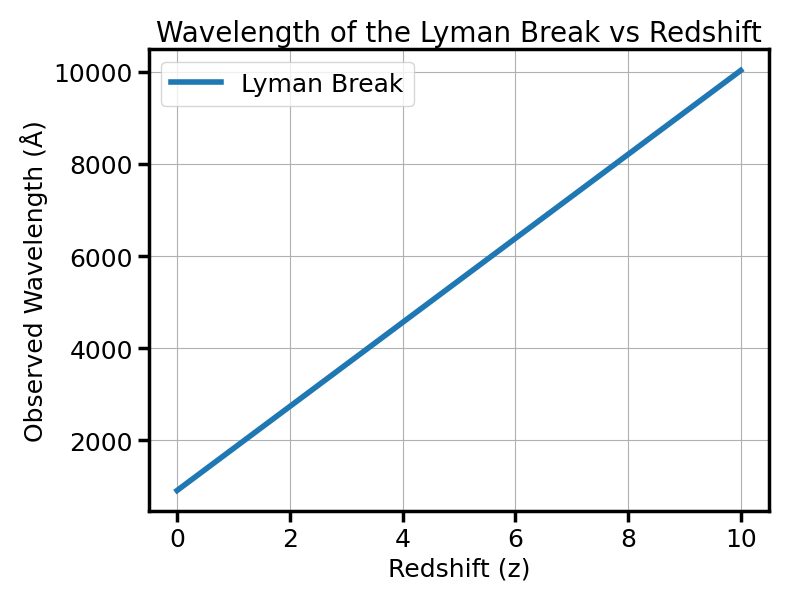

In [113]:
import numpy as np

import matplotlib.pyplot as plt

# Define the rest-frame wavelength of the Lyman break
lyman_break_rest = 912  # in Ångströms

# Define a range of redshifts
redshift = np.linspace(0, 10, 1000)

# Calculate the observed wavelength
lyman_break_observed = lyman_break_rest * (1 + redshift)

# Plot the wavelength of the Lyman break vs redshift
plt.figure(figsize=(8, 6))
plt.plot(redshift, lyman_break_observed, label="Lyman Break")
plt.xlabel("Redshift (z)")
plt.ylabel("Observed Wavelength (Å)")
plt.title("Wavelength of the Lyman Break vs Redshift")
plt.grid(True)
plt.legend()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/692567285.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')


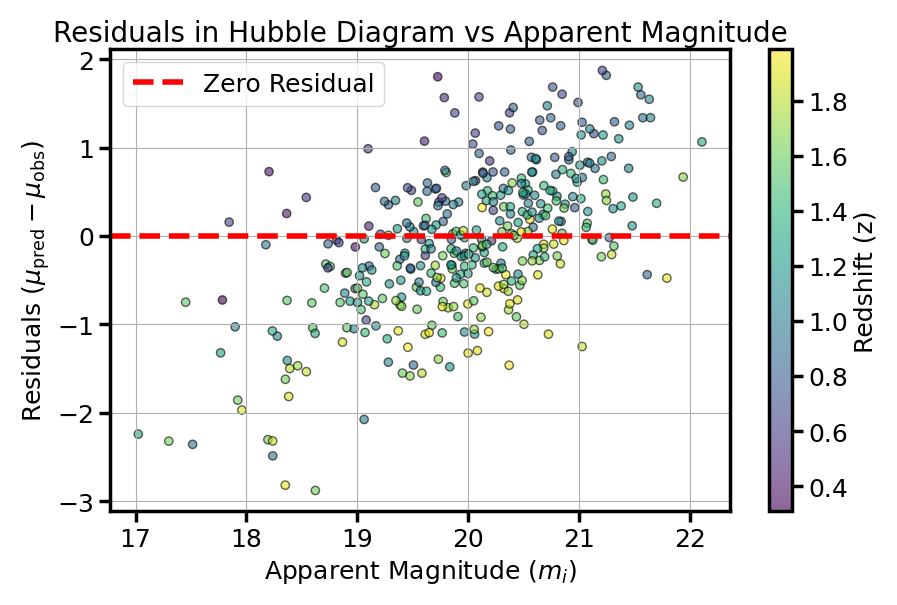

In [114]:
import matplotlib.pyplot as plt

# Calculate the observed distance modulus (mu_obs)
mu_obs = df['apparent_mag_i'] - df['M_i']

# Calculate the residuals (difference between predicted and observed distance modulus)
residuals = mu_pred_median - mu_obs

# Use d['z'] as the color for the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['apparent_mag_i'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Apparent Magnitude ($m_i$)')
plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title('Residuals in Hubble Diagram vs Apparent Magnitude')
plt.colorbar(scatter, label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_3826/87464218.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')


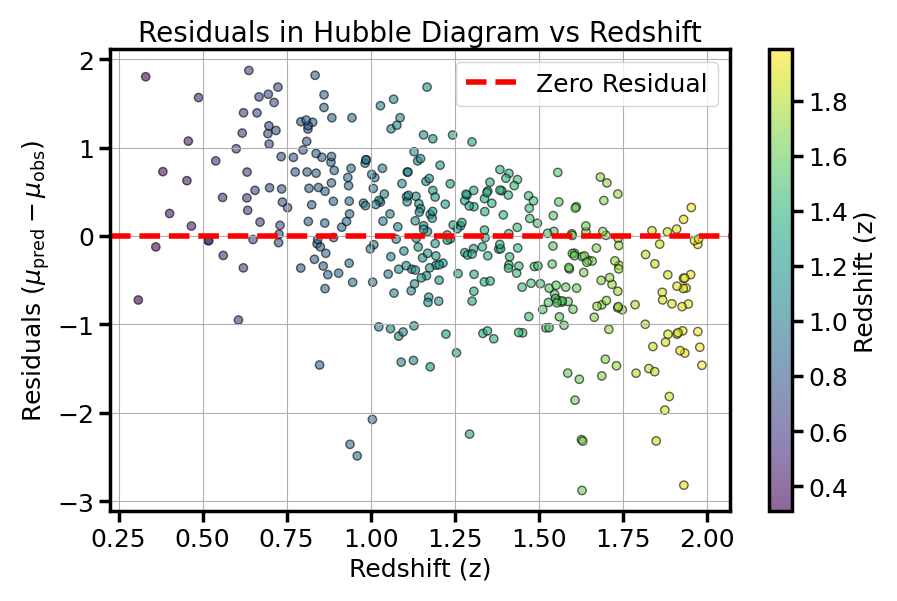

In [115]:
import matplotlib.pyplot as plt

# Plot residuals vs redshift
plt.figure(figsize=(10, 6))
plt.scatter(df['z'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Redshift (z)')
plt.ylabel('Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title('Residuals in Hubble Diagram vs Redshift')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

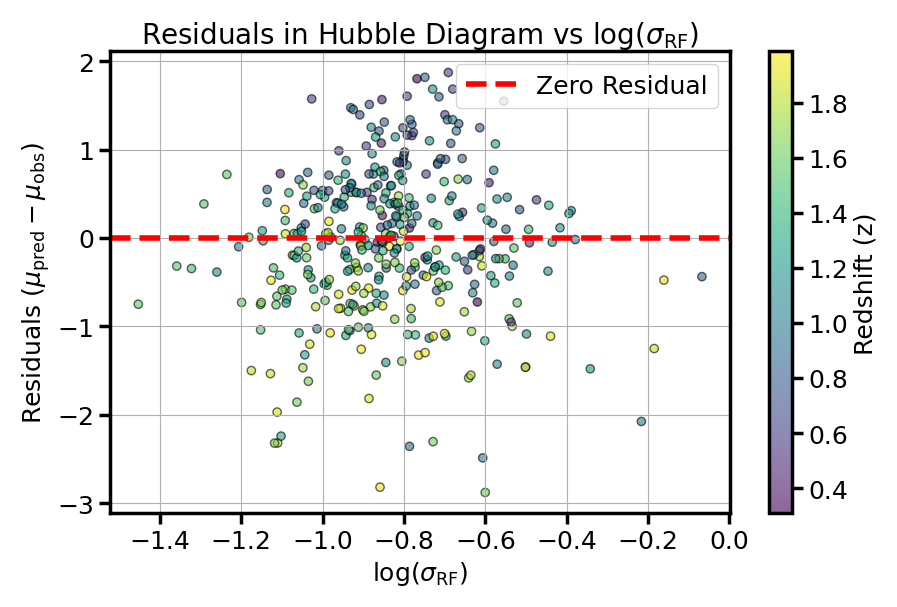

In [116]:
import matplotlib.pyplot as plt

# Plot residuals vs log_sigma_RF
plt.figure(figsize=(10, 6))
plt.scatter(df['log_sigma_RF'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\log(\sigma_\mathrm{RF})$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\log(\sigma_\mathrm{RF})$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

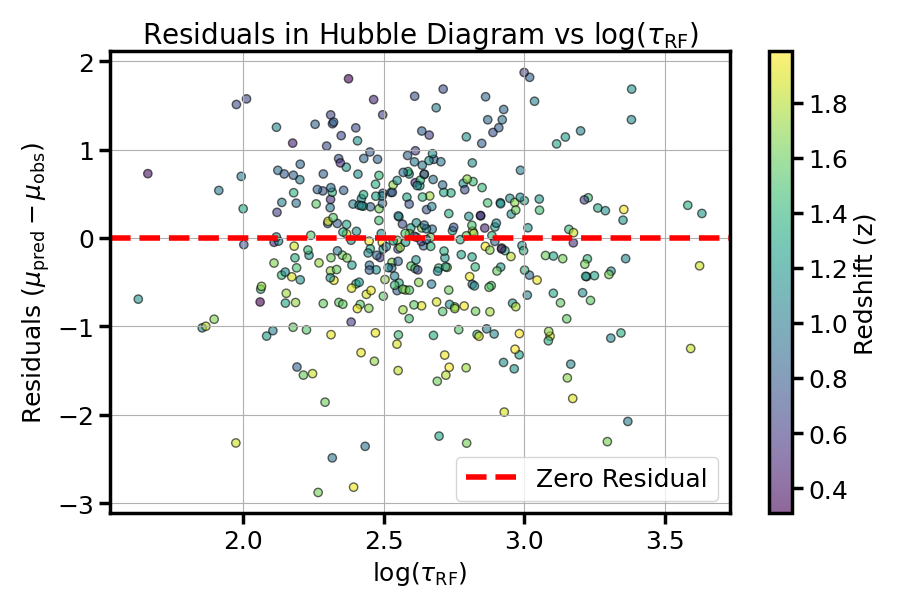

In [117]:
import matplotlib.pyplot as plt

# Plot residuals vs log_tau_RF
plt.figure(figsize=(10, 6))
plt.scatter(df['log_tau_RF'], residuals, c=df['z'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel(r'$\log(\tau_\mathrm{RF})$')
plt.ylabel(r'Residuals ($\mu_\mathrm{pred} - \mu_\mathrm{obs}$)')
plt.title(r'Residuals in Hubble Diagram vs $\log(\tau_\mathrm{RF})$')
plt.colorbar(label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

In [118]:
plt.figure(figsize=(10, 6))

# Plot AGNs with color-coded points
plt.scatter(d["z"], mu_pred_median, c=d["color"], cmap="viridis", alpha=0.6, label="Predicted AGNs")
plt.colorbar(label="g-i")

# Plot Pantheon data
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")

# Plot ΛCDM prediction
z_grid = np.geomspace(0.001, d['z'].max(), 1000)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
plt.plot(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")

plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram (AGN Colored by Color)")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'd' is not defined

<Figure size 1000x600 with 0 Axes>

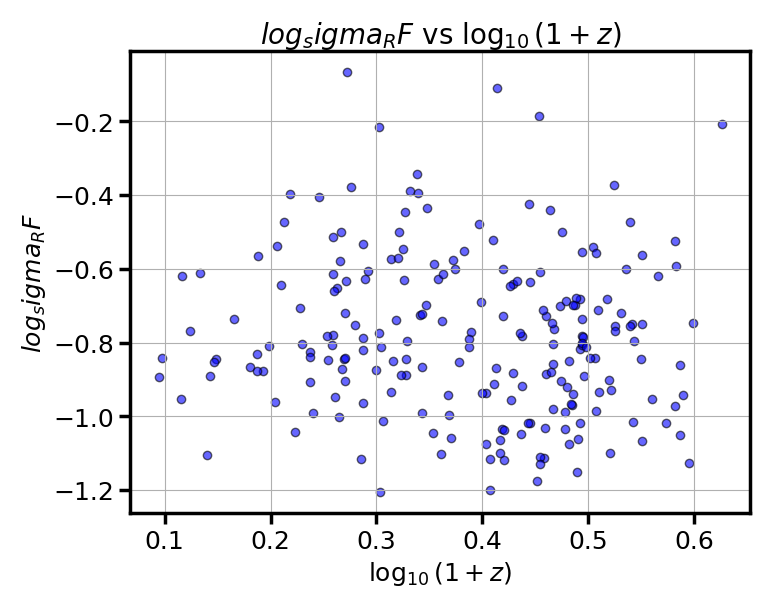

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log10(1 + df['z']), df['log_sigma_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\log_{10}(1+z)$")
plt.ylabel(r"$log_sigma_RF$")
plt.title(r"$log_sigma_RF$ vs $\log_{10}(1+z)$")
plt.grid(True)
plt.show()

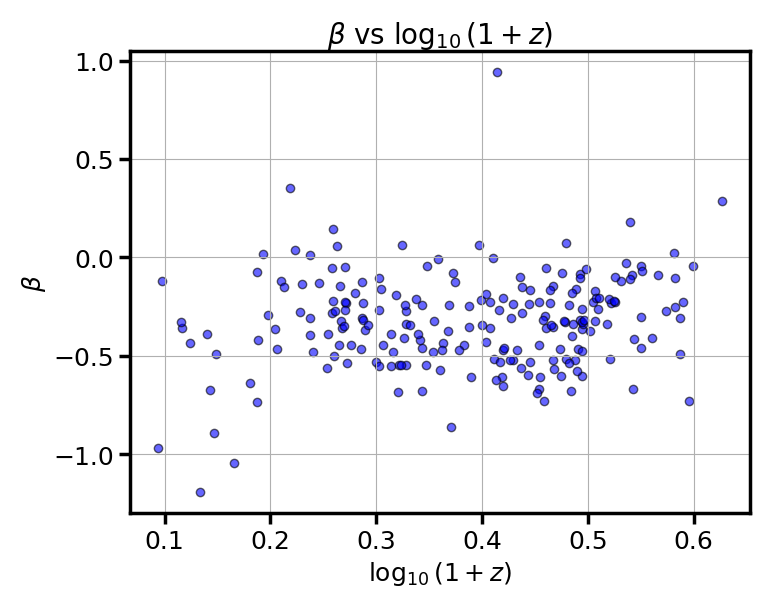

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log10(1 + df['z']), df['beta'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\log_{10}(1+z)$")
plt.ylabel(r"$\beta$")
plt.title(r"$\beta$ vs $\log_{10}(1+z)$")
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


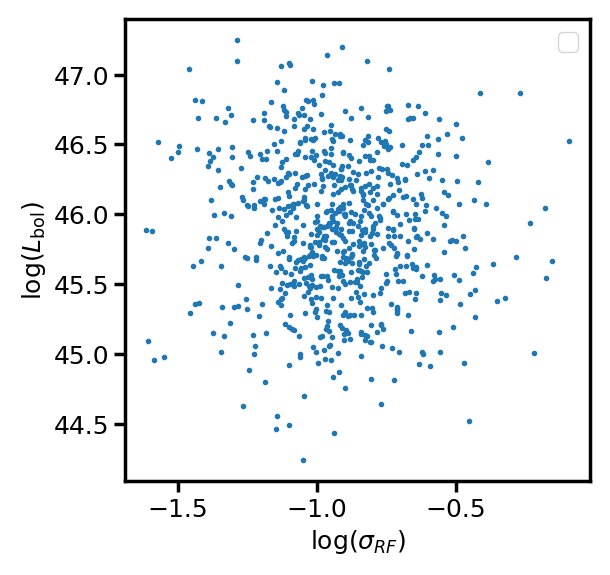

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharey='row')

# First row
ax.scatter(df['log_sigma_band_i'], df['log_lbol'], marker='.')
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
ax.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


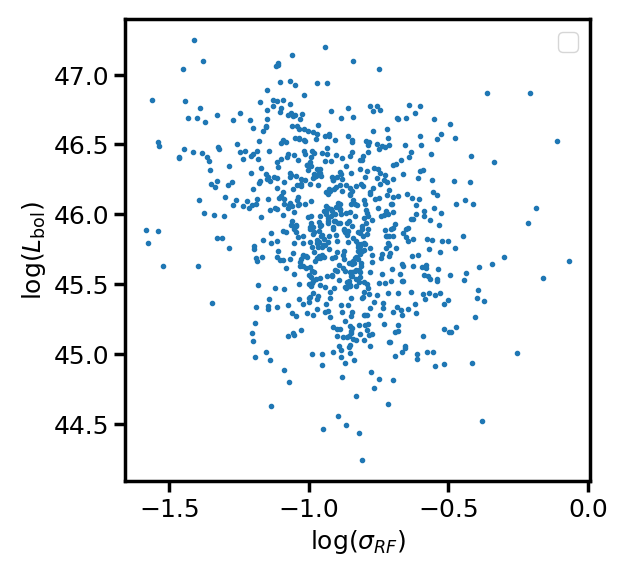

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharey='row')

# First row
ax.scatter(df['log_sigma_RF'], df['log_lbol'], marker='.')
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
ax.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


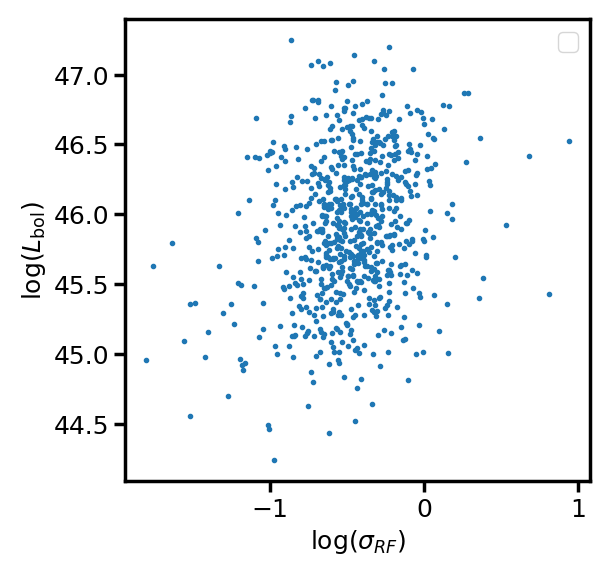

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharey='row')

# First row
ax.scatter(df['beta'], df['log_lbol'], marker='.')
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
ax.legend()

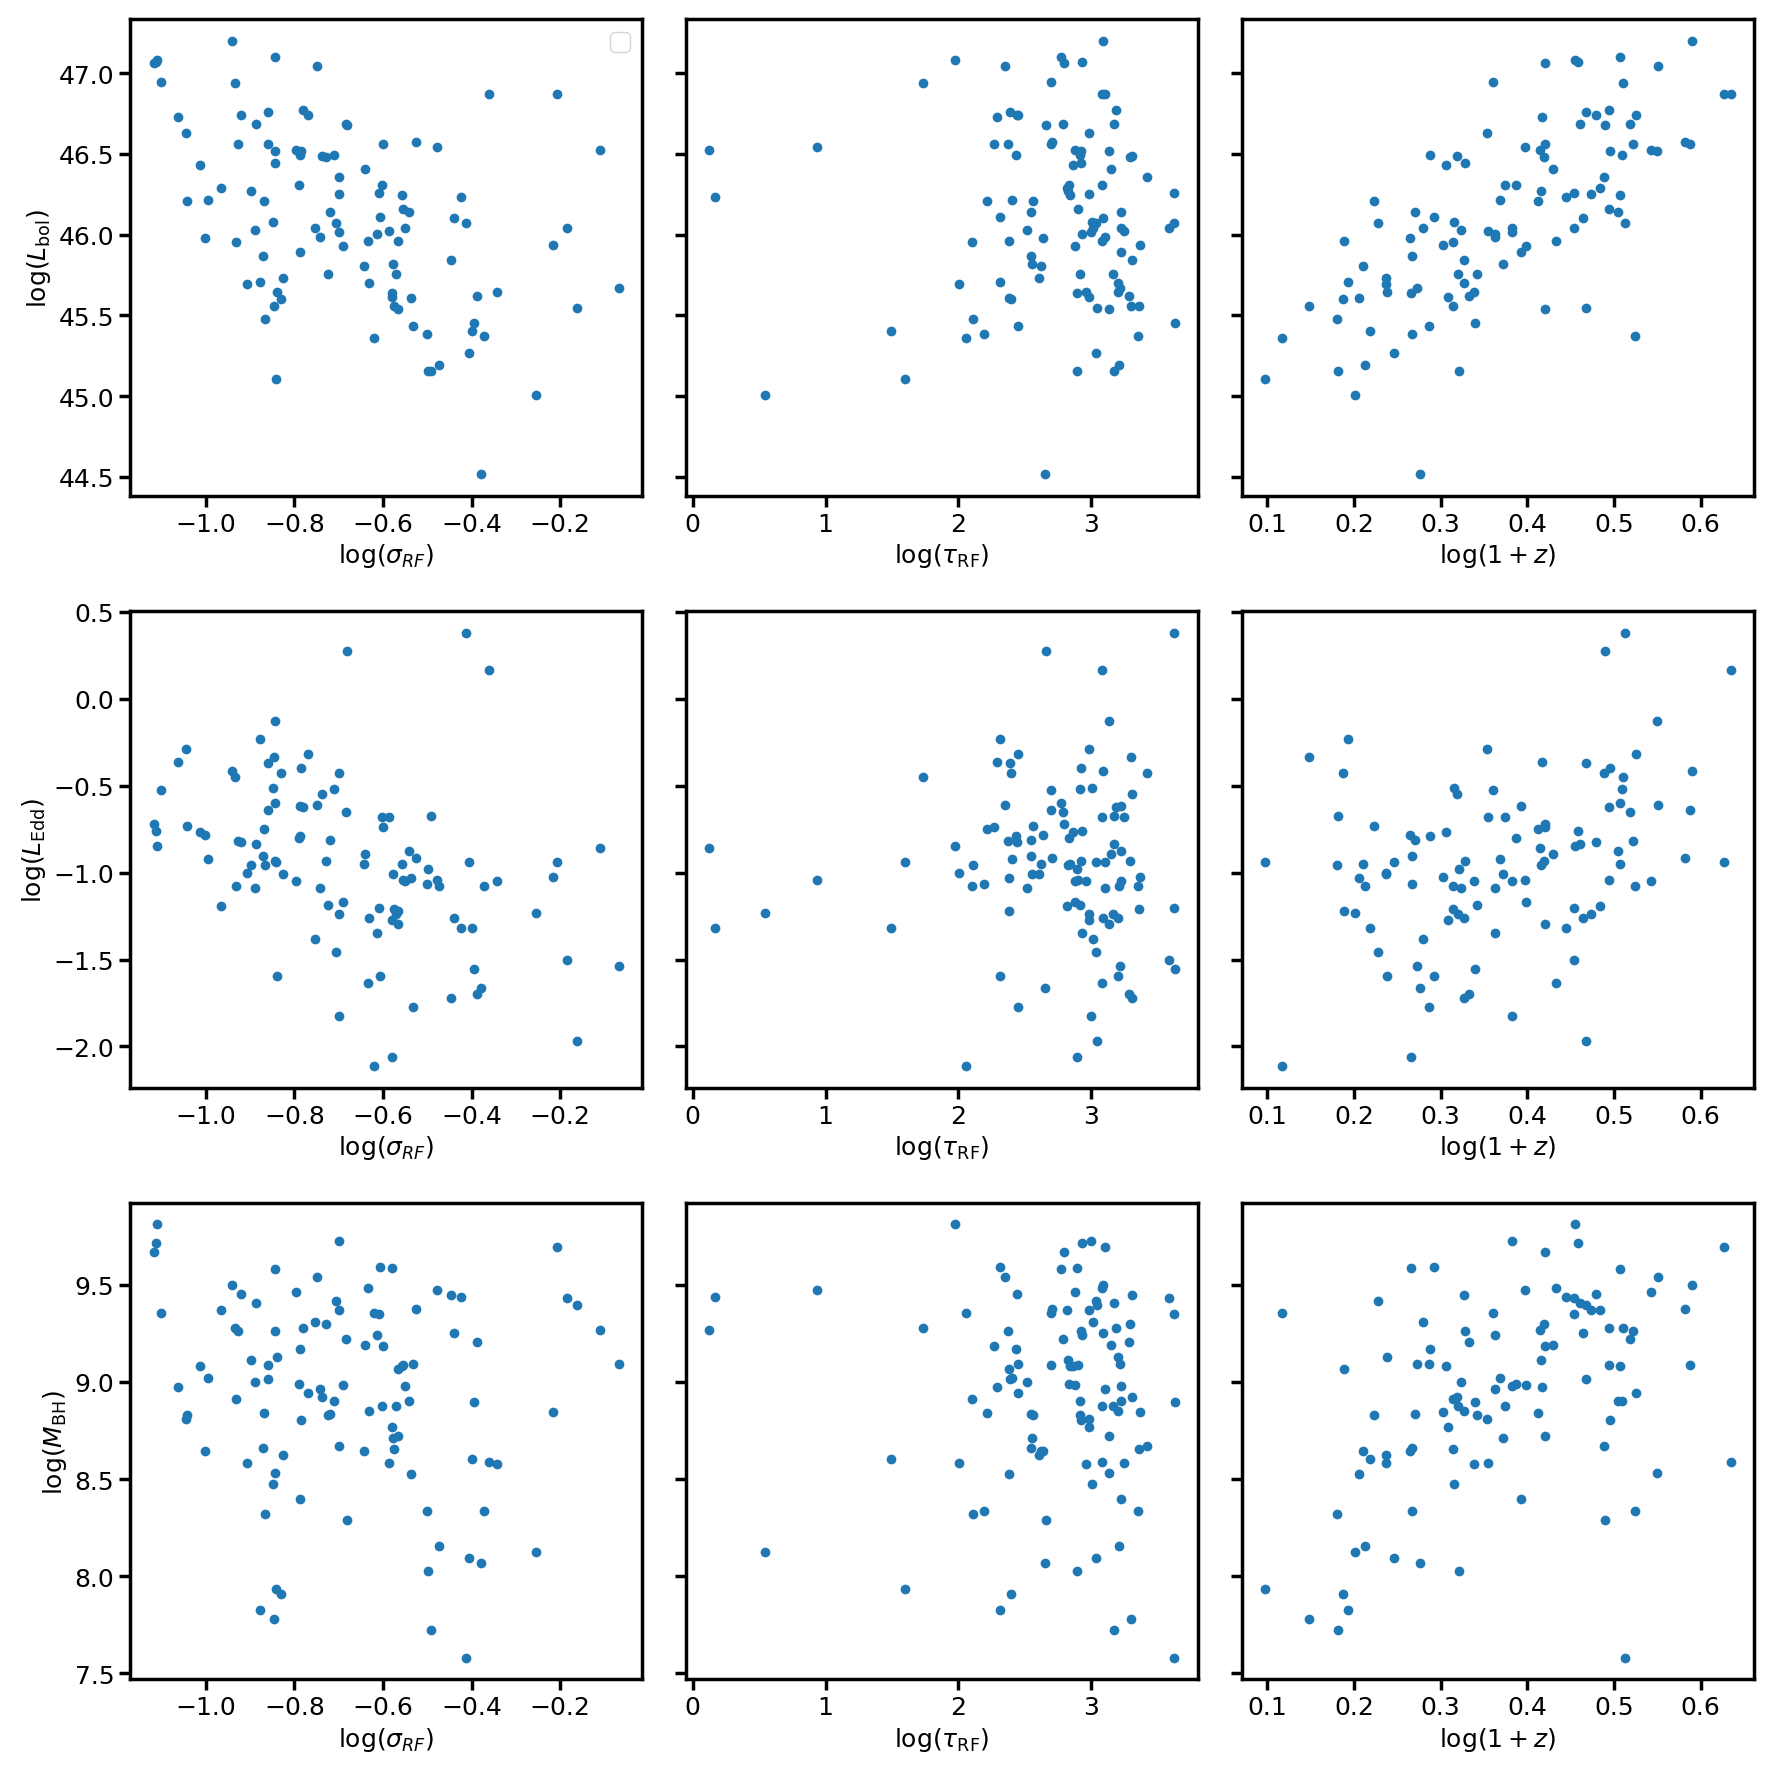

In [ ]:

fig, axs = plt.subplots(3, 3, figsize=(3*6, 3*6), sharey='row')

# First row
ax = axs[0, 0]
#ax.scatter(df['log_sigma'], df['log_lbol'], marker='.')
ax.scatter(df['log_sigma_RF'], df['log_lbol'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
ax.legend()

ax = axs[0, 1]
ax.scatter(df['log_tau_RF'], df['log_lbol'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[0, 2]
ax.scatter(np.log10(1+df['z']), df['log_lbol'])
ax.set_xlabel(r"$\log(1+z)$")

# Second row
ax = axs[1, 0]
ax.scatter(df['log_sigma_RF'], df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(L_\mathrm{Edd})$")

ax = axs[1, 1]
ax.scatter(df['log_tau_RF'], df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[1, 2]
ax.scatter(np.log10(1+df['z']), df['log_ledd_ratio'])
ax.set_xlabel(r"$\log(1+z)$")

# Third row
ax = axs[2, 0]
ax.scatter(df['log_sigma_RF'], df['log_mbh'])
ax.set_xlabel(r"$\log(\sigma_{RF})$")
ax.set_ylabel(r"$\log(M_\mathrm{BH})$")

ax = axs[2, 1]
ax.scatter(df['log_tau_RF'], df['log_mbh'])
ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

ax = axs[2, 2]
ax.scatter(np.log10(1+df['z']), df['log_mbh'])
ax.set_xlabel(r"$\log(1+z)$")

plt.tight_layout()
plt.show()
plt.close()

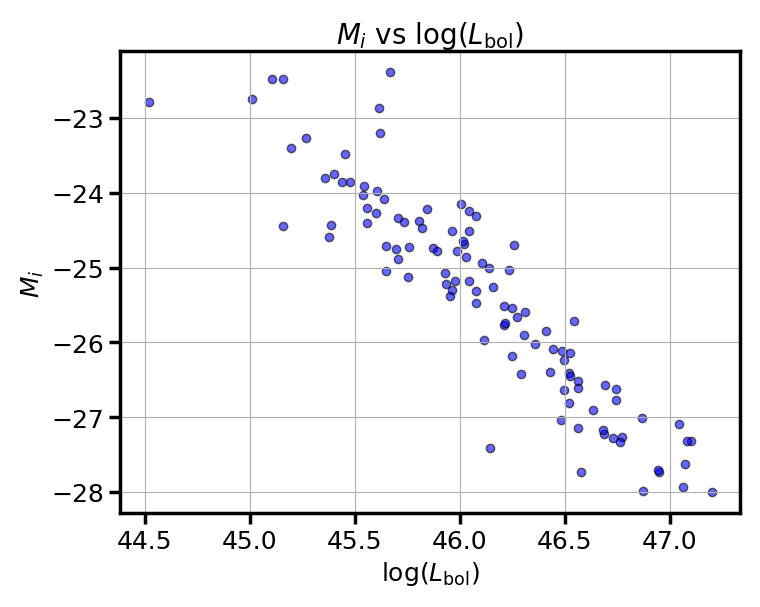

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_lbol'], df['M_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\log(L_\mathrm{bol})$")
plt.ylabel(r"$M_i$")
plt.title(r"$M_i$ vs $\log(L_\mathrm{bol})$")
plt.grid(True)
plt.show()

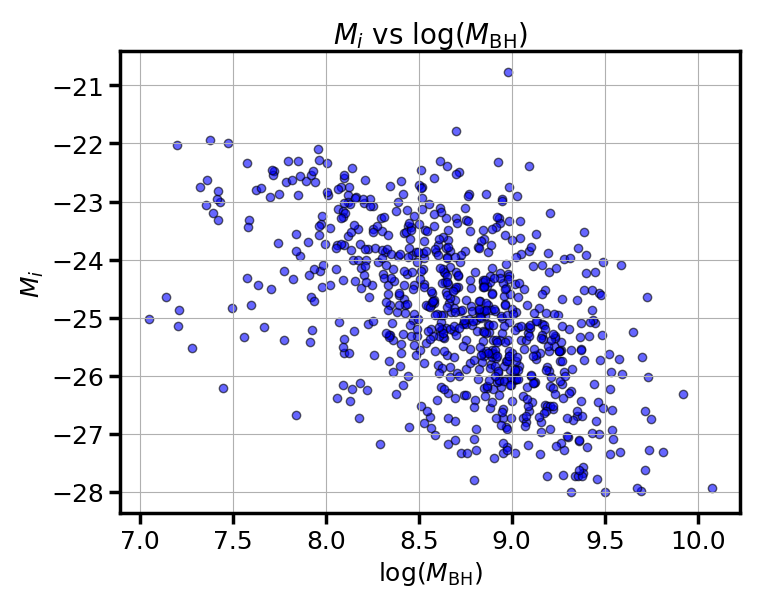

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_mbh'], df['M_i'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel(r"$\log(M_\mathrm{BH})$")
plt.ylabel(r"$M_i$")
plt.title(r"$M_i$ vs $\log(M_\mathrm{BH})$")
plt.grid(True)
plt.show()

In [ ]:
df[df['log_tau_RF']<1]

,object_id,ra,dec,z,sdss_name,log_lbol,log_lbol_err,log_mbh,log_mbh_err,log_ledd_ratio,...,magerrs_mean_y,z_sys_lines,z_sys_lines_err,ebv,M_i,apparent_mag_i,apparent_mag_i_err,color,fhost_5100,log_lambda_RF
1159,1430723,11.314351,-1.221594,1.594640,004515.44-011317.7,46.525820,0.002171,9.270142,0.139521,-0.858266,...,0.0,"[0.0, 0.0, 0.0, 0.0, 1.594599170606564, 1.6066...","[-1.0, -1.0, -1.0, -1.0, 0.0018364829770072552...",0.017388,-26.143669,18.383210,0.047208,0.835198,0.0,3.468163
1577,1433264,9.478928,0.453517,0.590398,003754.94+002712.6,45.008210,0.006667,8.125560,0.077764,-1.231293,...,0.0,"[0.5906125923536285, 0.5906107405288954, 0.590...","[0.0025398239541018063, 0.00033215136585004154...",0.017189,-22.745237,19.609063,0.034405,2.168244,0.0,3.680734
1760,1434298,8.700144,0.734654,1.783700,003448.03+004404.7,46.232870,0.005142,9.435683,0.132775,-1.316756,...,0.0,"[0.0, 0.0, 0.0, 0.0, 1.7862187023779086, 1.779...","[-1.0, -1.0, -1.0, -1.0, 0.002646504073145182,...",0.016704,-25.037201,19.776020,0.047661,0.335201,0.0,3.437617
1776,1434383,8.632463,-0.165954,1.496537,003431.79-000957.4,46.543852,0.002057,9.473859,0.015521,-1.043950,...,0.0,"[0.0, 0.0, 0.0, 0.0, 1.4965169968591008, 1.495...","[-1.0, -1.0, -1.0, -1.0, 0.0018015690126527777...",0.016254,-25.717868,18.656505,0.026106,0.772666,0.0,3.484902


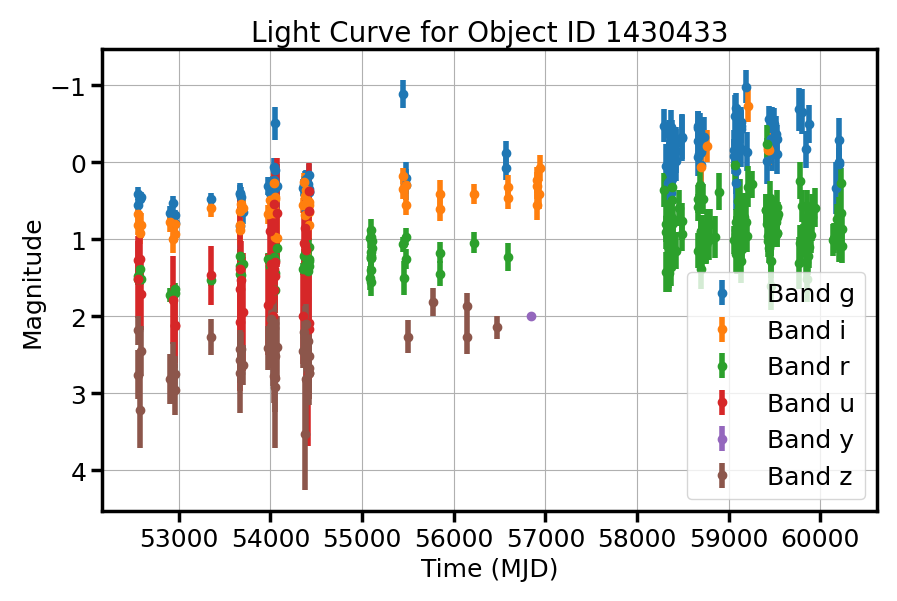

In [ ]:
def plot_light_curve(object_id):
    if object_id not in objs.index:
        print(f"Object ID {object_id} not found in the dataset.")
        return
    
    obj_data = objs.loc[object_id]
    times = obj_data['times']
    mags = obj_data['mags']
    magerrs = obj_data['magerrs']
    
    plt.figure(figsize=(10, 6))
    for i, band in enumerate(times.keys()):
        plt.errorbar(times[band], mags[band]+i*.5, yerr=magerrs[band], fmt='o', label=f'Band {band}')
    
    plt.xlabel('Time (MJD)')
    plt.ylabel('Magnitude')
    plt.title(f'Light Curve for Object ID {object_id}')
    plt.gca().invert_yaxis()  # Magnitudes are plotted with brighter objects lower
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
plot_light_curve(1430433)  # Replace with the desired object ID 

Plotting for range: 0.00 to 0.05


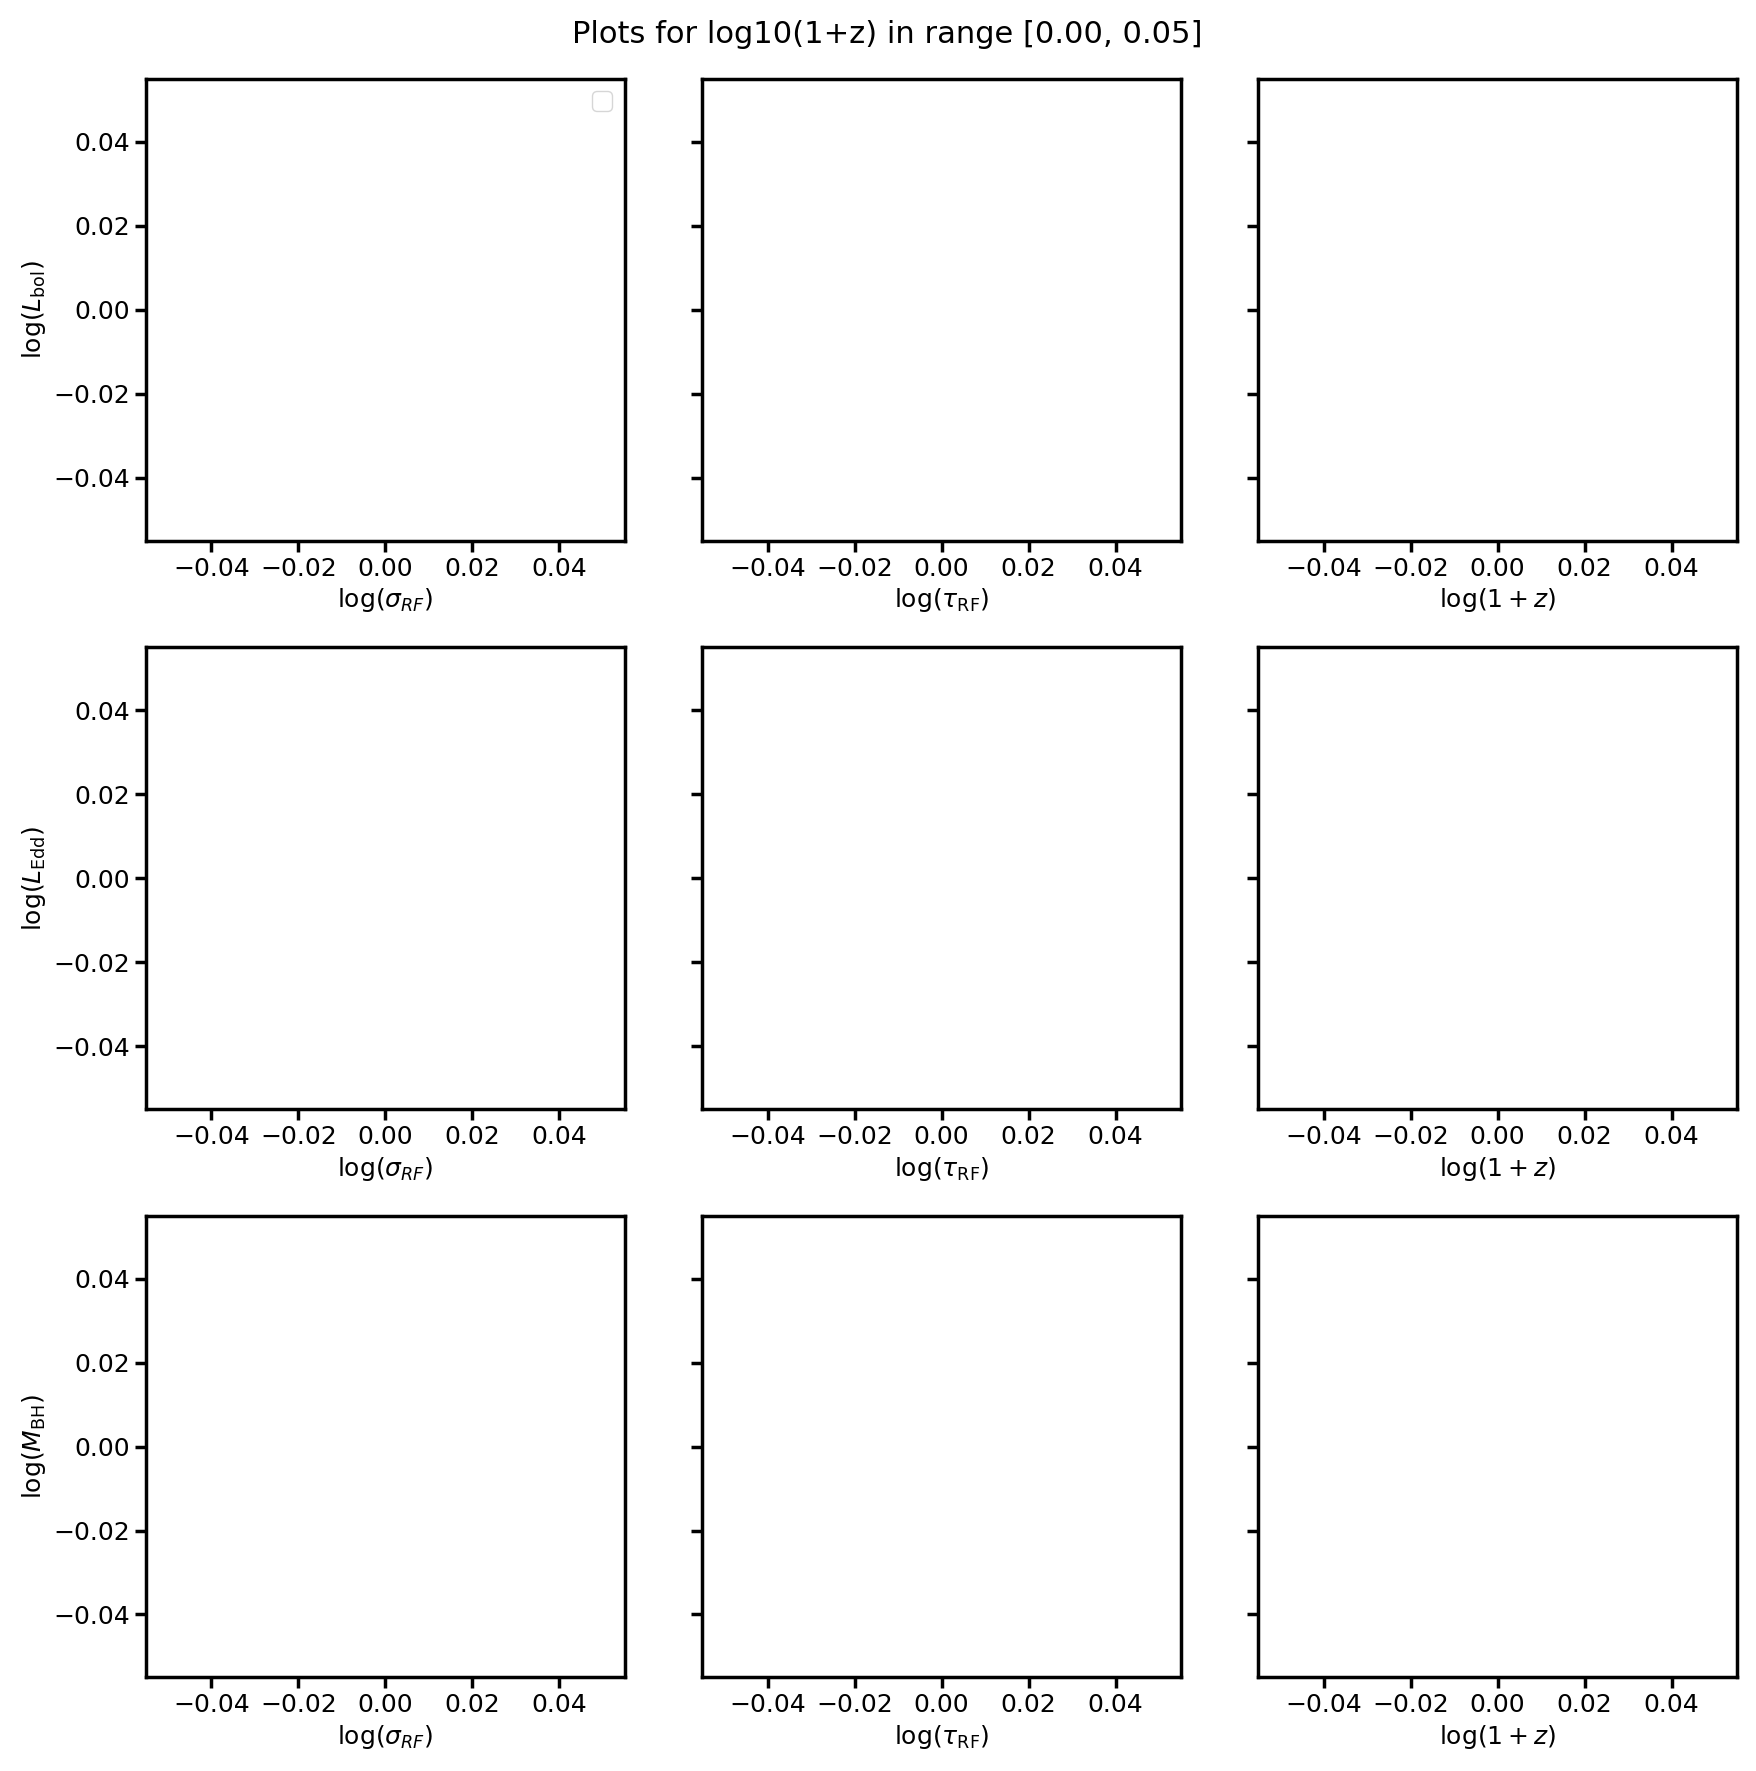

Plotting for range: 0.05 to 0.10


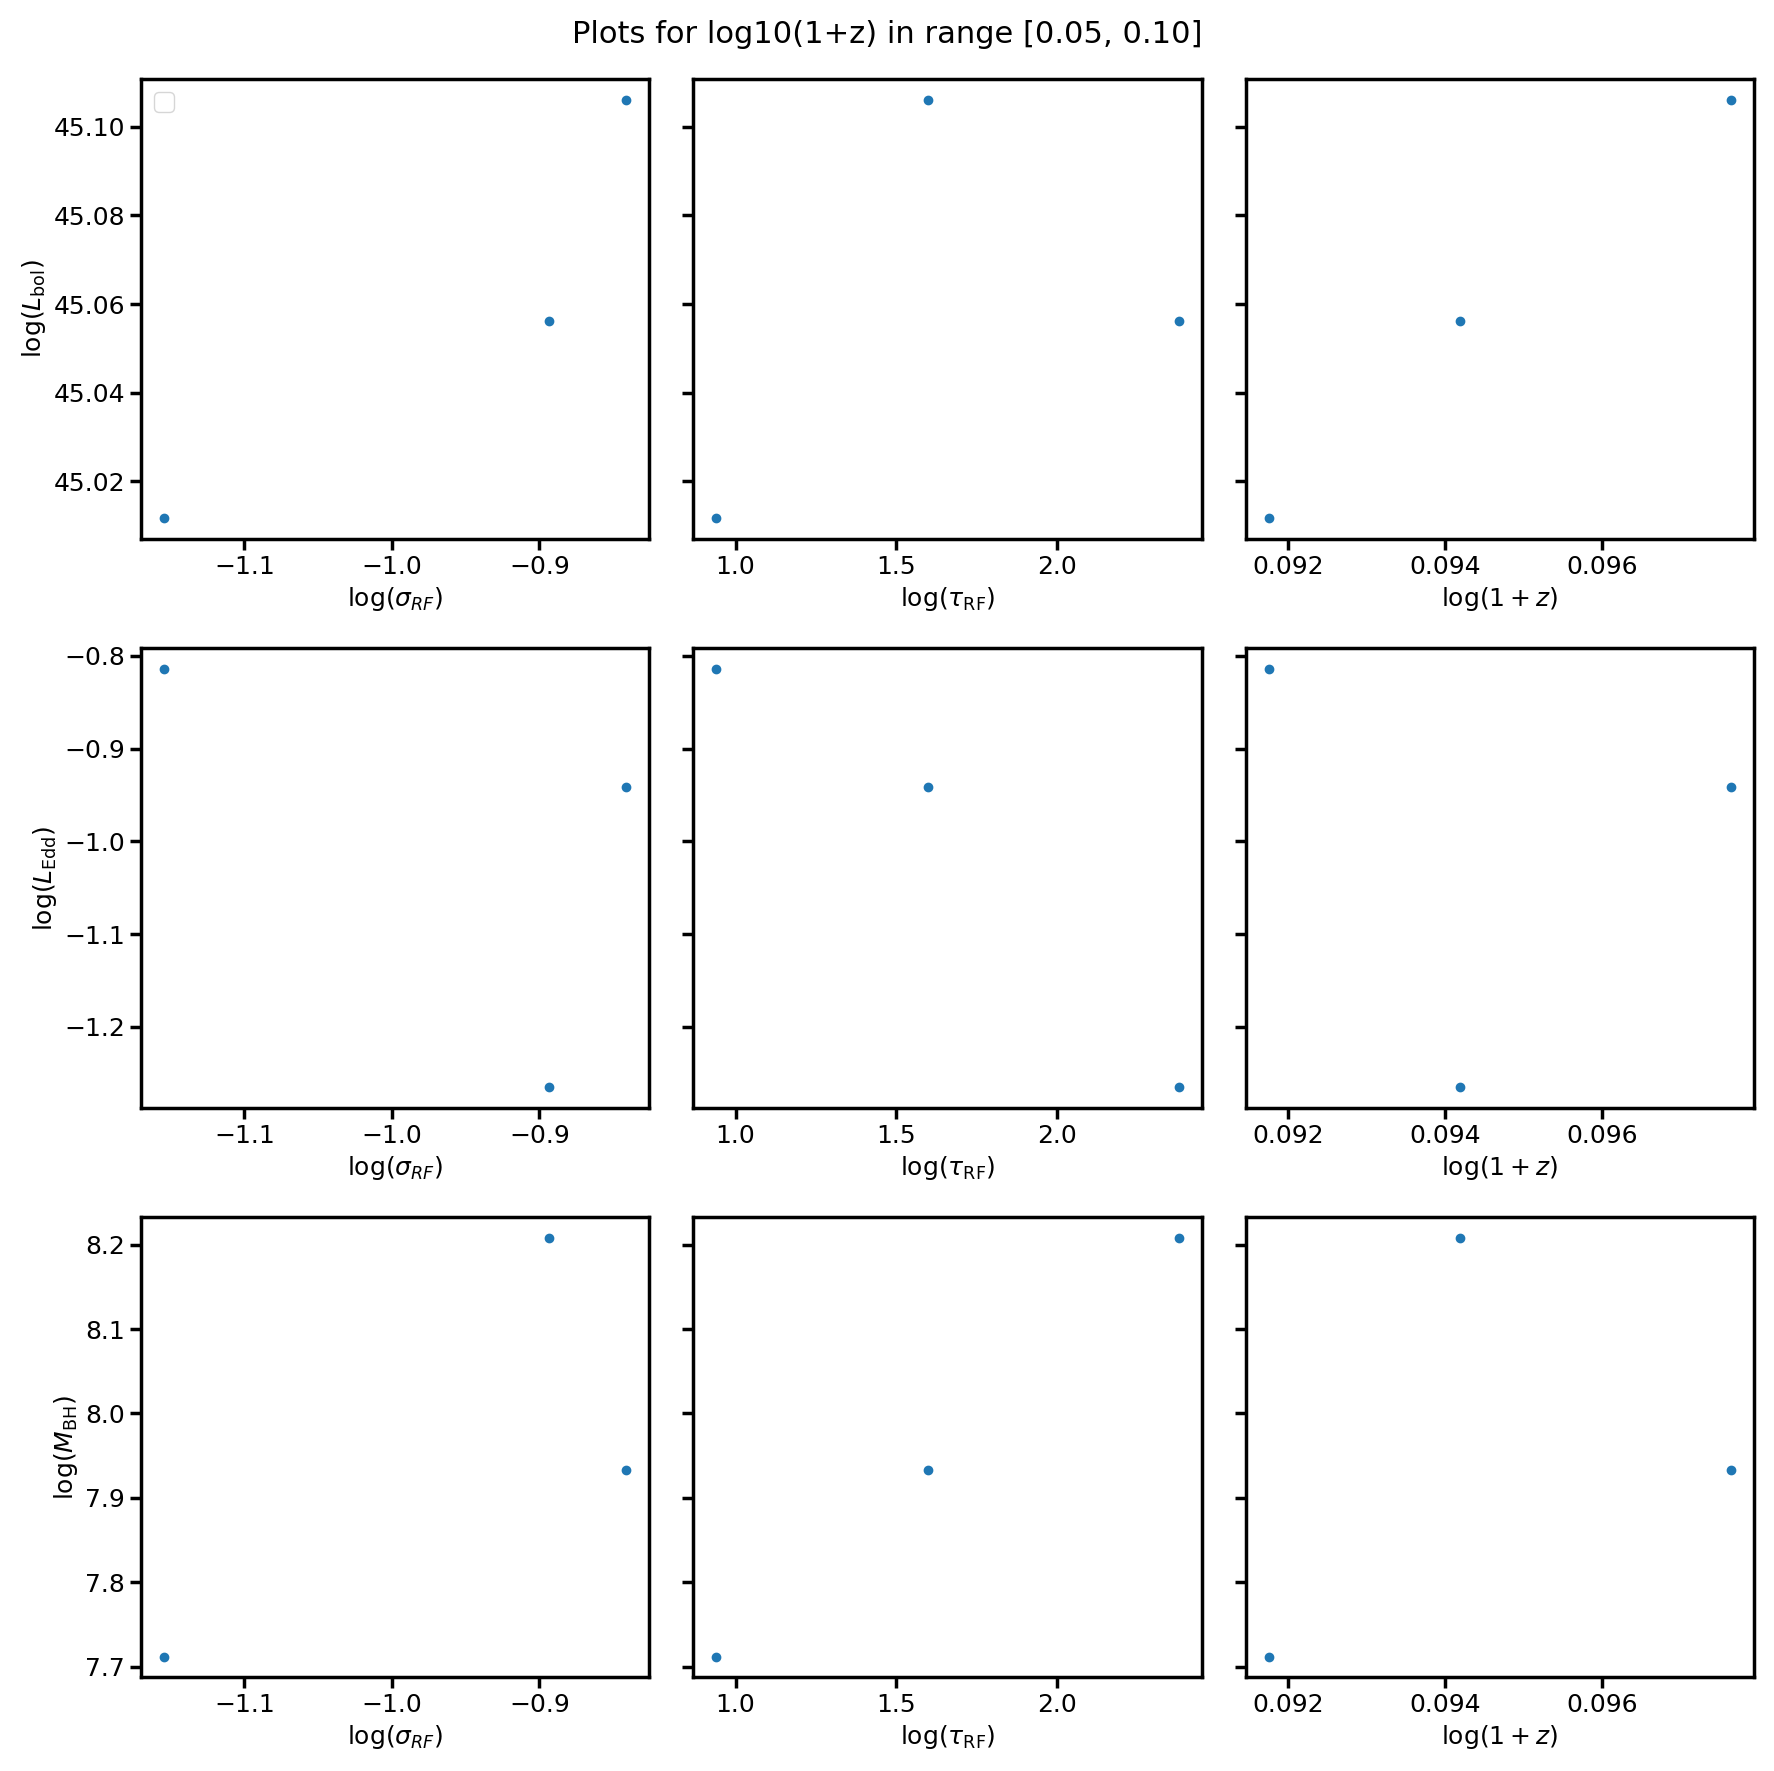

Plotting for range: 0.10 to 0.15


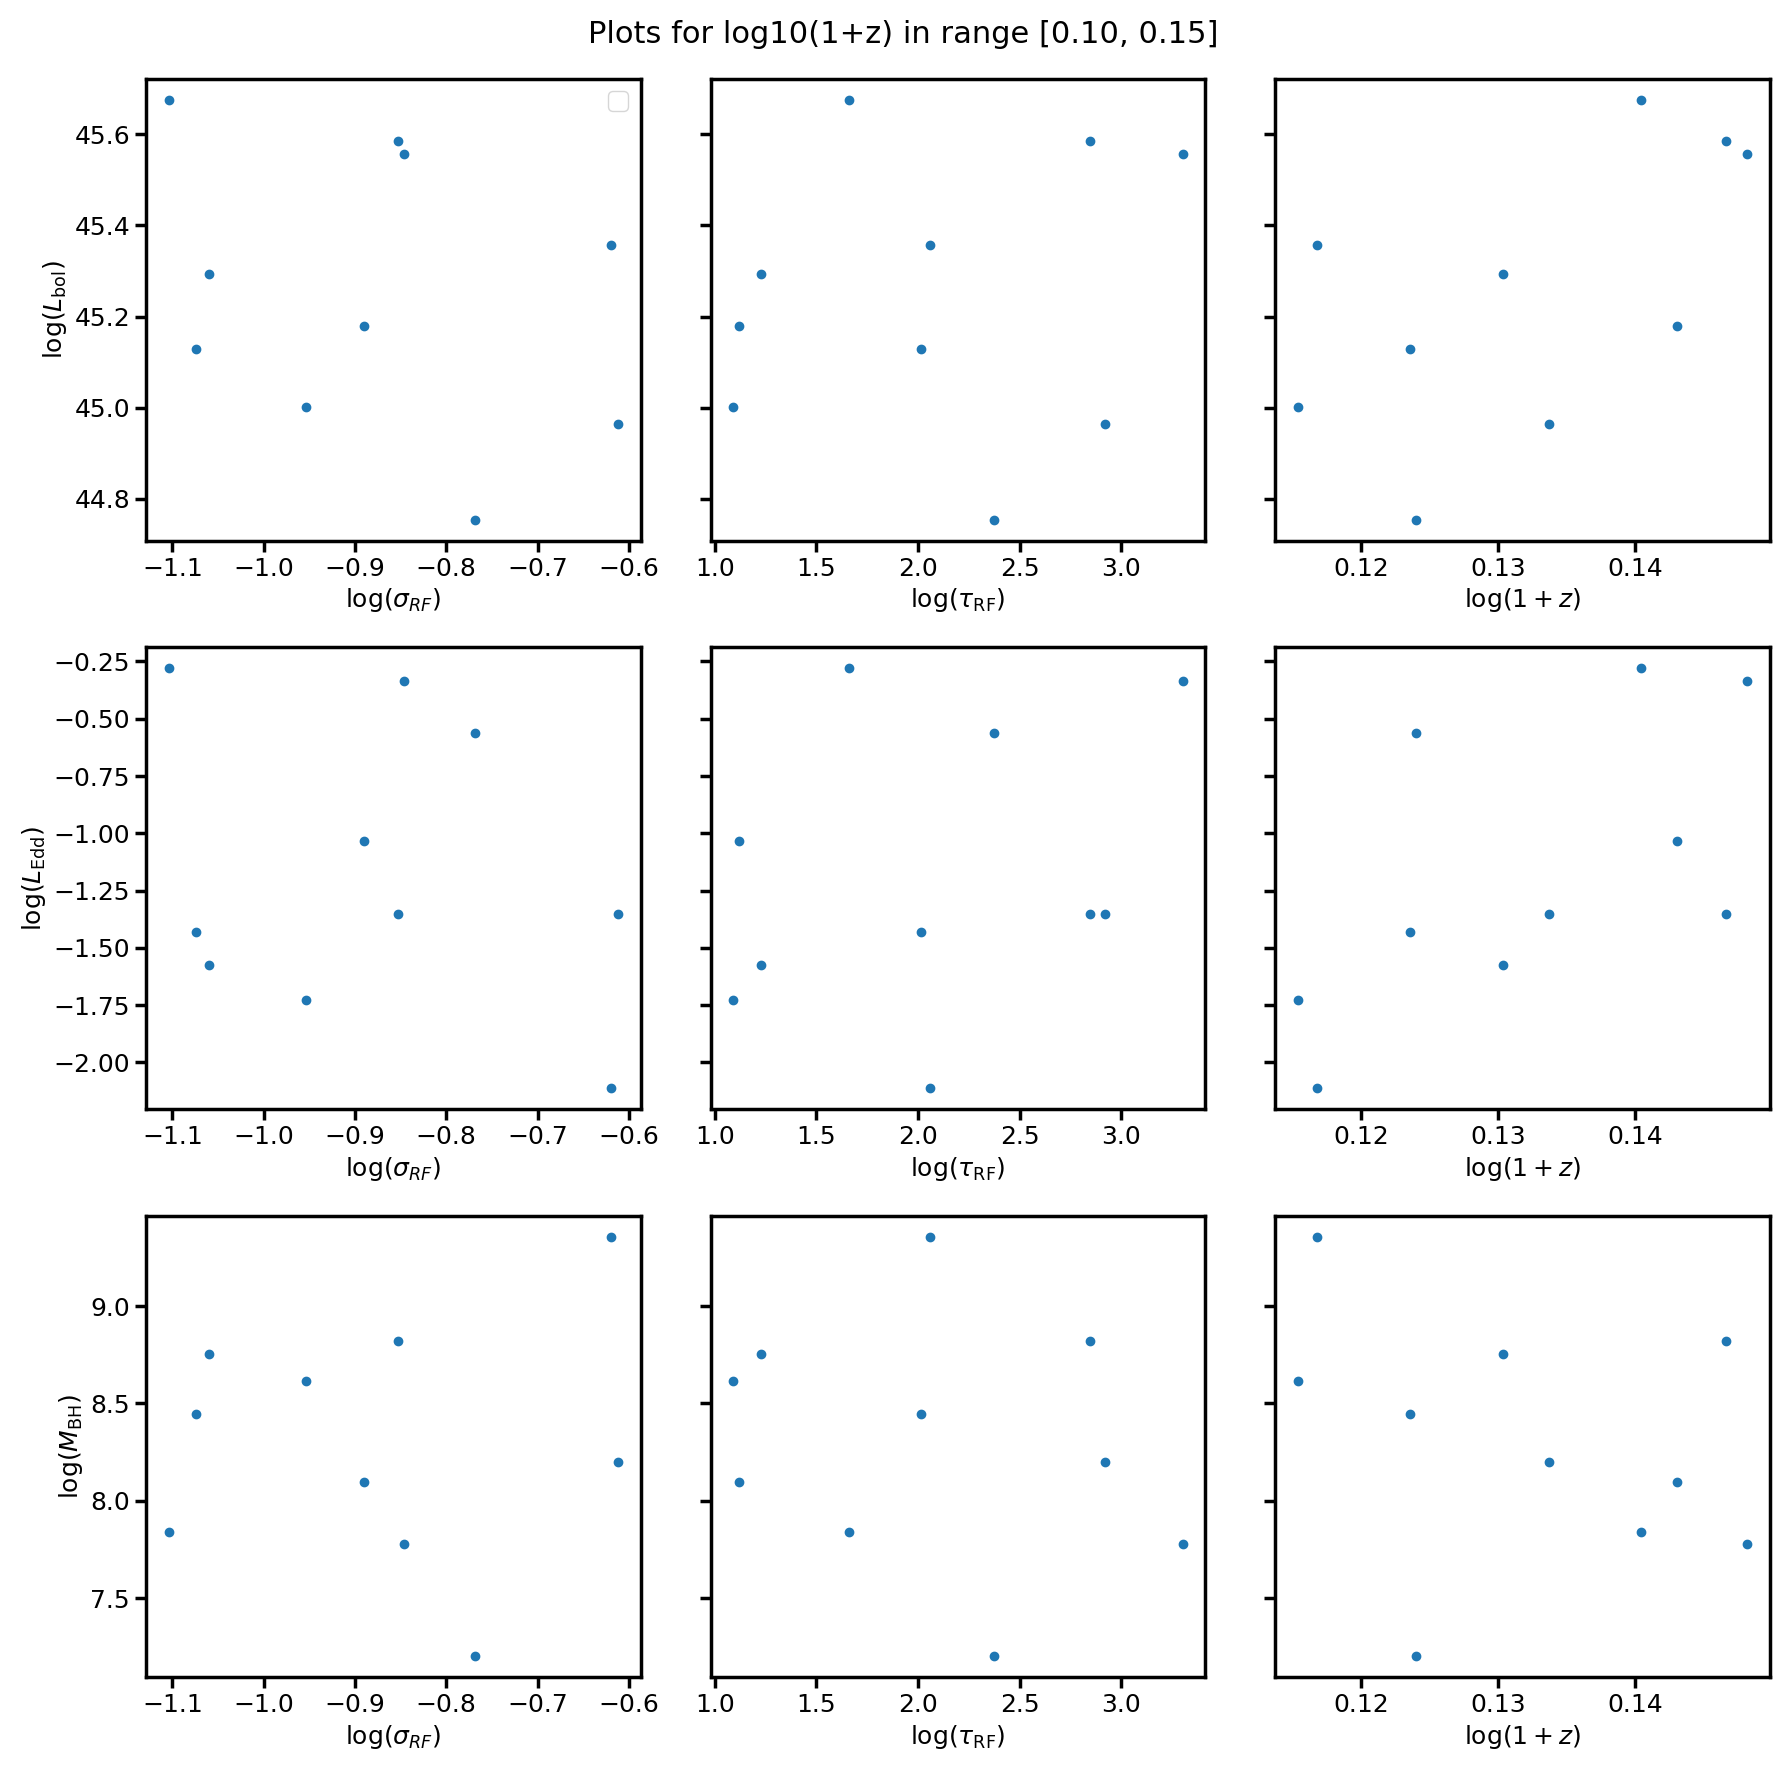

Plotting for range: 0.15 to 0.20


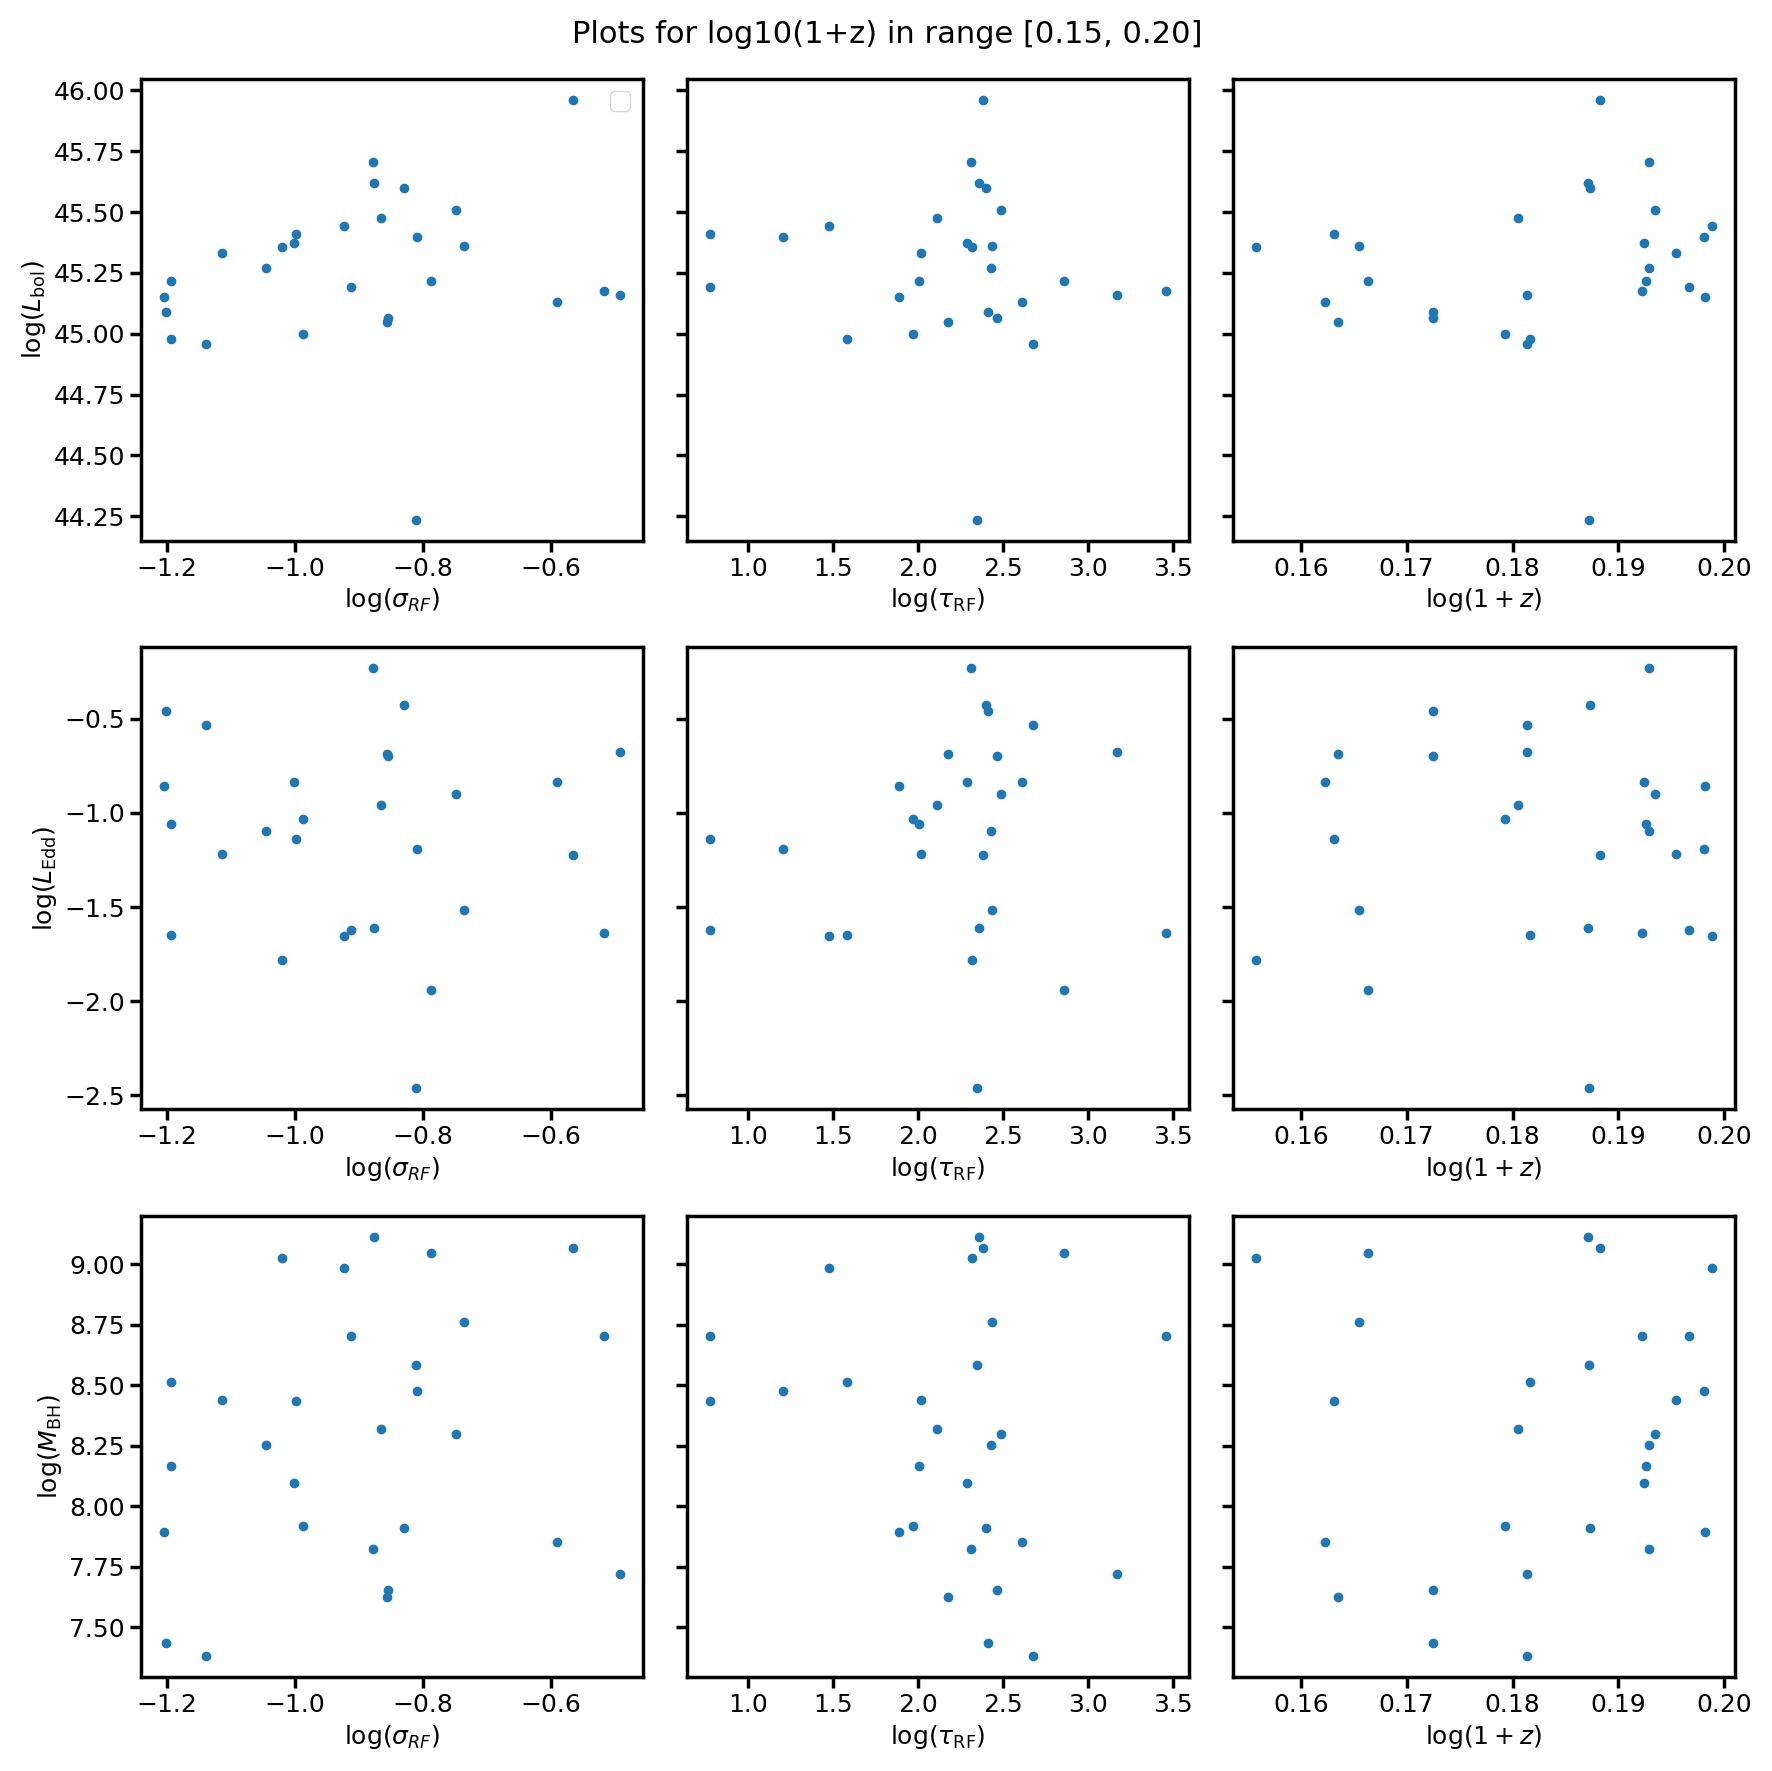

Plotting for range: 0.20 to 0.25


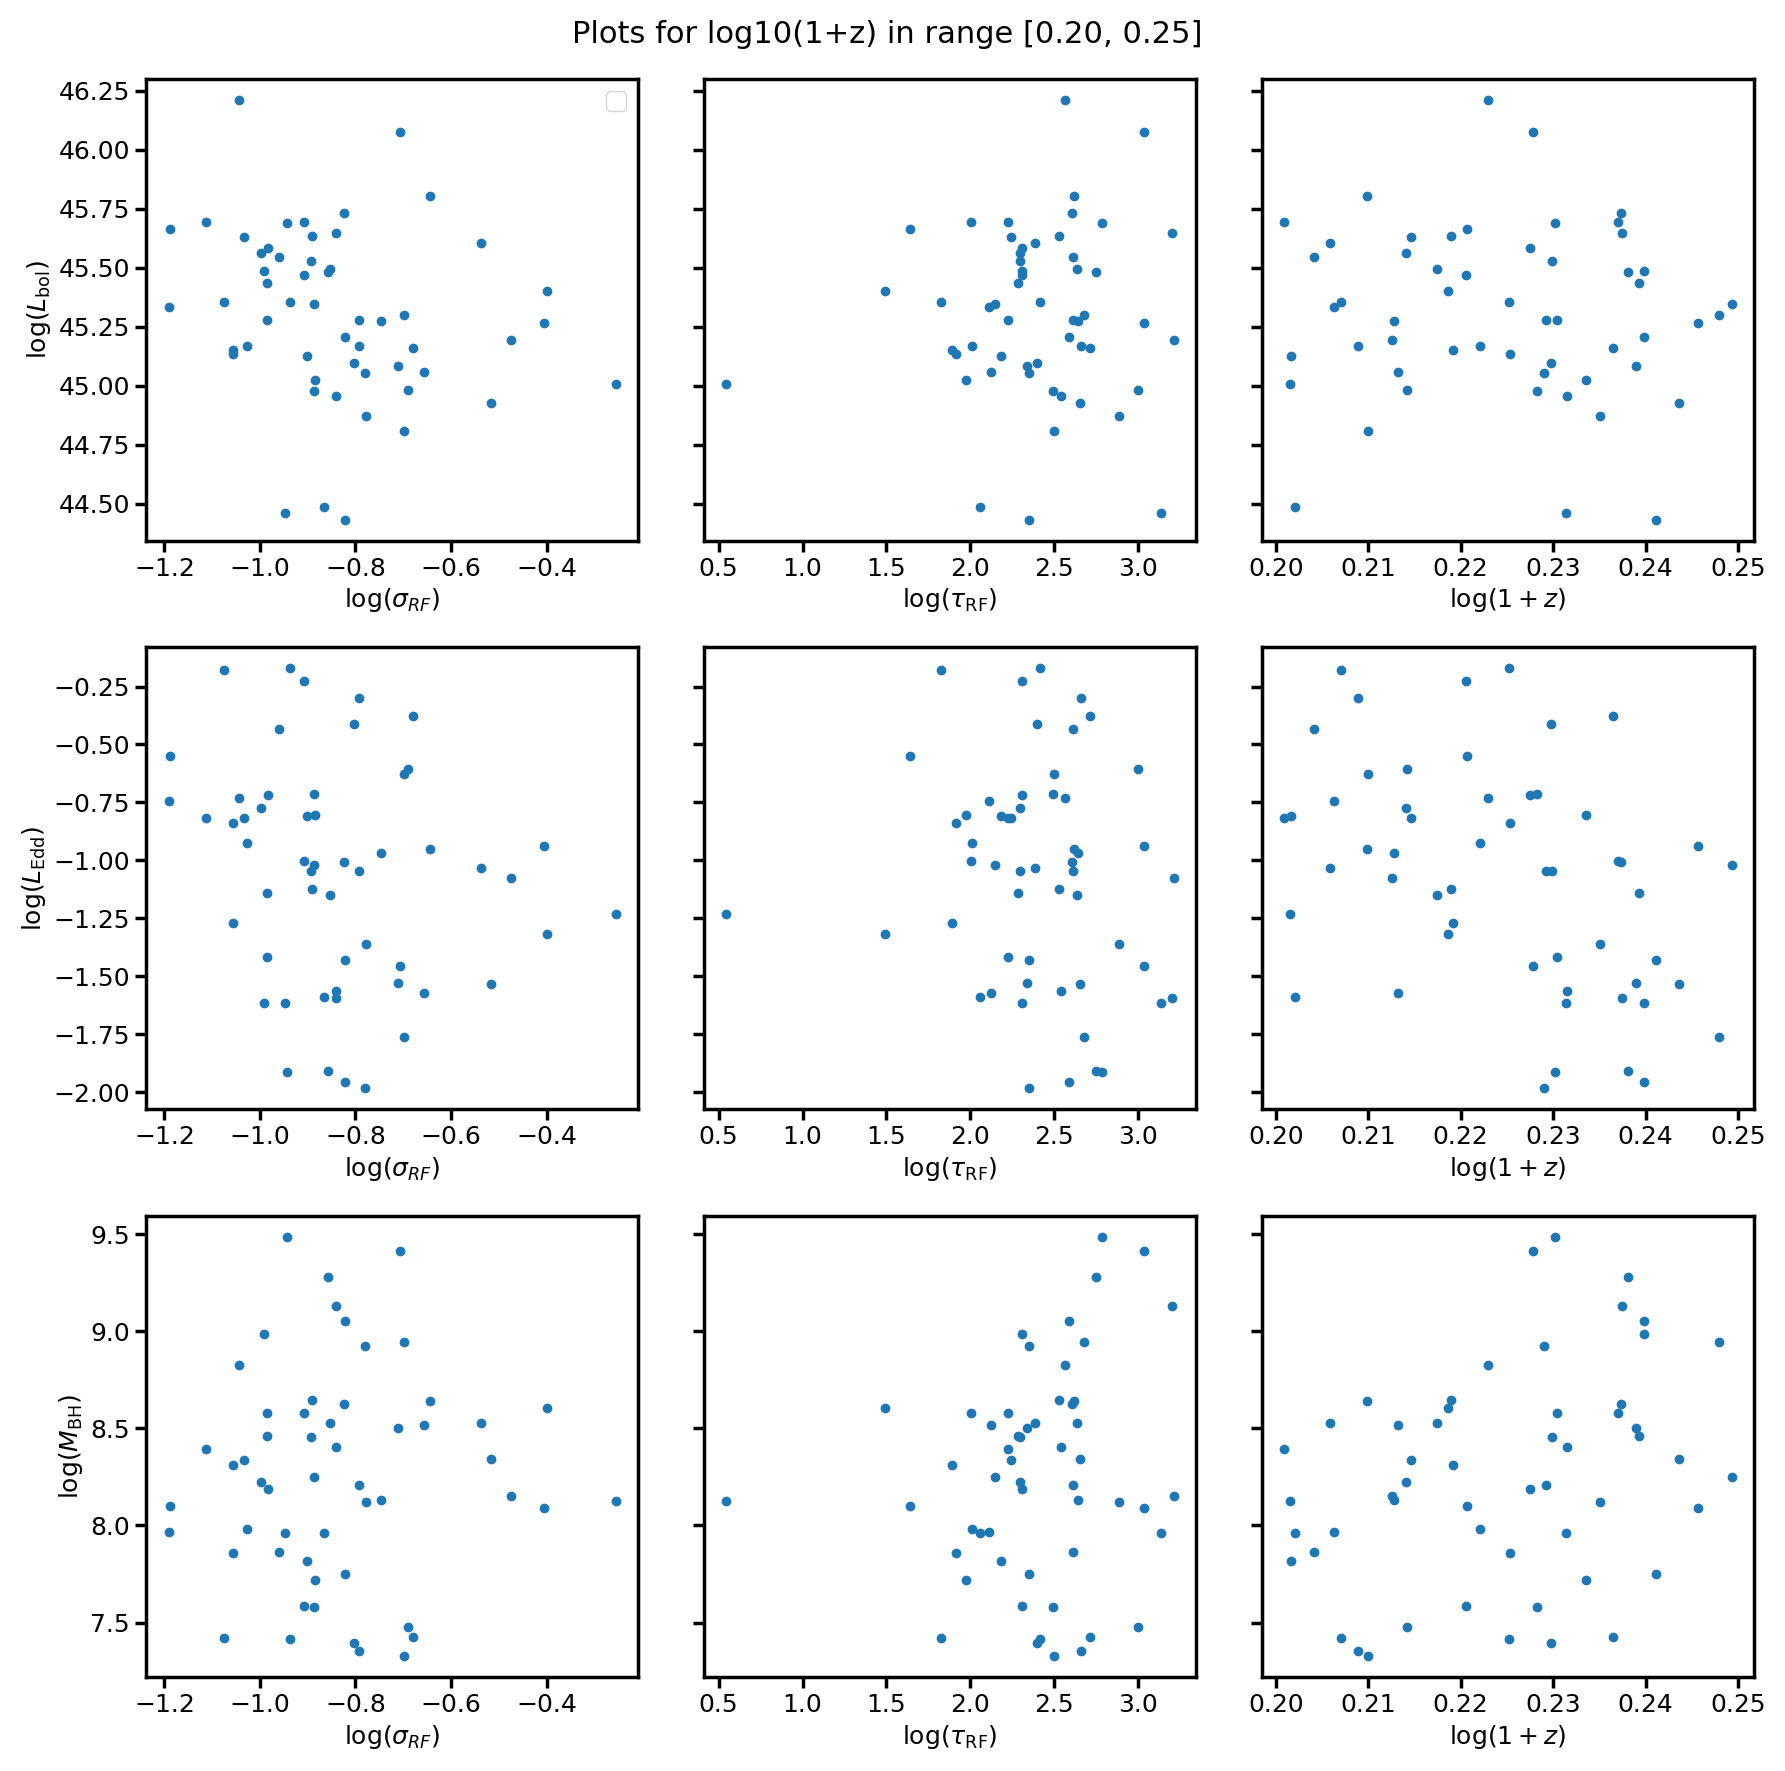

Plotting for range: 0.25 to 0.30


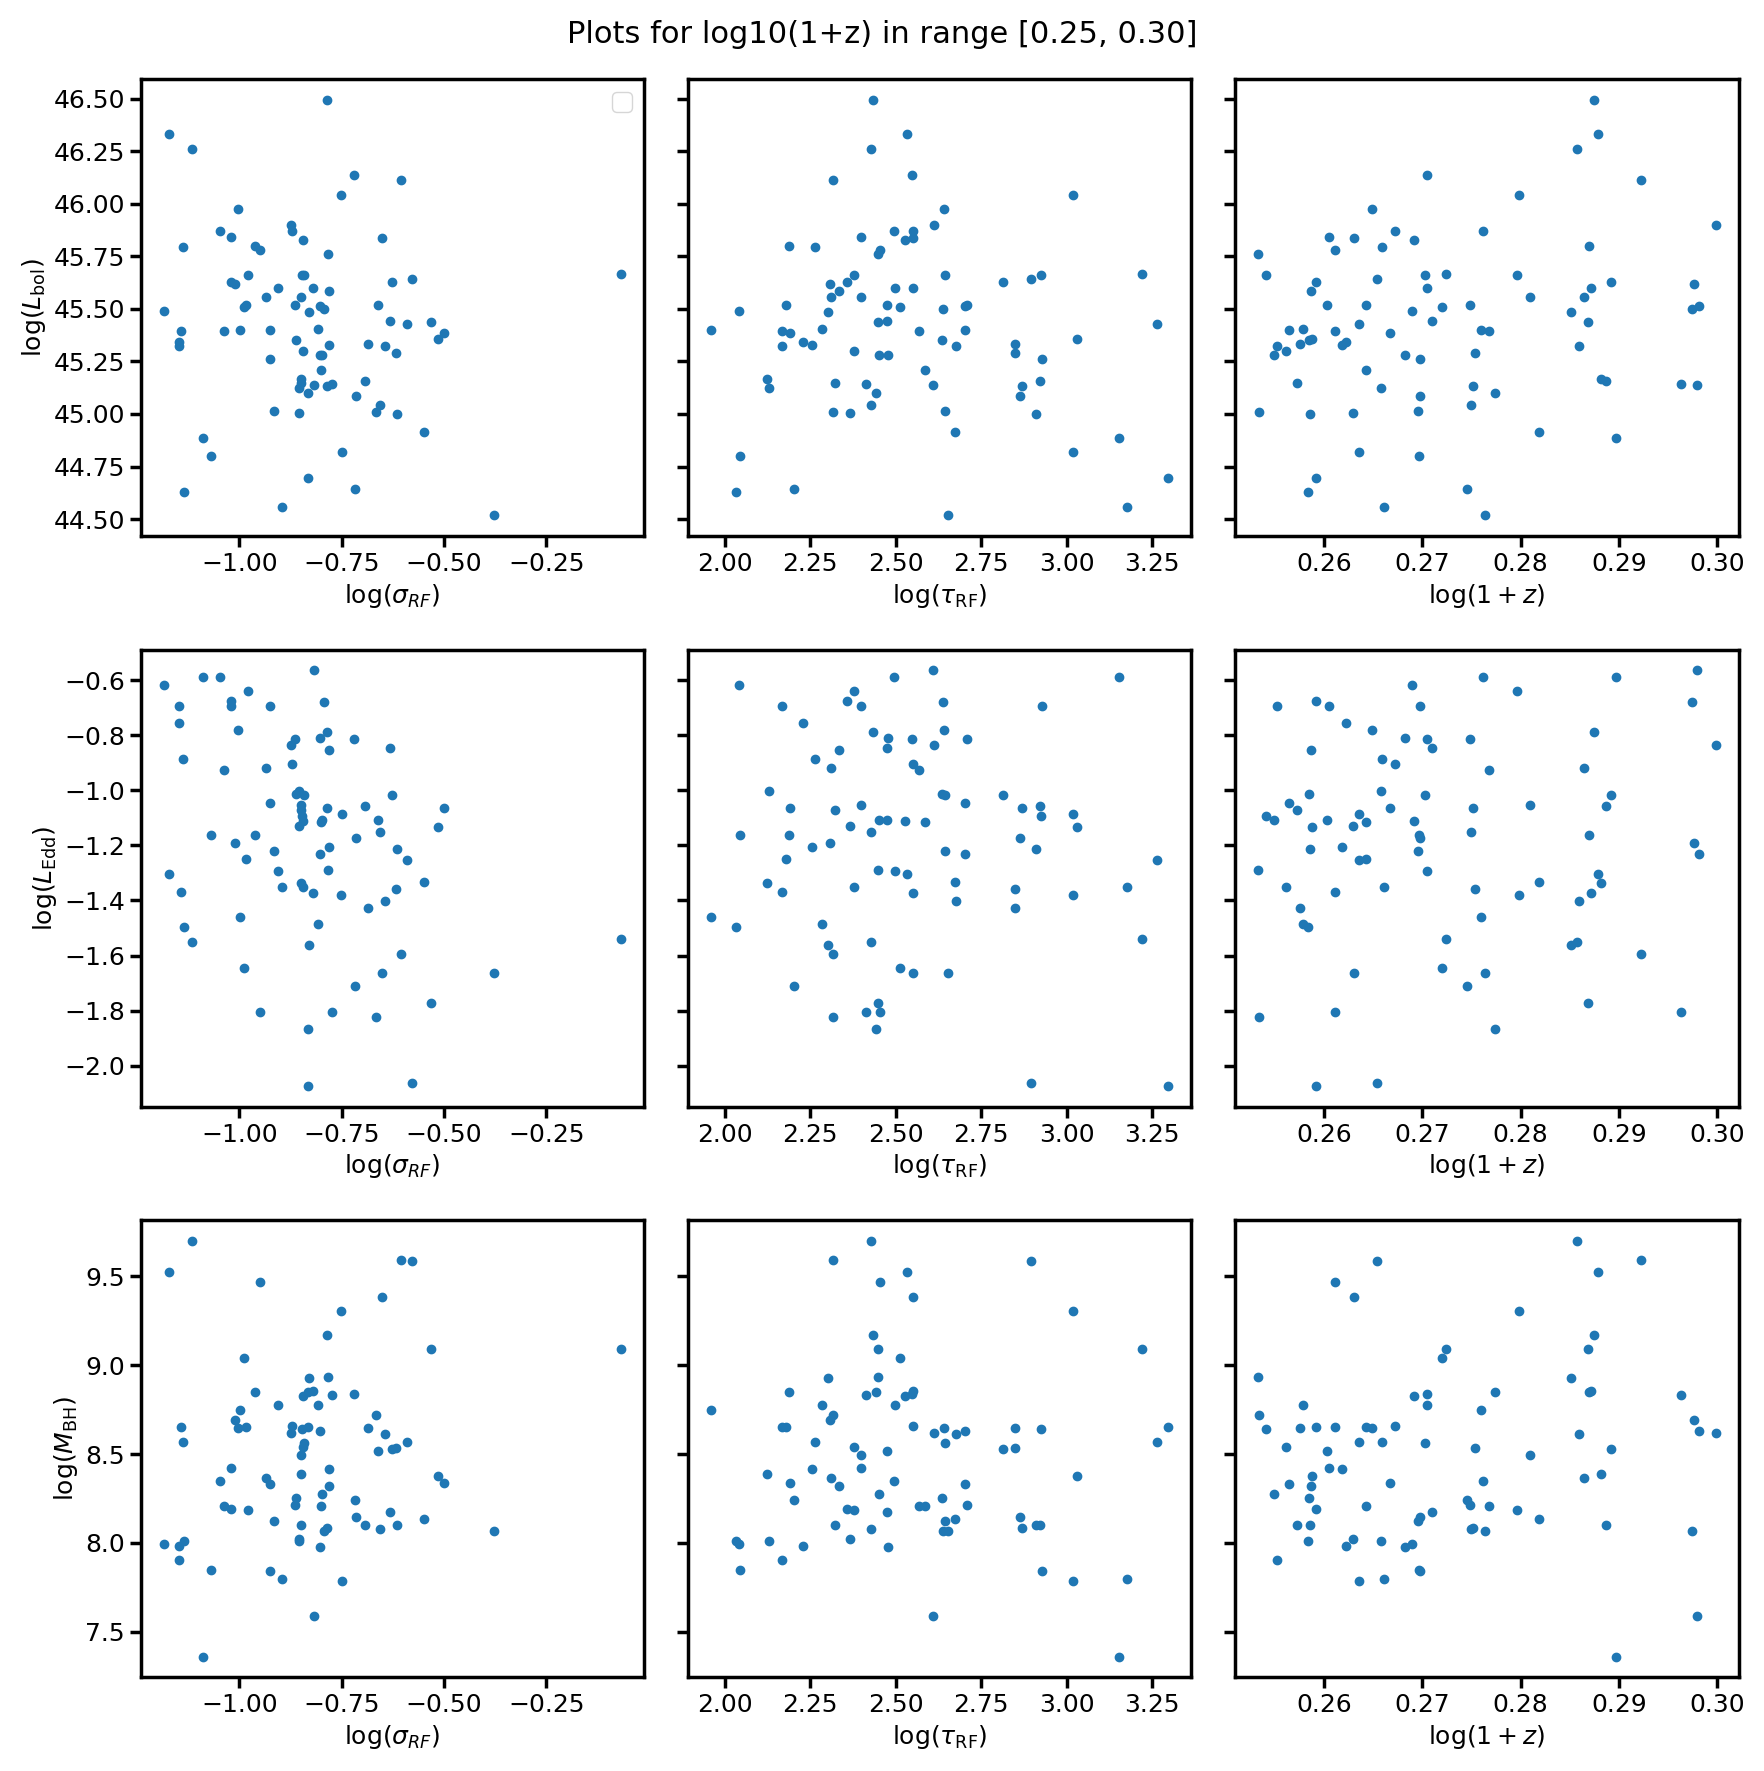

Plotting for range: 0.30 to 0.35


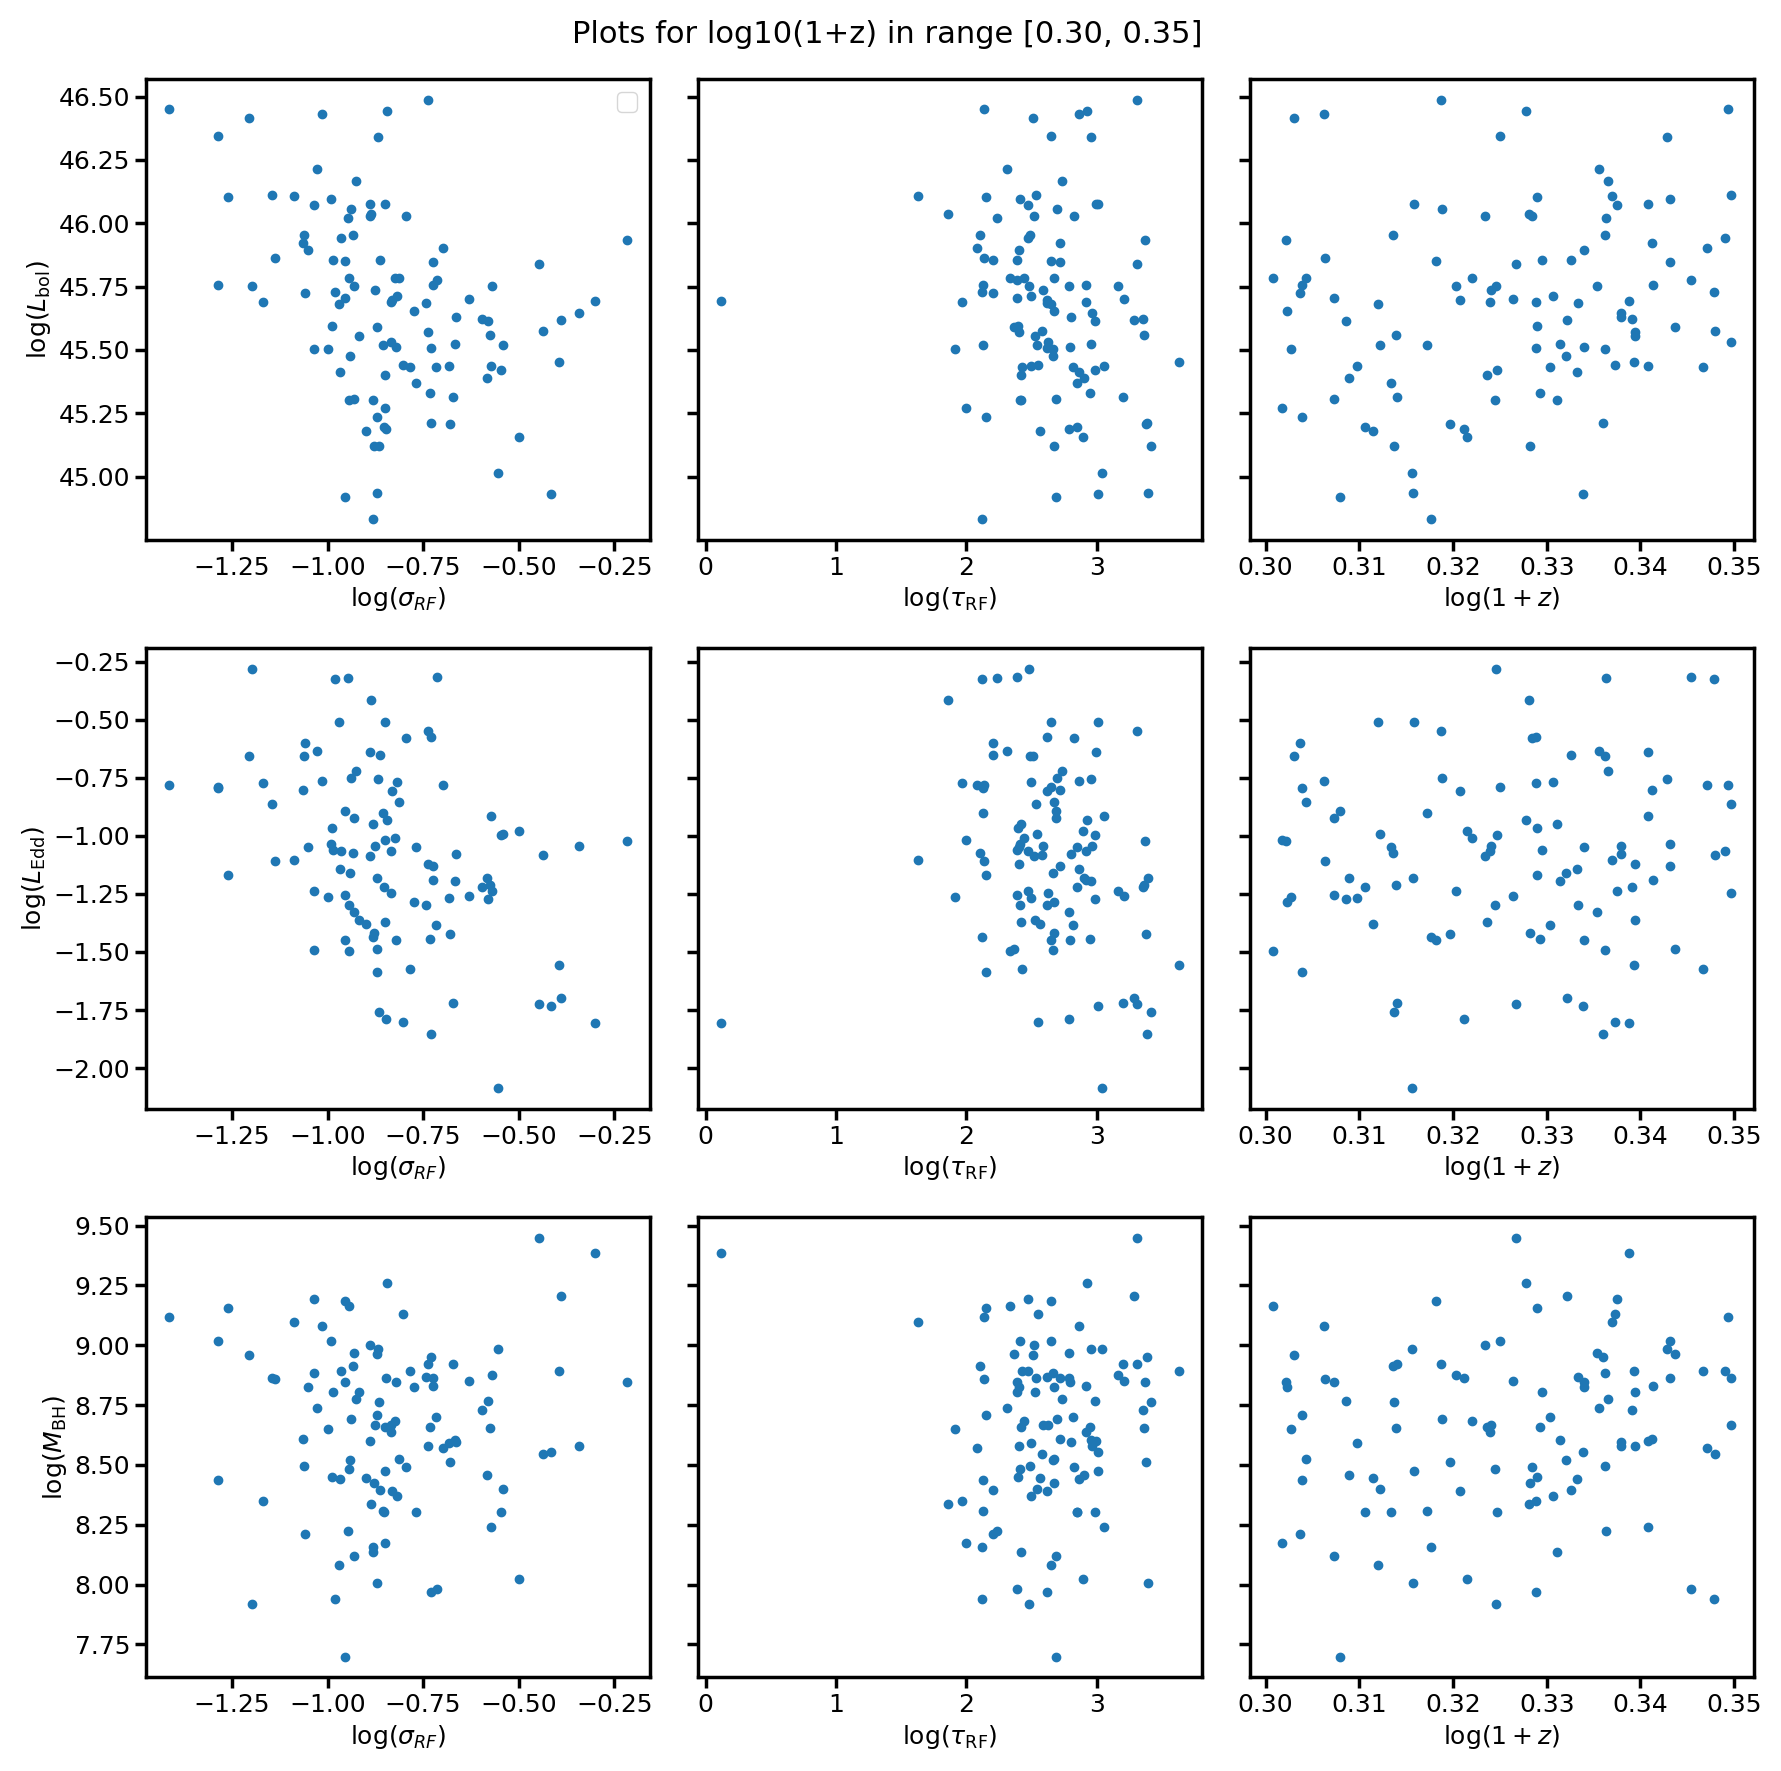

Plotting for range: 0.35 to 0.40


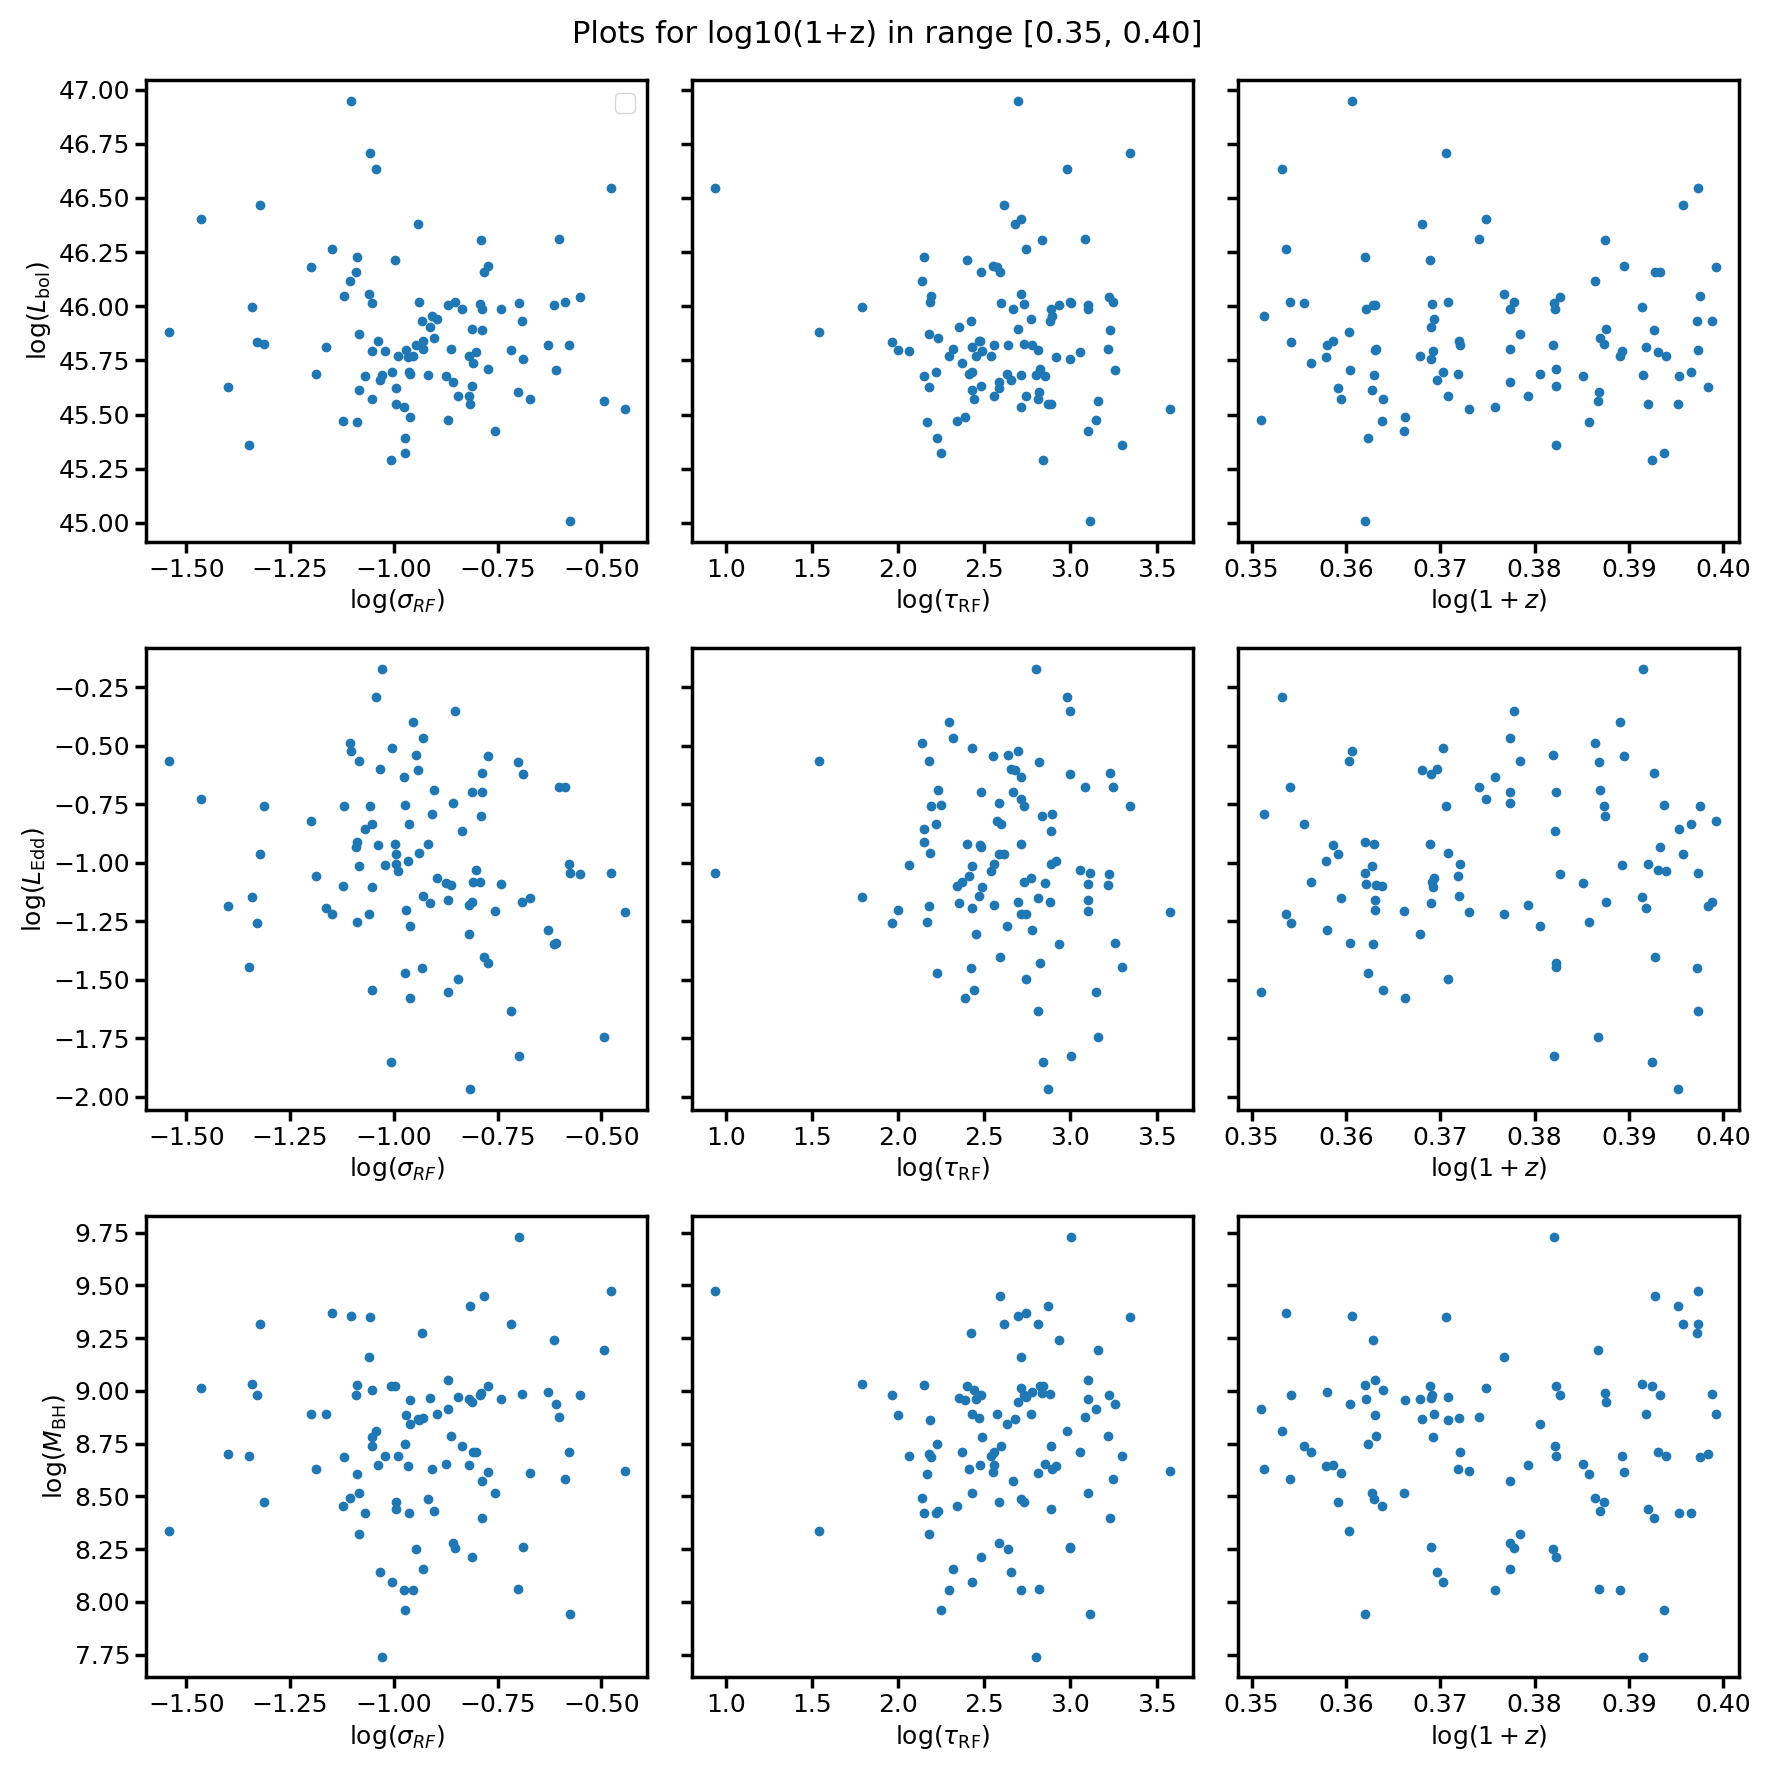

Plotting for range: 0.40 to 0.45


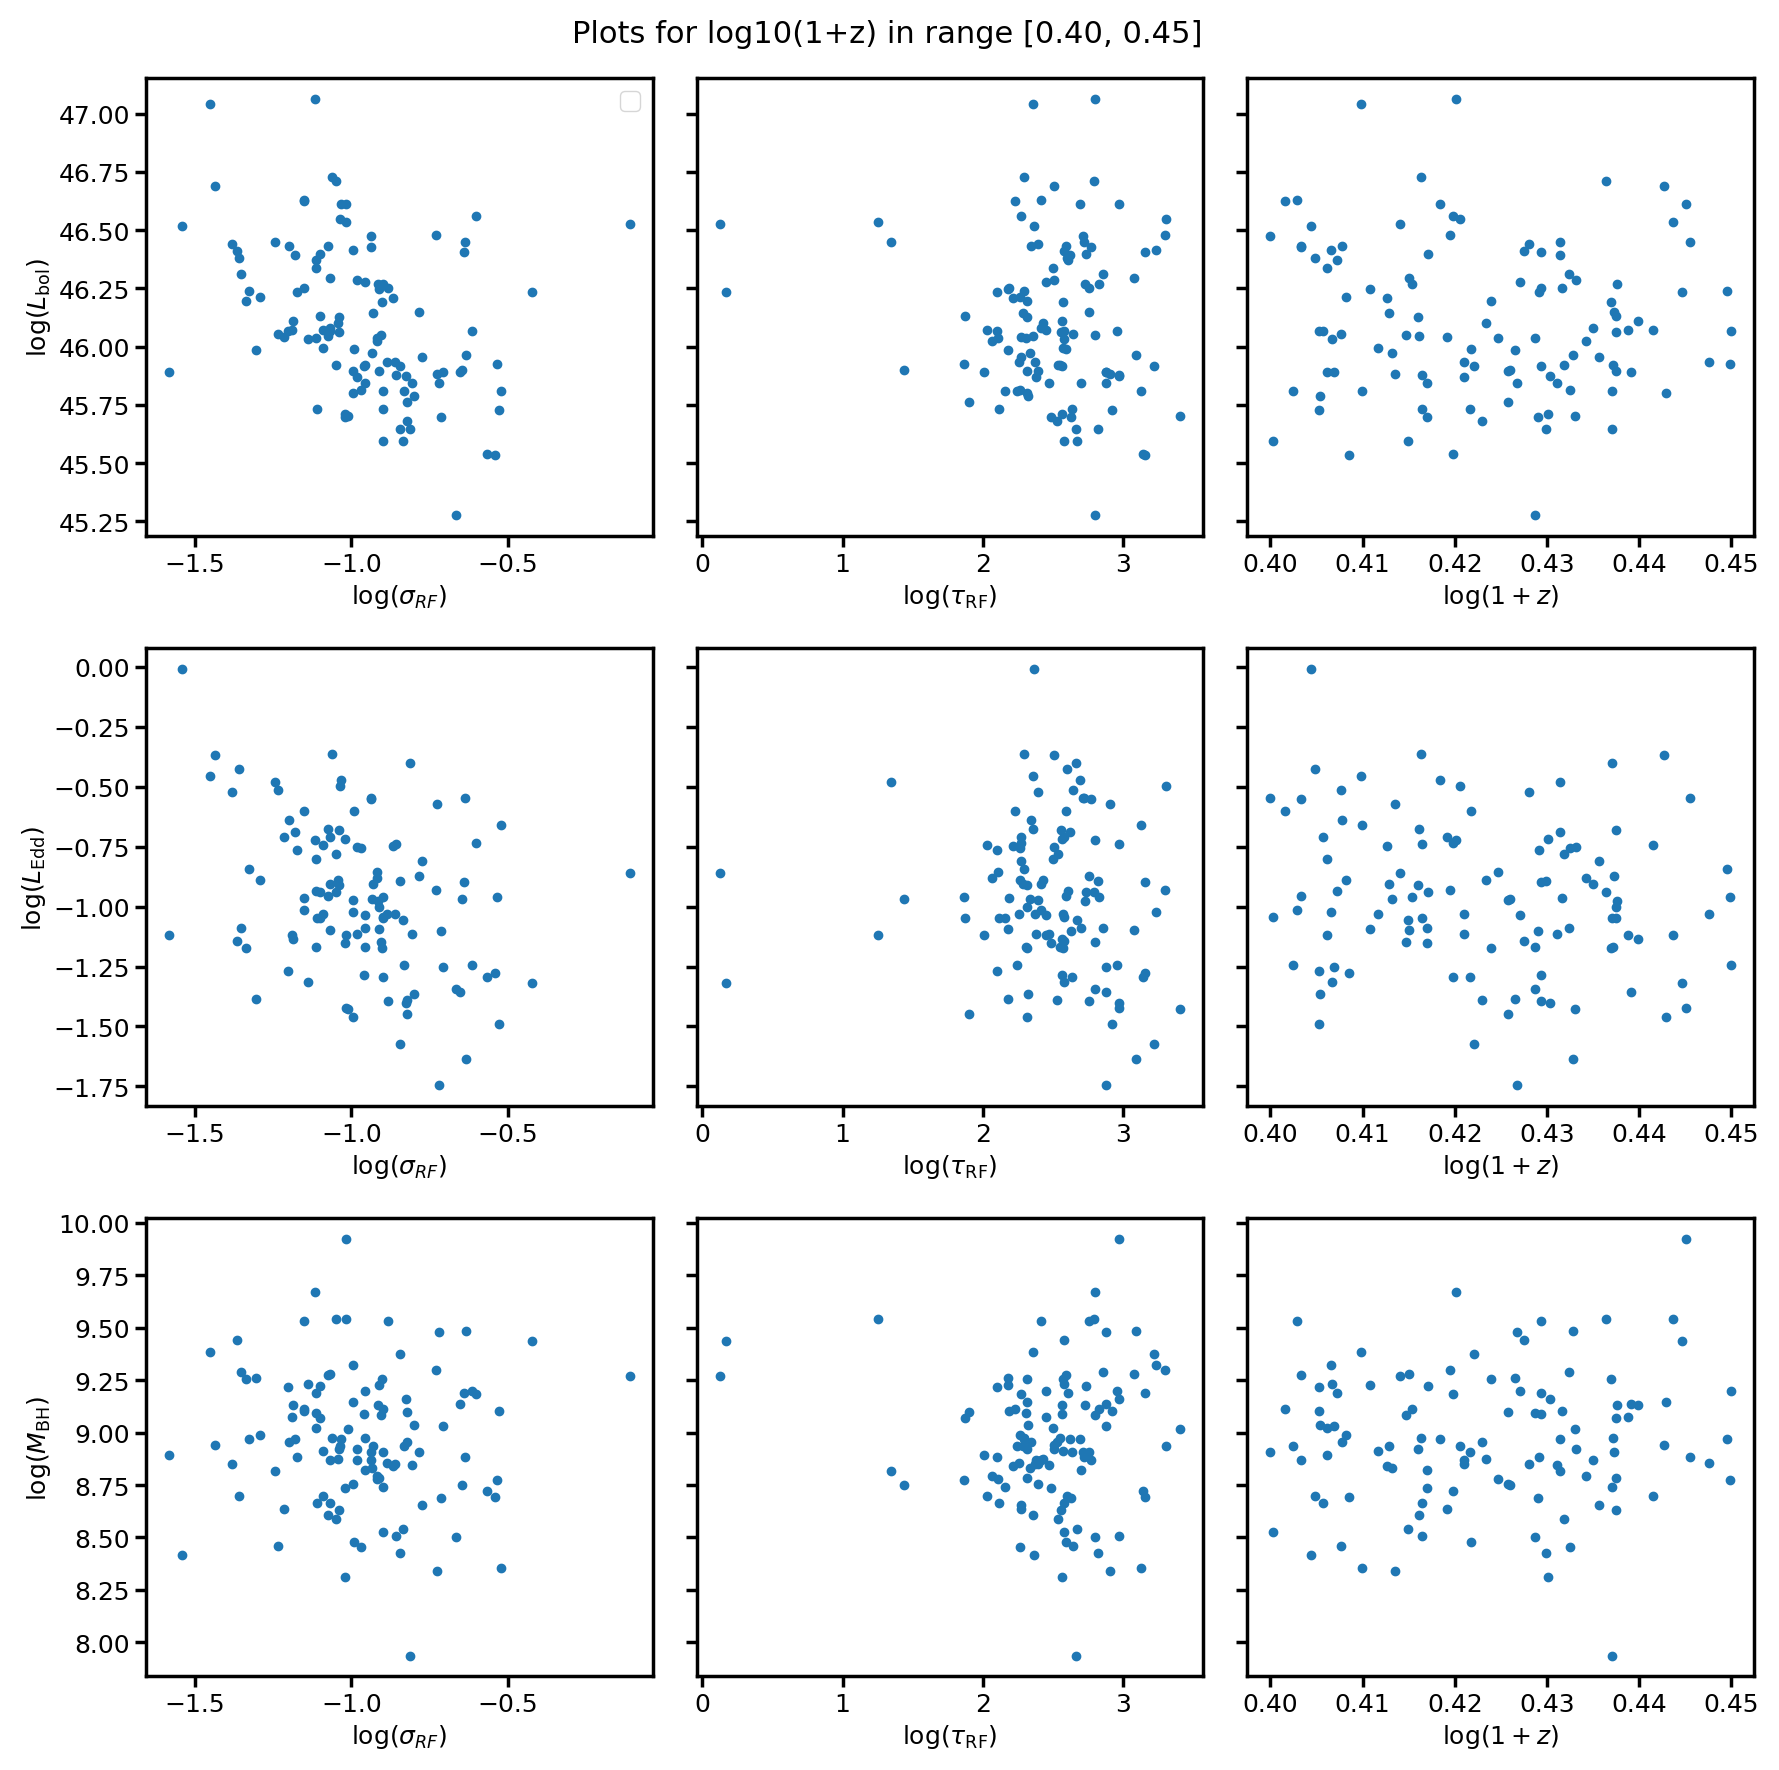

Plotting for range: 0.45 to 0.50


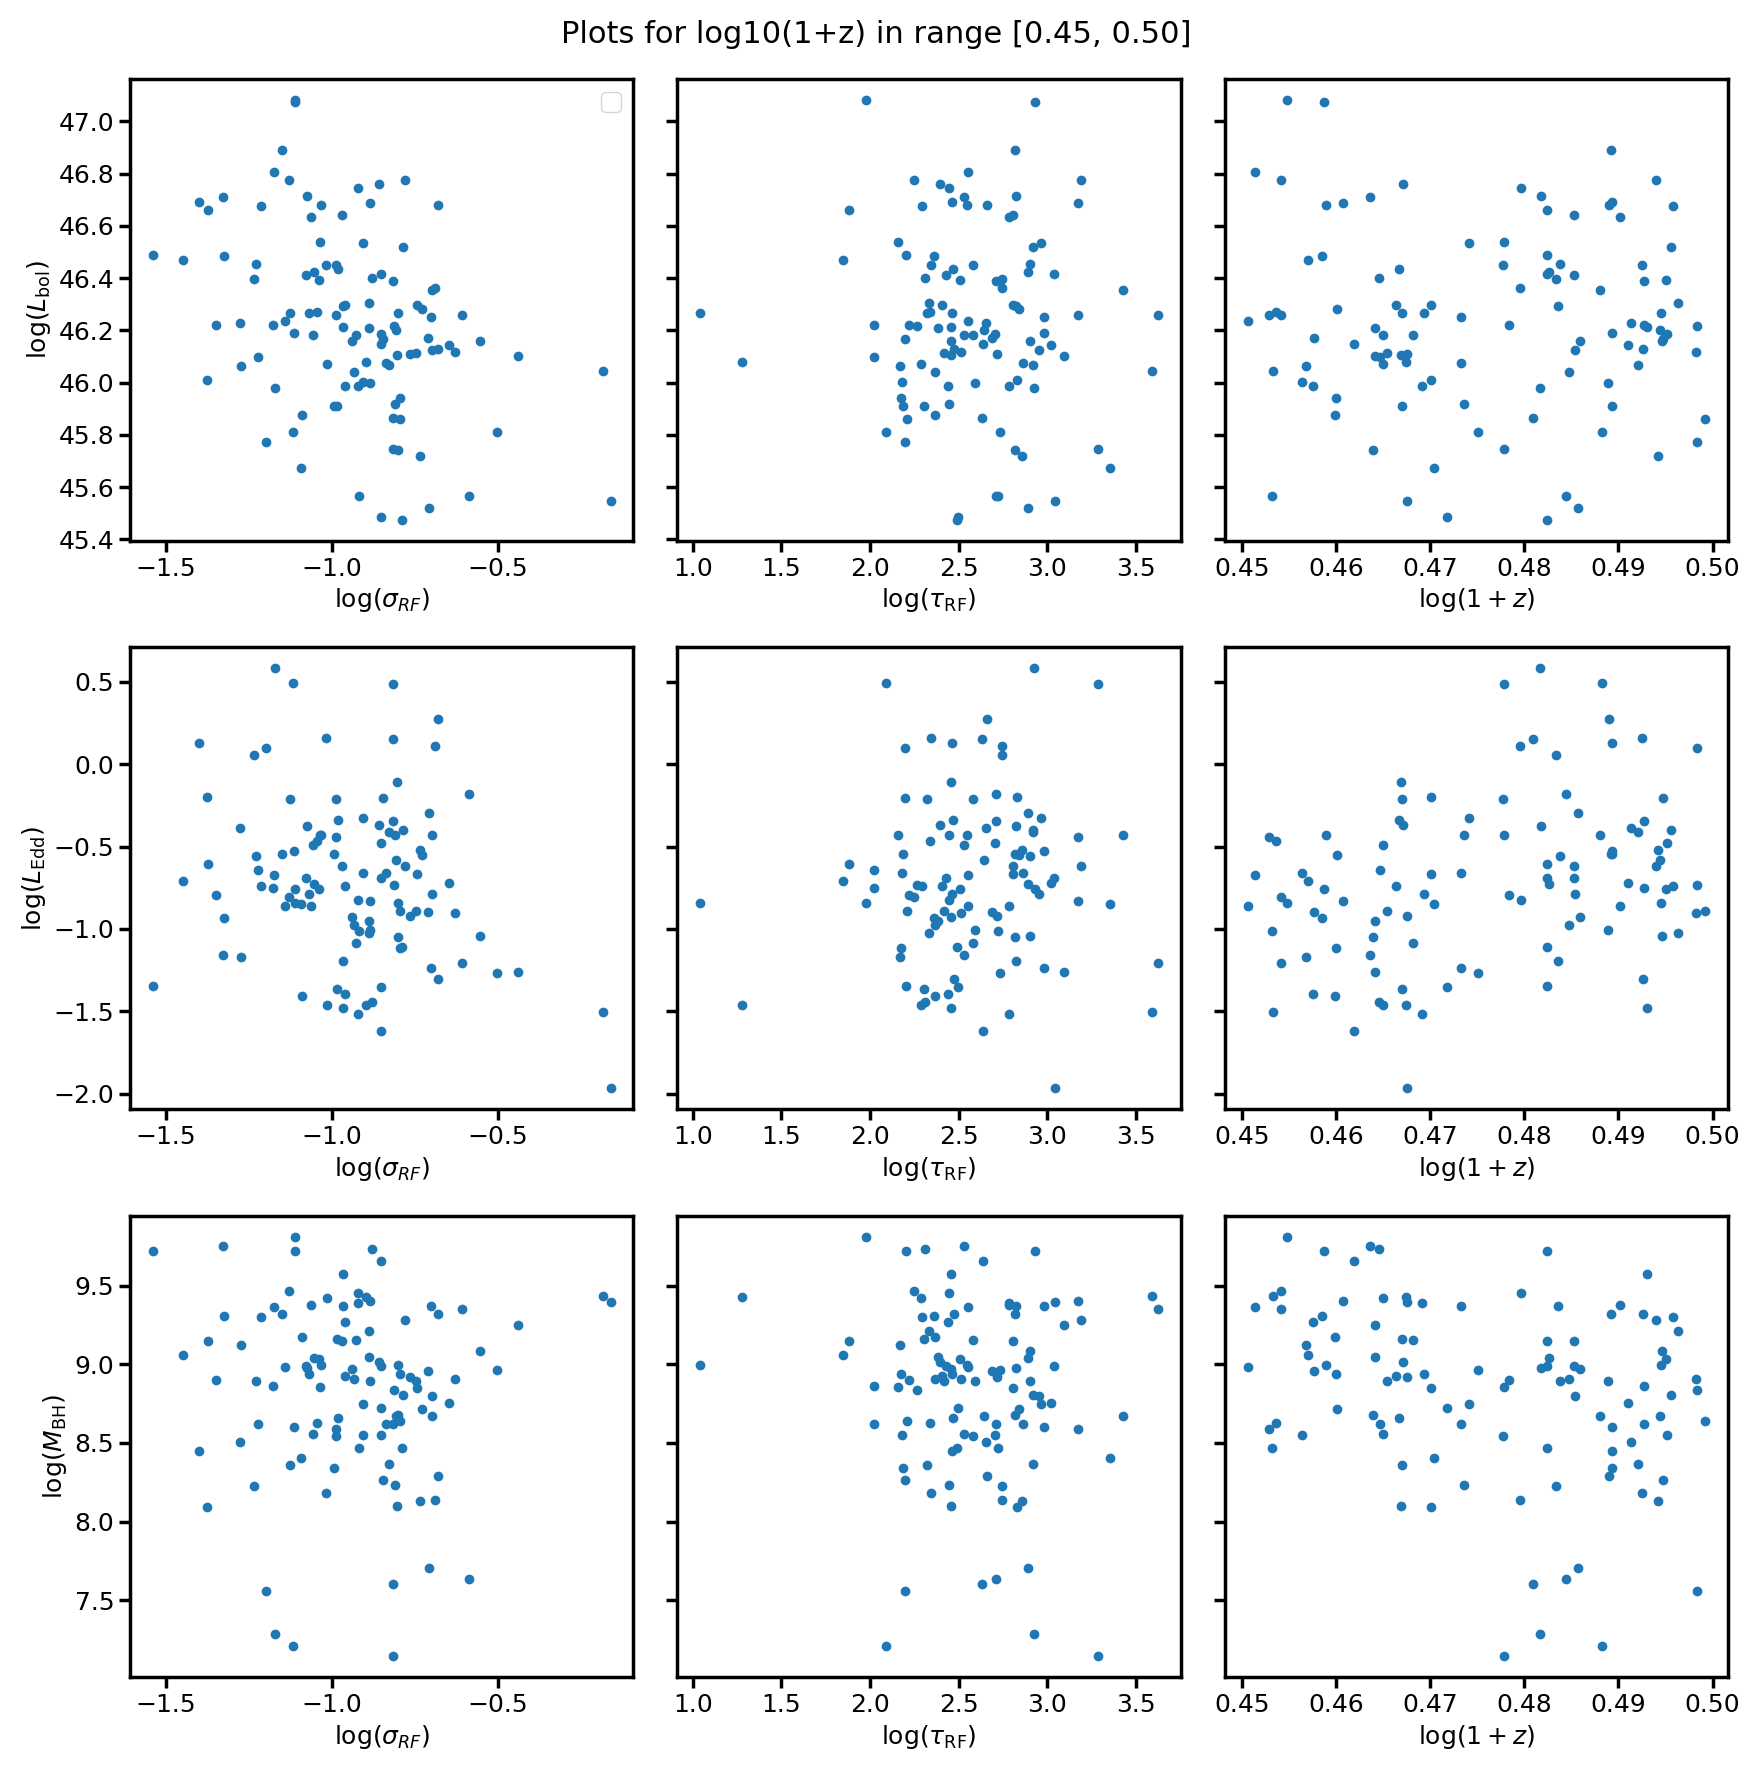

Plotting for range: 0.50 to 0.55


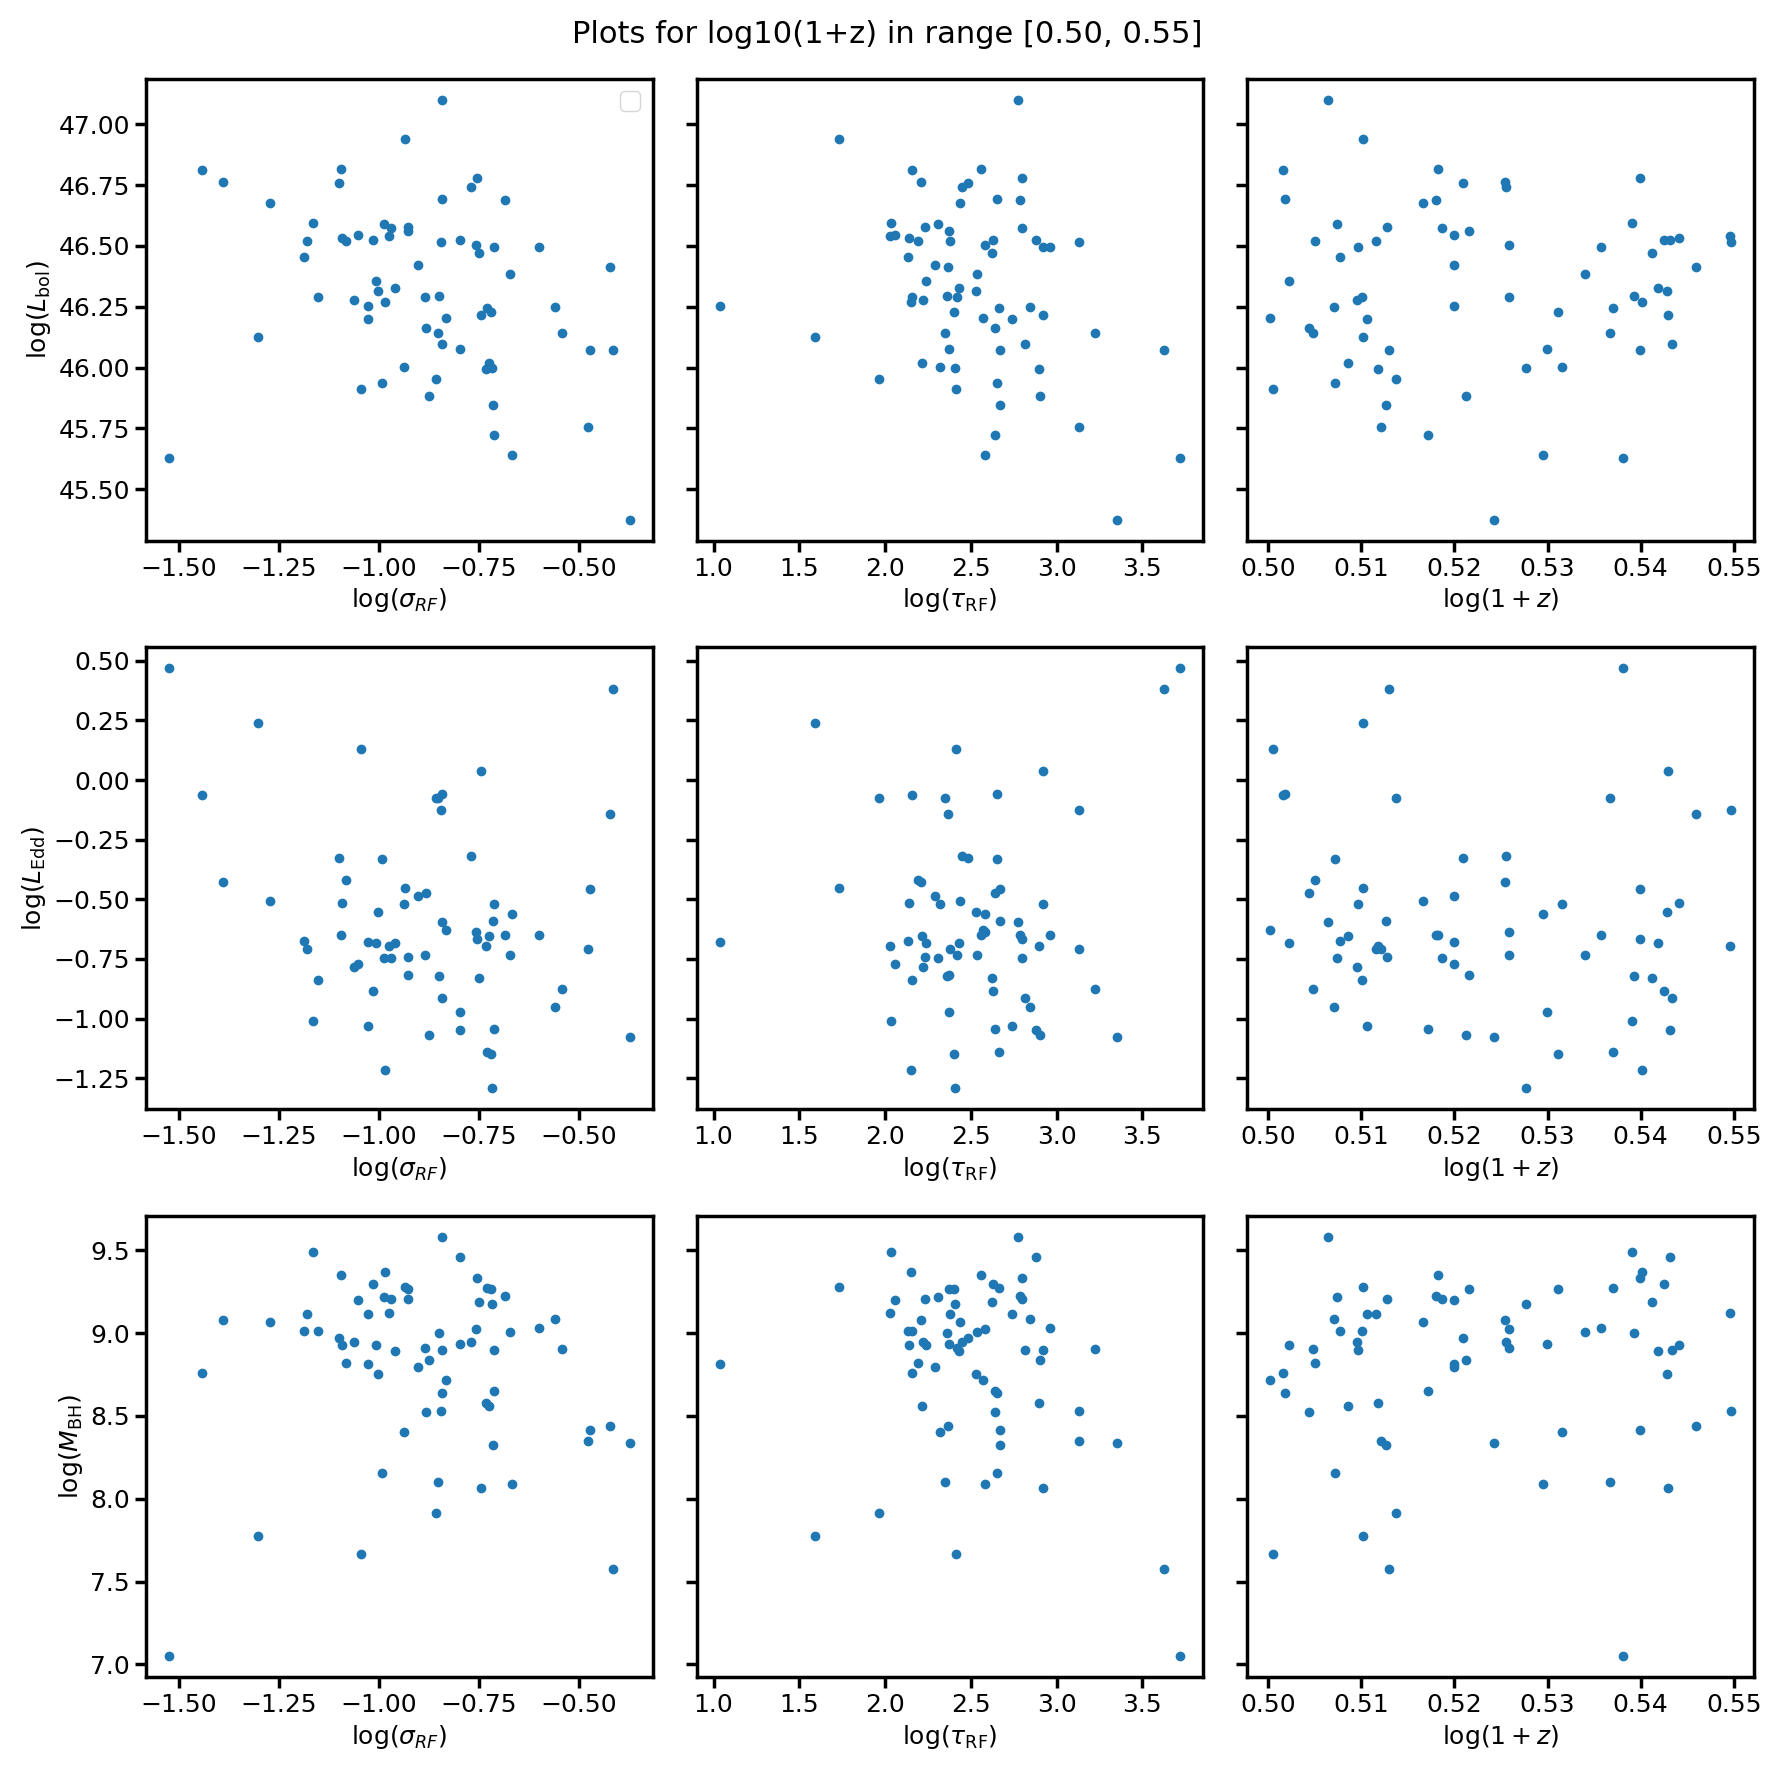

Plotting for range: 0.55 to 0.60


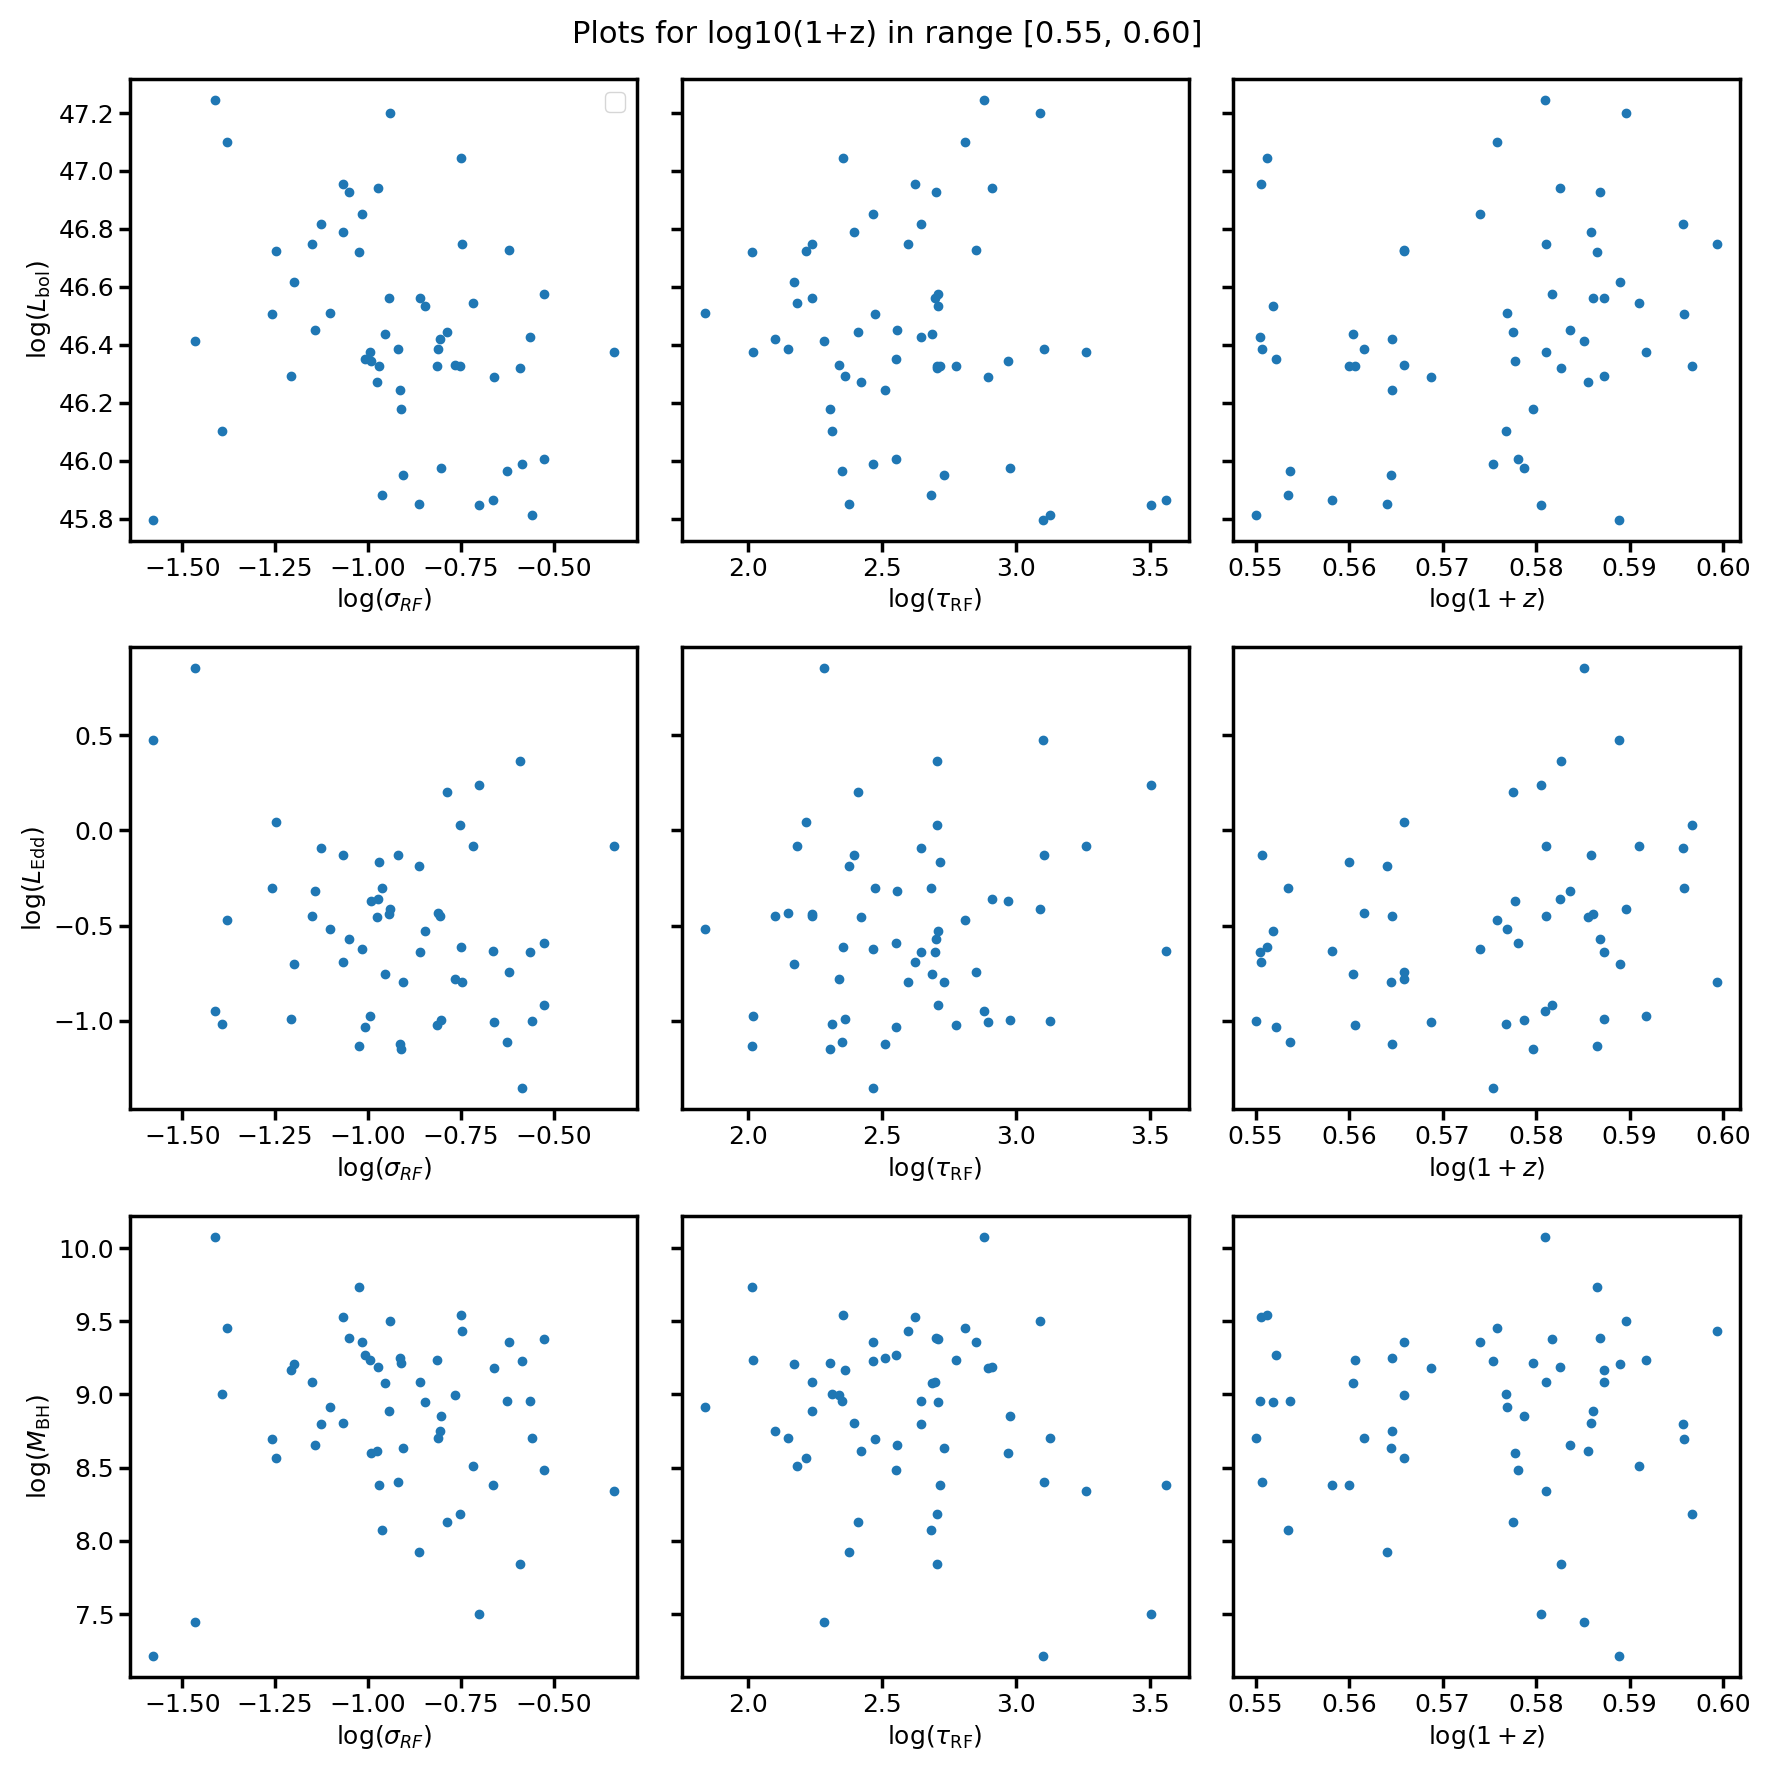

Plotting for range: 0.60 to 0.65


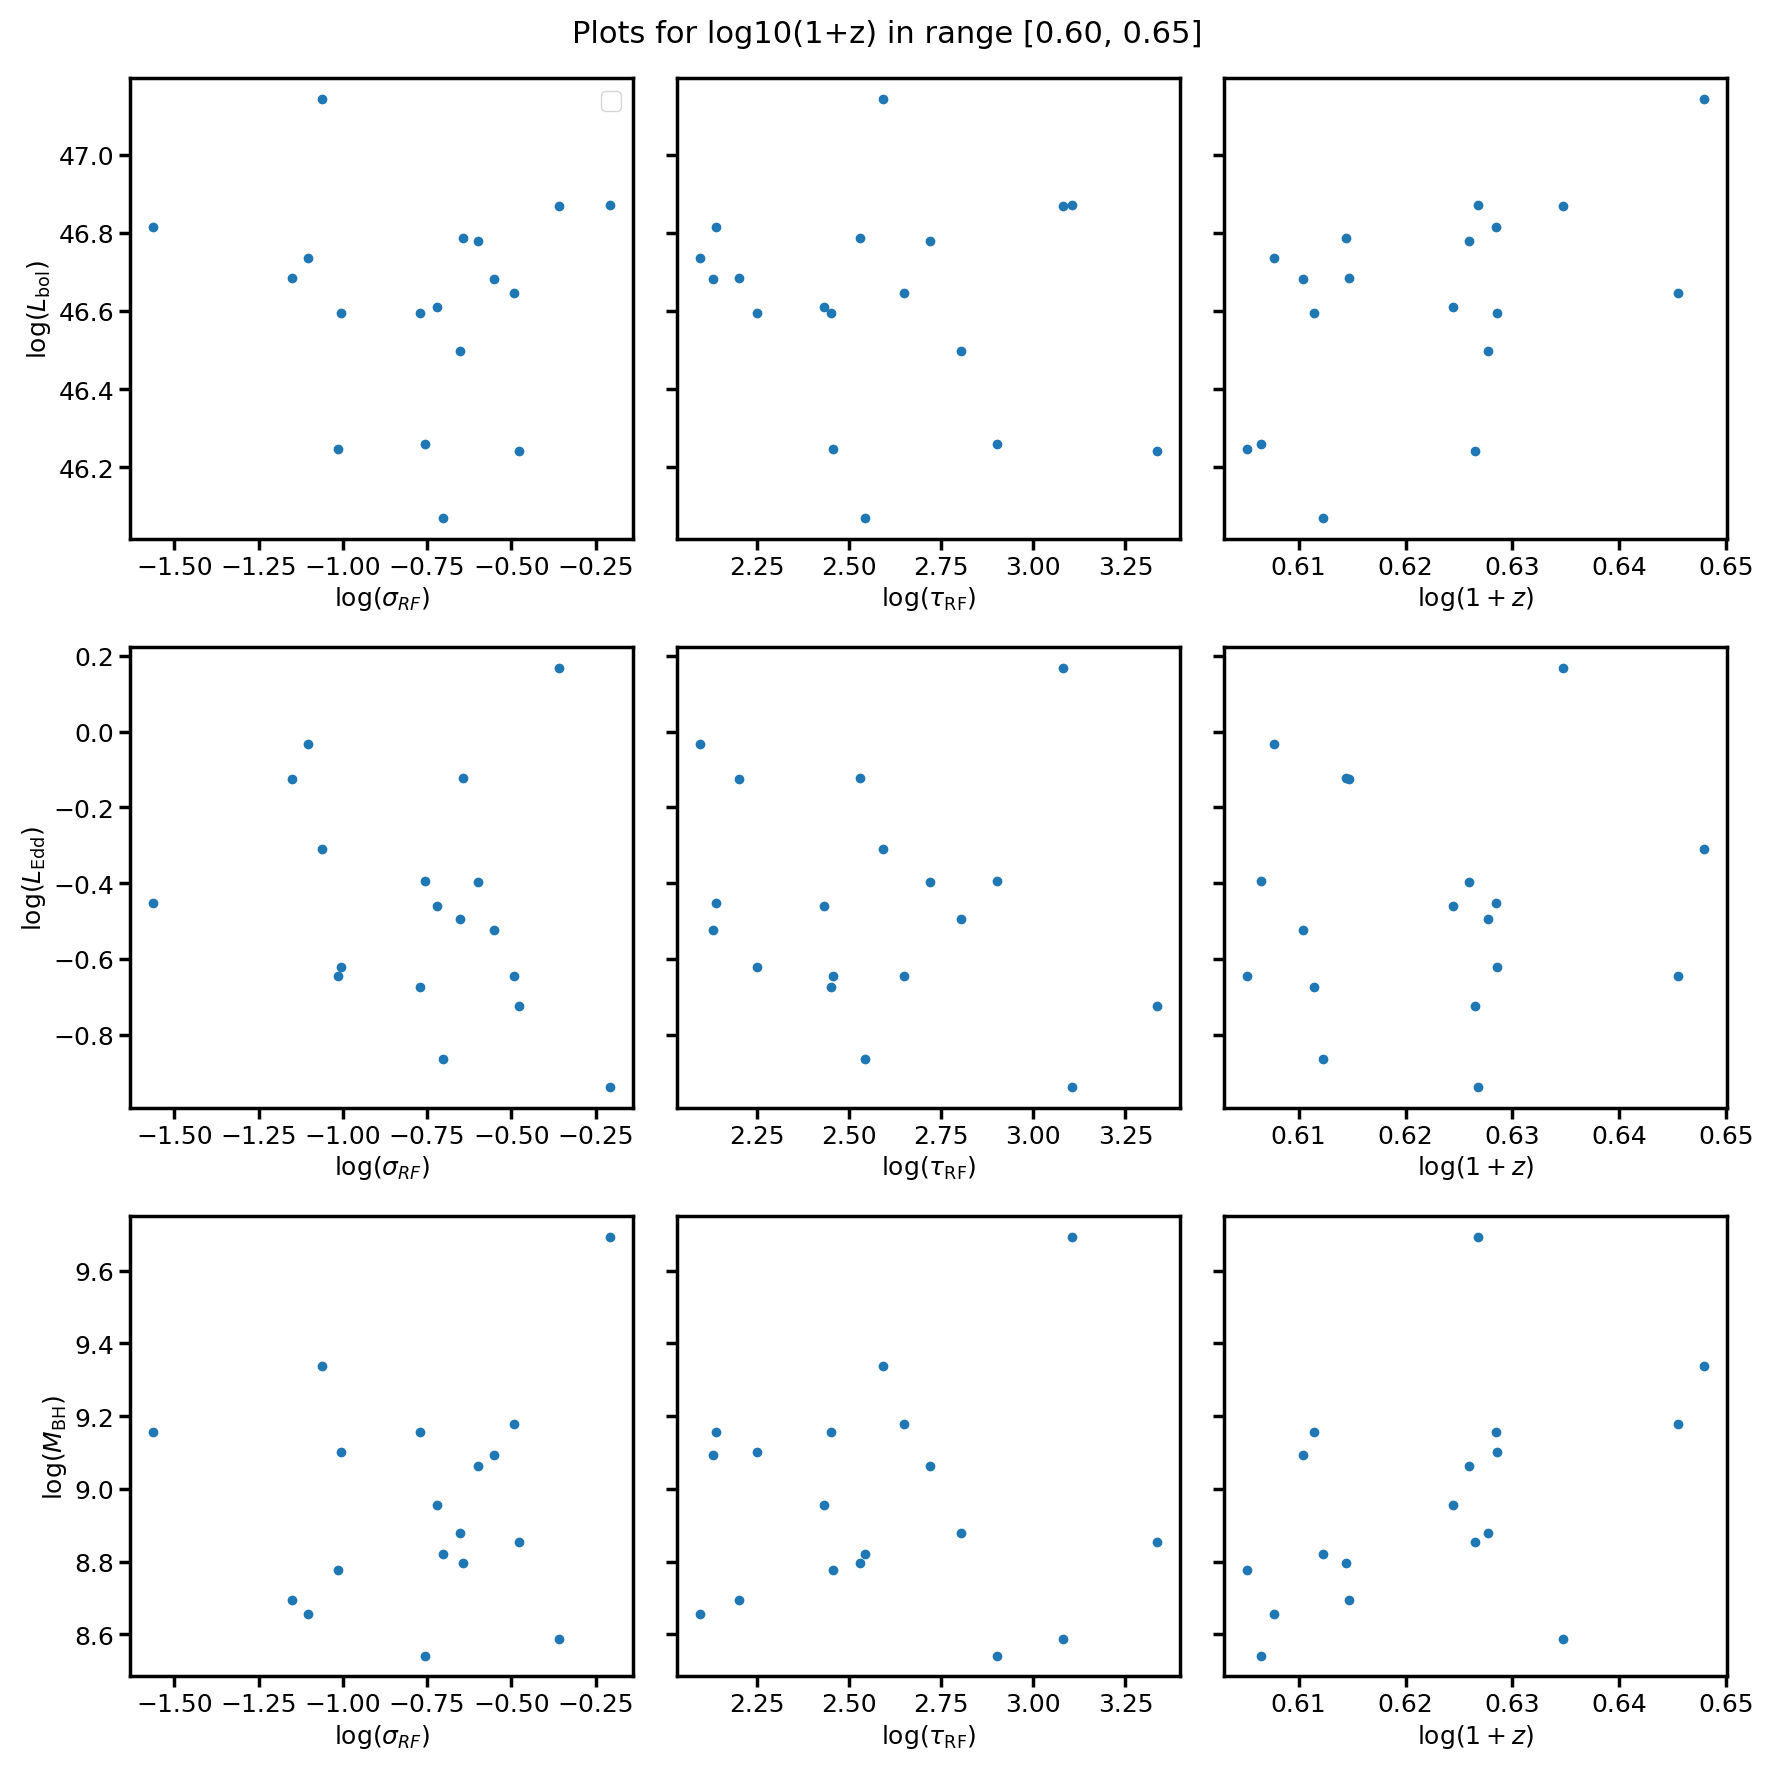

In [ ]:
def plot_selected_range(log10_z_range):
    # Filter the dataframe based on the provided range of np.log10(1+z)
    filtered_df = df[(np.log10(1 + df['z']) >= log10_z_range[0]) & (np.log10(1 + df['z']) <= log10_z_range[1])]
    
    fig, axs = plt.subplots(3, 3, figsize=(3*6, 3*6), sharey='row')
    # Add the bin range to the title
    fig.suptitle(f"Plots for log10(1+z) in range [{log10_z_range[0]:.2f}, {log10_z_range[1]:.2f}]")
    # First row
    ax = axs[0, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(L_\mathrm{bol})$")
    ax.legend()

    ax = axs[0, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[0, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_lbol'])
    ax.set_xlabel(r"$\log(1+z)$")

    # Second row
    ax = axs[1, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(L_\mathrm{Edd})$")

    ax = axs[1, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[1, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_ledd_ratio'])
    ax.set_xlabel(r"$\log(1+z)$")

    # Third row
    ax = axs[2, 0]
    ax.scatter(filtered_df['log_sigma_RF'], filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(\sigma_{RF})$")
    ax.set_ylabel(r"$\log(M_\mathrm{BH})$")

    ax = axs[2, 1]
    ax.scatter(filtered_df['log_tau_RF'], filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(\tau_\mathrm{RF})$")

    ax = axs[2, 2]
    ax.scatter(np.log10(1+filtered_df['z']), filtered_df['log_mbh'])
    ax.set_xlabel(r"$\log(1+z)$")

    plt.tight_layout()
    plt.show()
    plt.close()

# Define bins for np.log10(1+z)
bins = np.arange(0, np.log10(1 + df['z'].max()), 0.05)


# Call plot_selected_range for each bin
for i in range(len(bins) - 1):
    print(f"Plotting for range: {bins[i]:.2f} to {bins[i+1]:.2f}")
    plot_selected_range((bins[i], bins[i+1]))